In [8]:
pwd

'/home/vboxuser/Desktop/UAV_tools/Codes/evaluation'

In [6]:
import pandas as pd
import numpy as np
import math

# Fixed input file
csv_path = "../tests/logs/mission_llm_generation.csv"
df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Rows:", len(df))
print("Mission IDs:", df["mission_run_id"].dropna().nunique())


# =========================
# Helper functions
# =========================

def safe_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def clamp01(x):
    if pd.isna(x):
        return np.nan
    return max(0.0, min(1.0, float(x)))


def haversine_m(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
    lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    lat1, lon1, lat2, lon2 = lat1 / 1e7, lon1 / 1e7, lat2 / 1e7, lon2 / 1e7

    R = 6371000.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)

    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def bearing_deg(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
    lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    lat1 = math.radians(lat1 / 1e7)
    lon1 = math.radians(lon1 / 1e7)
    lat2 = math.radians(lat2 / 1e7)
    lon2 = math.radians(lon2 / 1e7)

    dlon = lon2 - lon1

    x = math.sin(dlon) * math.cos(lat2)
    y = (
        math.cos(lat1) * math.sin(lat2)
        - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    )

    return (math.degrees(math.atan2(x, y)) + 360) % 360


def angle_diff_deg(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return abs((a - b + 180) % 360 - 180)


def yaw_to_deg(yaw_rad):
    yaw = safe_float(yaw_rad)
    if pd.isna(yaw):
        return np.nan
    return math.degrees(yaw) % 360


def score_from_error(error, tolerance):
    if pd.isna(error):
        return np.nan
    return clamp01(1 - min(abs(error) / tolerance, 1))


def get_col(row, possible_cols):
    for c in possible_cols:
        if c in row and pd.notna(row[c]):
            return row[c]
    return np.nan


def get_command(row):
    return str(get_col(row, ["command_name", "cmd_name", "mission_command_name", "command"]))


def get_target_lat(row):
    return get_col(row, ["target_lat", "param5", "command_param5"])


def get_target_lon(row):
    return get_col(row, ["target_lon", "param6", "command_param6"])


# =========================
# Main evaluator
# =========================

def evaluate_mission_group(g):
    g = g.copy().reset_index(drop=True)
    out = []

    for i, row in g.iterrows():
        prev = g.iloc[i - 1] if i > 0 else None

        mission_id = row.get("mission_run_id", np.nan)
        command = get_command(row)

        lat = row.get("generated_gpi_lat", np.nan)
        lon = row.get("generated_gpi_lon", np.nan)

        target_lat = get_target_lat(row)
        target_lon = get_target_lon(row)

        groundspeed = safe_float(row.get("generated_vfr_groundspeed", np.nan))

        vx = safe_float(row.get("generated_gpi_vx", np.nan))
        vy = safe_float(row.get("generated_gpi_vy", np.nan))
        vz = safe_float(row.get("generated_gpi_vz", np.nan))

        roll = safe_float(row.get("generated_att_roll", np.nan))
        pitch = safe_float(row.get("generated_att_pitch", np.nan))
        yaw = safe_float(row.get("generated_att_yaw", np.nan))

        heading = safe_float(row.get("generated_vfr_heading", np.nan))
        hdg = safe_float(row.get("generated_gpi_hdg", np.nan))
        climb = safe_float(row.get("generated_vfr_climb", np.nan))

        # -------------------------
        # 1. lat/lon to destination
        # -------------------------
        dist_to_destination_m = haversine_m(lat, lon, target_lat, target_lon)

        if prev is not None:
            prev_dist_to_destination_m = haversine_m(
                prev.get("generated_gpi_lat", np.nan),
                prev.get("generated_gpi_lon", np.nan),
                target_lat,
                target_lon,
            )
        else:
            prev_dist_to_destination_m = np.nan

        if pd.isna(dist_to_destination_m) or pd.isna(prev_dist_to_destination_m):
            destination_progress_score = np.nan
        else:
            destination_progress_score = (
                1.0 if dist_to_destination_m <= prev_dist_to_destination_m + 0.5 else 0.0
            )

        # -------------------------
        # 2. speed-displacement realism
        # -------------------------
        if prev is not None:
            actual_displacement_m = haversine_m(
                prev.get("generated_gpi_lat", np.nan),
                prev.get("generated_gpi_lon", np.nan),
                lat,
                lon,
            )

            movement_heading_deg = bearing_deg(
                prev.get("generated_gpi_lat", np.nan),
                prev.get("generated_gpi_lon", np.nan),
                lat,
                lon,
            )
        else:
            actual_displacement_m = np.nan
            movement_heading_deg = np.nan

        dt = 0.5
        expected_displacement_m = groundspeed * dt if not pd.isna(groundspeed) else np.nan

        if pd.isna(actual_displacement_m) or pd.isna(expected_displacement_m):
            speed_displacement_score = np.nan
        else:
            denom = max(expected_displacement_m, 1.0)
            speed_displacement_score = clamp01(
                1 - abs(actual_displacement_m - expected_displacement_m) / denom
            )

            if groundspeed == 0 and actual_displacement_m > 0.5:
                speed_displacement_score = 0.0

        # -------------------------
        # 3. vx/vy/vz realism
        # -------------------------
        if pd.isna(vx) or pd.isna(vy) or pd.isna(groundspeed):
            vxvy_magnitude_score = np.nan
            vxvy_speed_mps = np.nan
        else:
            vxvy_speed_mps = math.sqrt(vx**2 + vy**2) / 100.0
            vxvy_magnitude_score = clamp01(
                1 - abs(vxvy_speed_mps - groundspeed) / max(groundspeed, 1.0)
            )

        if pd.isna(movement_heading_deg) or pd.isna(heading) or actual_displacement_m < 0.5:
            vxvy_direction_score = np.nan
        else:
            vxvy_direction_score = score_from_error(
                angle_diff_deg(heading, movement_heading_deg),
                tolerance=45,
            )

        if pd.isna(vz) or pd.isna(climb):
            vz_score = np.nan
        else:
            vz_mps = vz / 100.0
            vz_score = clamp01(
                1 - abs(vz_mps - climb) / max(abs(climb), 1.0)
            )

        velocity_score = np.nanmean([
            vxvy_magnitude_score,
            vxvy_direction_score,
            vz_score,
        ])

        # -------------------------
        # 4. roll/pitch/yaw realism
        # -------------------------
        if pd.isna(roll):
            roll_score = np.nan
        else:
            if abs(roll) <= 0.10:
                roll_score = 1.0
            elif abs(roll) <= 0.25:
                roll_score = 0.5
            else:
                roll_score = 0.0

        if pd.isna(pitch) or pd.isna(climb):
            pitch_score = np.nan
        else:
            if climb > 0.2:
                pitch_score = 1.0 if pitch >= -0.02 else 0.0
            elif climb < -0.2:
                pitch_score = 1.0 if pitch <= 0.02 else 0.0
            else:
                pitch_score = 1.0 if abs(pitch) <= 0.08 else 0.0

        if pd.isna(yaw) or pd.isna(heading):
            yaw_score = np.nan
        else:
            yaw_deg = yaw_to_deg(yaw)
            yaw_error_deg = angle_diff_deg(yaw_deg, heading)
            yaw_score = score_from_error(yaw_error_deg, tolerance=30)

        if pd.isna(hdg) or pd.isna(heading):
            hdg_score = np.nan
        else:
            hdg_score = score_from_error(hdg - heading * 100, tolerance=1000)

        orientation_score = np.nanmean([
            roll_score,
            pitch_score,
            yaw_score,
            hdg_score,
        ])

        # -------------------------
        # Final row score
        # -------------------------
        row_quality = np.nanmean([
            0.25 * destination_progress_score,
            0.30 * speed_displacement_score,
            0.25 * velocity_score,
            0.20 * orientation_score,
        ])

        out.append({
            "mission_run_id": mission_id,
            "mission_element_type": command,
            "llm_call_id": row.get("llm_call_id", np.nan),
            "llm_step_index": row.get("llm_step_index", np.nan),

            "dist_to_destination_m": dist_to_destination_m,
            "actual_displacement_m": actual_displacement_m,
            "expected_displacement_m": expected_displacement_m,
            "vxvy_speed_mps": vxvy_speed_mps,
            "movement_heading_deg": movement_heading_deg,

            "destination_progress_score": destination_progress_score,
            "speed_displacement_score": speed_displacement_score,

            "velocity_score": velocity_score,
            "vxvy_magnitude_score": vxvy_magnitude_score,
            "vxvy_direction_score": vxvy_direction_score,
            "vz_score": vz_score,

            "orientation_score": orientation_score,
            "roll_score": roll_score,
            "pitch_score": pitch_score,
            "yaw_score": yaw_score,
            "hdg_score": hdg_score,

            "row_quality": row_quality,
        })

    return pd.DataFrame(out)


# =========================
# Run evaluation
# =========================

sort_cols = [
    c for c in ["mission_run_id", "timestamp", "llm_call_id", "llm_step_index"]
    if c in df.columns
]

df = df.sort_values(sort_cols).reset_index(drop=True)

all_scores = []

for mission_id, g in df.groupby("mission_run_id", dropna=False):
    all_scores.append(evaluate_mission_group(g))

scores = pd.concat(all_scores, ignore_index=True)


# =========================
# Per mission summary
# =========================

mission_summary = (
    scores
    .groupby("mission_run_id")
    [[
        "row_quality",
        "destination_progress_score",
        "speed_displacement_score",
        "velocity_score",
        "vxvy_magnitude_score",
        "vxvy_direction_score",
        "vz_score",
        "orientation_score",
        "roll_score",
        "pitch_score",
        "yaw_score",
        "hdg_score",
    ]]
    .mean()
    .reset_index()
)

mission_summary["quality_10"] = mission_summary["row_quality"] * 10
mission_summary = mission_summary.sort_values("quality_10", ascending=False)

print("\n=== Per-mission quality summary ===")
print(
    mission_summary[[
        "mission_run_id",
        "quality_10",
        "destination_progress_score",
        "speed_displacement_score",
        "velocity_score",
        "orientation_score",
        "roll_score",
        "pitch_score",
        "yaw_score",
    ]]
    .round(3)
    .to_string(index=False)
)


# =========================
# Per mission element type summary
# =========================

element_summary = (
    scores
    .groupby(["mission_run_id", "mission_element_type"])
    [[
        "row_quality",
        "destination_progress_score",
        "speed_displacement_score",
        "velocity_score",
        "vxvy_magnitude_score",
        "vxvy_direction_score",
        "vz_score",
        "orientation_score",
        "roll_score",
        "pitch_score",
        "yaw_score",
        "hdg_score",
    ]]
    .mean()
    .reset_index()
)

element_summary["quality_10"] = element_summary["row_quality"] * 10
element_summary = element_summary.sort_values(
    ["mission_run_id", "quality_10"],
    ascending=[True, False],
)

print("\n=== Per-mission element-type quality summary ===")
print(
    element_summary[[
        "mission_run_id",
        "mission_element_type",
        "quality_10",
        "destination_progress_score",
        "speed_displacement_score",
        "velocity_score",
        "orientation_score",
        "roll_score",
        "pitch_score",
        "yaw_score",
    ]]
    .round(3)
    .to_string(index=False)
)


# =========================
# Worst rows
# =========================

worst_rows = scores.sort_values("row_quality", ascending=True).head(20)

print("\n=== Worst 20 rows ===")
print(
    worst_rows[[
        "mission_run_id",
        "mission_element_type",
        "llm_call_id",
        "llm_step_index",
        "dist_to_destination_m",
        "actual_displacement_m",
        "expected_displacement_m",
        "vxvy_speed_mps",
        "destination_progress_score",
        "speed_displacement_score",
        "velocity_score",
        "orientation_score",
        "row_quality",
    ]]
    .round(3)
    .to_string(index=False)
)

Loaded: ../tests/logs/mission_llm_generation.csv
Rows: 2749
Mission IDs: 24


/tmp/ipykernel_4794/2556948365.py:271: RuntimeWarning: Mean of empty slice
  orientation_score = np.nanmean([
/tmp/ipykernel_4794/2556948365.py:230: RuntimeWarning: Mean of empty slice
  velocity_score = np.nanmean([
/tmp/ipykernel_4794/2556948365.py:281: RuntimeWarning: Mean of empty slice
  row_quality = np.nanmean([



=== Per-mission quality summary ===
         mission_run_id  quality_10  destination_progress_score  speed_displacement_score  velocity_score  orientation_score  roll_score  pitch_score  yaw_score
mission_20260609_151856       2.438                       1.000                     0.979           0.953              0.999         1.0        1.000      0.998
mission_20260605_181700       2.350                       1.000                     1.000           0.786              1.000         1.0        1.000      1.000
mission_20260601_084843       2.328                       0.987                     0.799           0.948              1.000         1.0        1.000      0.999
mission_20260601_195655       2.251                       1.000                     0.758           0.917              0.998         1.0        1.000      0.997
mission_20260522_130928       2.225                       1.000                     0.840           0.899              0.999         1.0        1.000      1.0

In [7]:
# import pandas as pd
# import numpy as np
# import math

# # Fixed input file
# csv_path = "../tests/logs/mission_llm_generation.csv"

# # If your CSV is clean, normal read is enough.
# # If it breaks because of raw JSON/text commas, use the python engine.
# df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

# print("Loaded:", csv_path)
# print("Rows:", len(df))
# print("Mission IDs:", df["mission_run_id"].dropna().nunique())


# # =========================
# # Helper functions
# # =========================

# def safe_float(x):
#     try:
#         if pd.isna(x):
#             return np.nan
#         return float(x)
#     except Exception:
#         return np.nan


# def clamp01(x):
#     if pd.isna(x):
#         return np.nan
#     return max(0.0, min(1.0, float(x)))


# def weighted_nanmean(score_weight_pairs):
#     """
#     Correct weighted average.
#     Ignores NaN scores and renormalizes remaining weights.
#     """
#     total = 0.0
#     weight_sum = 0.0

#     for score, weight in score_weight_pairs:
#         if not pd.isna(score):
#             total += score * weight
#             weight_sum += weight

#     if weight_sum == 0:
#         return np.nan

#     return total / weight_sum


# def haversine_m(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
#     lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

#     if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
#         return np.nan

#     lat1, lon1, lat2, lon2 = lat1 / 1e7, lon1 / 1e7, lat2 / 1e7, lon2 / 1e7

#     R = 6371000.0
#     p1 = math.radians(lat1)
#     p2 = math.radians(lat2)
#     dp = math.radians(lat2 - lat1)
#     dl = math.radians(lon2 - lon1)

#     a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
#     return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# def bearing_deg(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
#     lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

#     if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
#         return np.nan

#     lat1 = math.radians(lat1 / 1e7)
#     lon1 = math.radians(lon1 / 1e7)
#     lat2 = math.radians(lat2 / 1e7)
#     lon2 = math.radians(lon2 / 1e7)

#     dlon = lon2 - lon1

#     x = math.sin(dlon) * math.cos(lat2)
#     y = (
#         math.cos(lat1) * math.sin(lat2)
#         - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
#     )

#     return (math.degrees(math.atan2(x, y)) + 360) % 360


# def angle_diff_deg(a, b):
#     if pd.isna(a) or pd.isna(b):
#         return np.nan
#     return abs((a - b + 180) % 360 - 180)


# def yaw_to_deg(yaw_rad):
#     yaw = safe_float(yaw_rad)
#     if pd.isna(yaw):
#         return np.nan
#     return math.degrees(yaw) % 360


# def score_from_error(error, tolerance):
#     if pd.isna(error):
#         return np.nan
#     return clamp01(1 - min(abs(error) / tolerance, 1))


# def get_col(row, possible_cols):
#     for c in possible_cols:
#         if c in row and pd.notna(row[c]):
#             return row[c]
#     return np.nan


# def get_command(row):
#     return str(get_col(row, ["command_name", "cmd_name", "mission_command_name", "command"])).upper()


# def get_target_lat(row):
#     return get_col(row, ["target_lat", "param5", "command_param5"])


# def get_target_lon(row):
#     return get_col(row, ["target_lon", "param6", "command_param6"])


# def get_target_alt(row):
#     return safe_float(get_col(row, ["target_alt", "param7", "command_param7"]))


# def is_waypoint(command):
#     return "WAYPOINT" in command or "NAV_WAYPOINT" in command or command == "16"


# def is_takeoff(command):
#     return "TAKEOFF" in command or command == "22"


# def is_land(command):
#     return "LAND" in command or command == "21"


# def rate_10(score):
#     if pd.isna(score):
#         return np.nan
#     return round(float(score) * 10, 2)


# # =========================
# # Main evaluator
# # =========================

# def evaluate_mission_group(g):
#     g = g.copy().reset_index(drop=True)
#     out = []

#     generated_cols = [c for c in g.columns if c.startswith("generated_")]

#     for i, row in g.iterrows():
#         prev = g.iloc[i - 1] if i > 0 else None

#         mission_id = row.get("mission_run_id", np.nan)
#         command = get_command(row)

#         lat = row.get("generated_gpi_lat", np.nan)
#         lon = row.get("generated_gpi_lon", np.nan)

#         target_lat = get_target_lat(row)
#         target_lon = get_target_lon(row)
#         target_alt = get_target_alt(row)

#         groundspeed = safe_float(row.get("generated_vfr_groundspeed", np.nan))

#         vfr_alt = safe_float(row.get("generated_vfr_alt", np.nan))
#         rel_alt = safe_float(row.get("generated_gpi_relative_alt", np.nan))
#         gpi_alt = safe_float(row.get("generated_gpi_alt", np.nan))

#         vx = safe_float(row.get("generated_gpi_vx", np.nan))
#         vy = safe_float(row.get("generated_gpi_vy", np.nan))
#         vz = safe_float(row.get("generated_gpi_vz", np.nan))

#         roll = safe_float(row.get("generated_att_roll", np.nan))
#         pitch = safe_float(row.get("generated_att_pitch", np.nan))
#         yaw = safe_float(row.get("generated_att_yaw", np.nan))

#         heading = safe_float(row.get("generated_vfr_heading", np.nan))
#         hdg = safe_float(row.get("generated_gpi_hdg", np.nan))
#         climb = safe_float(row.get("generated_vfr_climb", np.nan))

#         battery = safe_float(row.get("generated_sys_battery_remaining", np.nan))
#         voltage = safe_float(row.get("generated_sys_voltage_battery", np.nan))
#         load = safe_float(row.get("generated_sys_load", np.nan))
#         fix_type = safe_float(row.get("generated_gps_fix_type", np.nan))

#         # -------------------------
#         # 0. Field completeness
#         # -------------------------
#         if len(generated_cols) > 0:
#             field_completeness_score = row[generated_cols].notna().mean()
#         else:
#             field_completeness_score = np.nan

#         # -------------------------
#         # 1. Distance to destination
#         # -------------------------
#         dist_to_destination_m = haversine_m(lat, lon, target_lat, target_lon)

#         if prev is not None:
#             prev_dist_to_destination_m = haversine_m(
#                 prev.get("generated_gpi_lat", np.nan),
#                 prev.get("generated_gpi_lon", np.nan),
#                 target_lat,
#                 target_lon,
#             )
#         else:
#             prev_dist_to_destination_m = np.nan

#         if is_waypoint(command):
#             if pd.isna(dist_to_destination_m) or pd.isna(prev_dist_to_destination_m):
#                 destination_progress_score = np.nan
#             else:
#                 destination_progress_score = 1.0 if dist_to_destination_m <= prev_dist_to_destination_m + 0.5 else 0.0
#         else:
#             destination_progress_score = np.nan

#         # -------------------------
#         # 2. Actual displacement and heading
#         # -------------------------
#         if prev is not None:
#             actual_displacement_m = haversine_m(
#                 prev.get("generated_gpi_lat", np.nan),
#                 prev.get("generated_gpi_lon", np.nan),
#                 lat,
#                 lon,
#             )

#             movement_heading_deg = bearing_deg(
#                 prev.get("generated_gpi_lat", np.nan),
#                 prev.get("generated_gpi_lon", np.nan),
#                 lat,
#                 lon,
#             )

#             prev_vfr_alt = safe_float(prev.get("generated_vfr_alt", np.nan))
#             altitude_delta_m = vfr_alt - prev_vfr_alt if not pd.isna(vfr_alt) and not pd.isna(prev_vfr_alt) else np.nan
#         else:
#             actual_displacement_m = np.nan
#             movement_heading_deg = np.nan
#             altitude_delta_m = np.nan

#         dt = 0.5
#         expected_displacement_m = groundspeed * dt if not pd.isna(groundspeed) else np.nan
#         actual_speed_mps = actual_displacement_m / dt if not pd.isna(actual_displacement_m) else np.nan

#         # -------------------------
#         # 3. Speed-displacement realism
#         # -------------------------
#         if pd.isna(actual_displacement_m) or pd.isna(expected_displacement_m):
#             speed_displacement_score = np.nan
#         else:
#             denom = max(expected_displacement_m, 1.0)
#             speed_displacement_score = clamp01(
#                 1 - abs(actual_displacement_m - expected_displacement_m) / denom
#             )

#             if groundspeed == 0 and actual_displacement_m > 0.5:
#                 speed_displacement_score = 0.0

#         # -------------------------
#         # 4. vx/vy/vz realism
#         # MAVLink vx/vy/vz are usually cm/s, so divide by 100.
#         # -------------------------
#         if pd.isna(vx) or pd.isna(vy) or pd.isna(groundspeed):
#             vxvy_magnitude_score = np.nan
#             vxvy_speed_mps = np.nan
#         else:
#             vxvy_speed_mps = math.sqrt(vx**2 + vy**2) / 100.0
#             vxvy_magnitude_score = clamp01(
#                 1 - abs(vxvy_speed_mps - groundspeed) / max(groundspeed, 1.0)
#             )

#         if pd.isna(movement_heading_deg) or pd.isna(heading) or pd.isna(actual_displacement_m) or actual_displacement_m < 0.5:
#             heading_movement_score = np.nan
#         else:
#             heading_movement_score = score_from_error(
#                 angle_diff_deg(heading, movement_heading_deg),
#                 tolerance=45,
#             )

#         if pd.isna(vz) or pd.isna(climb):
#             vz_climb_score = np.nan
#             vz_mps = np.nan
#         else:
#             vz_mps = vz / 100.0
#             vz_climb_score = clamp01(
#                 1 - abs(vz_mps - climb) / max(abs(climb), 1.0)
#             )

#         velocity_score = weighted_nanmean([
#             (vxvy_magnitude_score, 0.45),
#             (heading_movement_score, 0.35),
#             (vz_climb_score, 0.20),
#         ])

#         # -------------------------
#         # 5. Altitude consistency
#         # relative_alt should be VFR_HUD.alt * 1000
#         # -------------------------
#         if pd.isna(vfr_alt) or pd.isna(rel_alt):
#             altitude_consistency_score = np.nan
#             relative_alt_error_m = np.nan
#         else:
#             relative_alt_error_m = abs((rel_alt / 1000.0) - vfr_alt)
#             altitude_consistency_score = score_from_error(relative_alt_error_m, tolerance=1.0)

#         # -------------------------
#         # 6. Command logic
#         # -------------------------
#         command_logic_score = np.nan

#         if is_takeoff(command):
#             # TAKEOFF should climb or stay near target altitude.
#             if pd.isna(altitude_delta_m) or pd.isna(vfr_alt):
#                 command_logic_score = np.nan
#             else:
#                 climbing = altitude_delta_m >= -0.2
#                 near_target = (not pd.isna(target_alt)) and abs(vfr_alt - target_alt) <= 2.0
#                 low_horizontal_motion = pd.isna(actual_displacement_m) or actual_displacement_m <= 2.5

#                 command_logic_score = weighted_nanmean([
#                     (1.0 if climbing or near_target else 0.0, 0.60),
#                     (1.0 if low_horizontal_motion else 0.0, 0.40),
#                 ])

#         elif is_waypoint(command):
#             # WAYPOINT should move closer and not exceed a reasonable speed.
#             if pd.isna(destination_progress_score):
#                 command_logic_score = np.nan
#             else:
#                 not_too_fast = pd.isna(actual_speed_mps) or actual_speed_mps <= 15.0
#                 command_logic_score = weighted_nanmean([
#                     (destination_progress_score, 0.70),
#                     (1.0 if not_too_fast else 0.0, 0.30),
#                 ])

#         elif is_land(command):
#             # LAND should descend.
#             if pd.isna(altitude_delta_m):
#                 command_logic_score = np.nan
#             else:
#                 command_logic_score = 1.0 if altitude_delta_m <= 0.2 else 0.0

#         # -------------------------
#         # 7. Attitude realism
#         # -------------------------
#         # Roll should not be extreme for normal mission movement.
#         if pd.isna(roll):
#             roll_score = np.nan
#         else:
#             if abs(roll) <= 0.10:
#                 roll_score = 1.0
#             elif abs(roll) <= 0.25:
#                 roll_score = 0.5
#             else:
#                 roll_score = 0.0

#         # Pitch should be small but directionally reasonable with climb.
#         if pd.isna(pitch) or pd.isna(climb):
#             pitch_score = np.nan
#         else:
#             if climb > 0.2:
#                 # During climb, pitch should not strongly point downward.
#                 pitch_score = 1.0 if pitch >= -0.05 else 0.0
#             elif climb < -0.2:
#                 # During descent, pitch should not strongly point upward.
#                 pitch_score = 1.0 if pitch <= 0.05 else 0.0
#             else:
#                 pitch_score = 1.0 if abs(pitch) <= 0.10 else 0.0

#         if pd.isna(yaw) or pd.isna(heading):
#             yaw_heading_score = np.nan
#             yaw_error_deg = np.nan
#         else:
#             yaw_deg = yaw_to_deg(yaw)
#             yaw_error_deg = angle_diff_deg(yaw_deg, heading)
#             yaw_heading_score = score_from_error(yaw_error_deg, tolerance=30)

#         if pd.isna(hdg) or pd.isna(heading):
#             hdg_heading_score = np.nan
#         else:
#             hdg_heading_score = score_from_error(hdg - heading * 100, tolerance=1000)

#         attitude_score = weighted_nanmean([
#             (roll_score, 0.25),
#             (pitch_score, 0.25),
#             (yaw_heading_score, 0.35),
#             (hdg_heading_score, 0.15),
#         ])

#         # -------------------------
#         # 8. Battery/load/GPS realism
#         # -------------------------
#         battery_score = np.nan if pd.isna(battery) else (1.0 if 0 <= battery <= 100 else 0.0)
#         voltage_score = np.nan if pd.isna(voltage) else (1.0 if 9000 <= voltage <= 17000 else 0.0)
#         load_score = np.nan if pd.isna(load) else (1.0 if 0 <= load <= 1000 else 0.0)
#         gps_fix_score = np.nan if pd.isna(fix_type) else (1.0 if fix_type >= 3 else 0.0)

#         system_gps_score = weighted_nanmean([
#             (battery_score, 0.25),
#             (voltage_score, 0.25),
#             (load_score, 0.25),
#             (gps_fix_score, 0.25),
#         ])

#         # -------------------------
#         # 9. Final row realism score
#         # -------------------------
#         row_quality = weighted_nanmean([
#             (field_completeness_score, 0.15),
#             (command_logic_score, 0.15),
#             (altitude_consistency_score, 0.10),
#             (destination_progress_score, 0.15),
#             (speed_displacement_score, 0.20),
#             (velocity_score, 0.15),
#             (attitude_score, 0.07),
#             (system_gps_score, 0.03),
#         ])

#         out.append({
#             "mission_run_id": mission_id,
#             "mission_element_type": command,
#             "llm_call_id": row.get("llm_call_id", np.nan),
#             "llm_step_index": row.get("llm_step_index", np.nan),

#             "dist_to_destination_m": dist_to_destination_m,
#             "actual_displacement_m": actual_displacement_m,
#             "expected_displacement_m": expected_displacement_m,
#             "actual_speed_mps": actual_speed_mps,
#             "reported_groundspeed_mps": groundspeed,
#             "vxvy_speed_mps": vxvy_speed_mps,
#             "movement_heading_deg": movement_heading_deg,
#             "reported_heading_deg": heading,
#             "yaw_error_deg": yaw_error_deg if "yaw_error_deg" in locals() else np.nan,
#             "relative_alt_error_m": relative_alt_error_m,

#             "field_completeness_score": field_completeness_score,
#             "command_logic_score": command_logic_score,
#             "altitude_consistency_score": altitude_consistency_score,
#             "destination_progress_score": destination_progress_score,
#             "speed_displacement_score": speed_displacement_score,

#             "velocity_score": velocity_score,
#             "vxvy_magnitude_score": vxvy_magnitude_score,
#             "heading_movement_score": heading_movement_score,
#             "vz_climb_score": vz_climb_score,

#             "attitude_score": attitude_score,
#             "roll_score": roll_score,
#             "pitch_score": pitch_score,
#             "yaw_heading_score": yaw_heading_score,
#             "hdg_heading_score": hdg_heading_score,

#             "system_gps_score": system_gps_score,
#             "battery_score": battery_score,
#             "voltage_score": voltage_score,
#             "load_score": load_score,
#             "gps_fix_score": gps_fix_score,

#             "row_quality": row_quality,
#             "row_quality_10": rate_10(row_quality),
#         })

#     return pd.DataFrame(out)


# # =========================
# # Run evaluation
# # =========================

# sort_cols = [
#     c for c in ["mission_run_id", "timestamp", "llm_call_id", "llm_step_index"]
#     if c in df.columns
# ]

# df = df.sort_values(sort_cols).reset_index(drop=True)

# all_scores = []

# for mission_id, g in df.groupby("mission_run_id", dropna=False):
#     all_scores.append(evaluate_mission_group(g))

# scores = pd.concat(all_scores, ignore_index=True)


# # =========================
# # Per mission summary
# # =========================

# summary_cols = [
#     "row_quality",
#     "field_completeness_score",
#     "command_logic_score",
#     "altitude_consistency_score",
#     "destination_progress_score",
#     "speed_displacement_score",
#     "velocity_score",
#     "vxvy_magnitude_score",
#     "heading_movement_score",
#     "vz_climb_score",
#     "attitude_score",
#     "roll_score",
#     "pitch_score",
#     "yaw_heading_score",
#     "system_gps_score",
# ]

# mission_summary = (
#     scores
#     .groupby("mission_run_id")[summary_cols]
#     .mean()
#     .reset_index()
# )

# mission_summary["quality_10"] = mission_summary["row_quality"] * 10
# mission_summary = mission_summary.sort_values("quality_10", ascending=False)

# print("\n=== Per-mission realism summary ===")
# print(
#     mission_summary[[
#         "mission_run_id",
#         "quality_10",
#         "field_completeness_score",
#         "command_logic_score",
#         "altitude_consistency_score",
#         "destination_progress_score",
#         "speed_displacement_score",
#         "velocity_score",
#         "attitude_score",
#         "system_gps_score",
#     ]]
#     .round(3)
#     .to_string(index=False)
# )


# # =========================
# # Per mission element type summary
# # =========================

# element_summary = (
#     scores
#     .groupby(["mission_run_id", "mission_element_type"])[summary_cols]
#     .mean()
#     .reset_index()
# )

# element_summary["quality_10"] = element_summary["row_quality"] * 10
# element_summary = element_summary.sort_values(
#     ["mission_run_id", "quality_10"],
#     ascending=[True, False],
# )

# print("\n=== Per-mission element-type realism summary ===")
# print(
#     element_summary[[
#         "mission_run_id",
#         "mission_element_type",
#         "quality_10",
#         "field_completeness_score",
#         "command_logic_score",
#         "altitude_consistency_score",
#         "destination_progress_score",
#         "speed_displacement_score",
#         "velocity_score",
#         "attitude_score",
#         "system_gps_score",
#     ]]
#     .round(3)
#     .to_string(index=False)
# )


# # =========================
# # Worst rows
# # =========================

# worst_rows = scores.sort_values("row_quality", ascending=True).head(20)

# print("\n=== Worst 20 rows ===")
# print(
#     worst_rows[[
#         "mission_run_id",
#         "mission_element_type",
#         "llm_call_id",
#         "llm_step_index",
#         "row_quality_10",
#         "dist_to_destination_m",
#         "actual_displacement_m",
#         "expected_displacement_m",
#         "actual_speed_mps",
#         "reported_groundspeed_mps",
#         "vxvy_speed_mps",
#         "field_completeness_score",
#         "command_logic_score",
#         "speed_displacement_score",
#         "velocity_score",
#         "attitude_score",
#     ]]
#     .round(3)
#     .to_string(index=False)
# )


# # =========================
# # Optional: check one mission only
# # =========================

# mission_to_check = "mission_20260521_162102"

# one_mission = mission_summary[
#     mission_summary["mission_run_id"].astype(str).str.contains(mission_to_check, na=False)
# ]

# print(f"\n=== Selected mission: {mission_to_check} ===")
# print(one_mission.round(3).to_string(index=False))


# # =========================import pandas as pd
# import numpy as np
# import math

# # =========================
# # Fixed input file
# # =========================
# csv_path = "../logs/tests/mission_llm_generation.csv"

# # If your CSV is clean, normal read is enough.
# # If it breaks because of raw JSON/text commas, use the python engine.
# df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

# print("Loaded:", csv_path)
# print("Rows:", len(df))
# print("Mission IDs:", df["mission_run_id"].dropna().nunique())


# # =========================
# # Helper functions
# # =========================

# def safe_float(x):
#     try:
#         if pd.isna(x):
#             return np.nan
#         return float(x)
#     except Exception:
#         return np.nan


# def clamp01(x):
#     if pd.isna(x):
#         return np.nan
#     return max(0.0, min(1.0, float(x)))


# def simple_mean_with_missing(scores, missing_value=0.0):
#     """
#     Simple/unweighted average for item-level scoring.
#     Missing subfeature scores count as 0.
#     """
#     fixed_scores = [missing_value if pd.isna(s) else float(s) for s in scores]
#     if len(fixed_scores) == 0:
#         return np.nan
#     return float(np.mean(fixed_scores))


# def final_weighted_score(score_weight_pairs):
#     """
#     Weighted average only for final row score.
#     Missing item scores count as 0.
#     """
#     total = 0.0
#     weight_sum = 0.0

#     for score, weight in score_weight_pairs:
#         score = 0.0 if pd.isna(score) else float(score)
#         total += score * weight
#         weight_sum += weight

#     if weight_sum == 0:
#         return np.nan

#     return total / weight_sum


# def haversine_m(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
#     lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

#     if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
#         return np.nan

#     lat1, lon1, lat2, lon2 = lat1 / 1e7, lon1 / 1e7, lat2 / 1e7, lon2 / 1e7

#     R = 6371000.0
#     p1 = math.radians(lat1)
#     p2 = math.radians(lat2)
#     dp = math.radians(lat2 - lat1)
#     dl = math.radians(lon2 - lon1)

#     a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
#     return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# def bearing_deg(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
#     lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

#     if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
#         return np.nan

#     lat1 = math.radians(lat1 / 1e7)
#     lon1 = math.radians(lon1 / 1e7)
#     lat2 = math.radians(lat2 / 1e7)
#     lon2 = math.radians(lon2 / 1e7)

#     dlon = lon2 - lon1

#     x = math.sin(dlon) * math.cos(lat2)
#     y = (
#         math.cos(lat1) * math.sin(lat2)
#         - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
#     )

#     return (math.degrees(math.atan2(x, y)) + 360) % 360


# def angle_diff_deg(a, b):
#     if pd.isna(a) or pd.isna(b):
#         return np.nan
#     return abs((a - b + 180) % 360 - 180)


# def yaw_to_deg(yaw_rad):
#     yaw = safe_float(yaw_rad)
#     if pd.isna(yaw):
#         return np.nan
#     return math.degrees(yaw) % 360


# def score_from_error(error, tolerance):
#     if pd.isna(error):
#         return np.nan
#     return clamp01(1 - min(abs(error) / tolerance, 1))


# def get_col(row, possible_cols):
#     for c in possible_cols:
#         if c in row and pd.notna(row[c]):
#             return row[c]
#     return np.nan


# def get_command(row):
#     return str(get_col(row, ["command_name", "cmd_name", "mission_command_name", "command"])).upper()


# def get_target_lat(row):
#     return get_col(row, ["target_lat", "param5", "command_param5"])


# def get_target_lon(row):
#     return get_col(row, ["target_lon", "param6", "command_param6"])


# def get_target_alt(row):
#     return safe_float(get_col(row, ["target_alt", "param7", "command_param7"]))


# def is_waypoint(command):
#     return "WAYPOINT" in command or "NAV_WAYPOINT" in command or command == "16"


# def is_takeoff(command):
#     return "TAKEOFF" in command or command == "22"


# def is_land(command):
#     return "LAND" in command or command == "21"


# def rate_10(score):
#     if pd.isna(score):
#         return np.nan
#     return round(float(score) * 10, 2)


# # =========================
# # Main evaluator
# # =========================

# def evaluate_mission_group(g):
#     g = g.copy().reset_index(drop=True)
#     out = []

#     generated_cols = [c for c in g.columns if c.startswith("generated_")]

#     for i, row in g.iterrows():
#         prev = g.iloc[i - 1] if i > 0 else None

#         mission_id = row.get("mission_run_id", np.nan)
#         command = get_command(row)

#         lat = row.get("generated_gpi_lat", np.nan)
#         lon = row.get("generated_gpi_lon", np.nan)

#         target_lat = get_target_lat(row)
#         target_lon = get_target_lon(row)
#         target_alt = get_target_alt(row)

#         groundspeed = safe_float(row.get("generated_vfr_groundspeed", np.nan))

#         vfr_alt = safe_float(row.get("generated_vfr_alt", np.nan))
#         rel_alt = safe_float(row.get("generated_gpi_relative_alt", np.nan))

#         vx = safe_float(row.get("generated_gpi_vx", np.nan))
#         vy = safe_float(row.get("generated_gpi_vy", np.nan))
#         vz = safe_float(row.get("generated_gpi_vz", np.nan))

#         roll = safe_float(row.get("generated_att_roll", np.nan))
#         pitch = safe_float(row.get("generated_att_pitch", np.nan))
#         yaw = safe_float(row.get("generated_att_yaw", np.nan))

#         heading = safe_float(row.get("generated_vfr_heading", np.nan))
#         hdg = safe_float(row.get("generated_gpi_hdg", np.nan))
#         climb = safe_float(row.get("generated_vfr_climb", np.nan))

#         battery = safe_float(row.get("generated_sys_battery_remaining", np.nan))
#         voltage = safe_float(row.get("generated_sys_voltage_battery", np.nan))
#         load = safe_float(row.get("generated_sys_load", np.nan))
#         fix_type = safe_float(row.get("generated_gps_fix_type", np.nan))

#         # -------------------------
#         # 0. Field completeness
#         # -------------------------
#         if len(generated_cols) > 0:
#             field_completeness_score = row[generated_cols].notna().mean()
#         else:
#             field_completeness_score = np.nan

#         # -------------------------
#         # 1. Destination progress
#         # -------------------------
#         dist_to_destination_m = haversine_m(lat, lon, target_lat, target_lon)

#         if prev is not None:
#             prev_dist_to_destination_m = haversine_m(
#                 prev.get("generated_gpi_lat", np.nan),
#                 prev.get("generated_gpi_lon", np.nan),
#                 target_lat,
#                 target_lon,
#             )
#         else:
#             prev_dist_to_destination_m = np.nan

#         if is_waypoint(command):
#             if pd.isna(dist_to_destination_m) or pd.isna(prev_dist_to_destination_m):
#                 destination_progress_score = np.nan
#             else:
#                 destination_progress_score = 1.0 if dist_to_destination_m <= prev_dist_to_destination_m + 0.5 else 0.0
#         else:
#             destination_progress_score = np.nan

#         # -------------------------
#         # 2. Actual displacement and movement heading
#         # -------------------------
#         if prev is not None:
#             actual_displacement_m = haversine_m(
#                 prev.get("generated_gpi_lat", np.nan),
#                 prev.get("generated_gpi_lon", np.nan),
#                 lat,
#                 lon,
#             )

#             movement_heading_deg = bearing_deg(
#                 prev.get("generated_gpi_lat", np.nan),
#                 prev.get("generated_gpi_lon", np.nan),
#                 lat,
#                 lon,
#             )

#             prev_vfr_alt = safe_float(prev.get("generated_vfr_alt", np.nan))
#             altitude_delta_m = vfr_alt - prev_vfr_alt if not pd.isna(vfr_alt) and not pd.isna(prev_vfr_alt) else np.nan
#         else:
#             actual_displacement_m = np.nan
#             movement_heading_deg = np.nan
#             altitude_delta_m = np.nan

#         dt = 0.5
#         expected_displacement_m = groundspeed * dt if not pd.isna(groundspeed) else np.nan
#         actual_speed_mps = actual_displacement_m / dt if not pd.isna(actual_displacement_m) else np.nan

#         # -------------------------
#         # 3. Speed-displacement realism
#         # -------------------------
#         if pd.isna(actual_displacement_m) or pd.isna(expected_displacement_m):
#             speed_displacement_score = np.nan
#         else:
#             denom = max(expected_displacement_m, 1.0)
#             speed_displacement_score = clamp01(
#                 1 - abs(actual_displacement_m - expected_displacement_m) / denom
#             )

#             if groundspeed == 0 and actual_displacement_m > 0.5:
#                 speed_displacement_score = 0.0

#         # -------------------------
#         # 4. Velocity realism: vx/vy magnitude, heading direction, vz/climb
#         # Individual subfeatures are averaged equally.
#         # MAVLink vx/vy/vz are usually cm/s, so divide by 100.
#         # -------------------------
#         if pd.isna(vx) or pd.isna(vy) or pd.isna(groundspeed):
#             vxvy_magnitude_score = np.nan
#             vxvy_speed_mps = np.nan
#         else:
#             vxvy_speed_mps = math.sqrt(vx**2 + vy**2) / 100.0
#             vxvy_magnitude_score = clamp01(
#                 1 - abs(vxvy_speed_mps - groundspeed) / max(groundspeed, 1.0)
#             )

#         if pd.isna(movement_heading_deg) or pd.isna(heading) or pd.isna(actual_displacement_m) or actual_displacement_m < 0.5:
#             heading_movement_score = np.nan
#         else:
#             heading_movement_score = score_from_error(
#                 angle_diff_deg(heading, movement_heading_deg),
#                 tolerance=45,
#             )

#         if pd.isna(vz) or pd.isna(climb):
#             vz_climb_score = np.nan
#             vz_mps = np.nan
#         else:
#             vz_mps = vz / 100.0
#             vz_climb_score = clamp01(
#                 1 - abs(vz_mps - climb) / max(abs(climb), 1.0)
#             )

#         velocity_score = simple_mean_with_missing([
#             vxvy_magnitude_score,
#             heading_movement_score,
#             vz_climb_score,
#         ])

#         # -------------------------
#         # 5. Altitude consistency
#         # relative_alt should equal VFR_HUD.alt * 1000.
#         # -------------------------
#         if pd.isna(vfr_alt) or pd.isna(rel_alt):
#             altitude_consistency_score = np.nan
#             relative_alt_error_m = np.nan
#         else:
#             relative_alt_error_m = abs((rel_alt / 1000.0) - vfr_alt)
#             altitude_consistency_score = score_from_error(relative_alt_error_m, tolerance=1.0)

#         # -------------------------
#         # 6. Command logic
#         # Individual command checks are averaged equally.
#         # -------------------------
#         command_logic_score = np.nan

#         if is_takeoff(command):
#             if pd.isna(altitude_delta_m) or pd.isna(vfr_alt):
#                 command_logic_score = np.nan
#             else:
#                 climbing = altitude_delta_m >= -0.2
#                 near_target = (not pd.isna(target_alt)) and abs(vfr_alt - target_alt) <= 2.0
#                 low_horizontal_motion = pd.isna(actual_displacement_m) or actual_displacement_m <= 2.5

#                 command_logic_score = simple_mean_with_missing([
#                     1.0 if climbing or near_target else 0.0,
#                     1.0 if low_horizontal_motion else 0.0,
#                 ])

#         elif is_waypoint(command):
#             if pd.isna(destination_progress_score):
#                 command_logic_score = np.nan
#             else:
#                 not_too_fast = pd.isna(actual_speed_mps) or actual_speed_mps <= 15.0
#                 command_logic_score = simple_mean_with_missing([
#                     destination_progress_score,
#                     1.0 if not_too_fast else 0.0,
#                 ])

#         elif is_land(command):
#             if pd.isna(altitude_delta_m):
#                 command_logic_score = np.nan
#             else:
#                 command_logic_score = 1.0 if altitude_delta_m <= 0.2 else 0.0

#         # -------------------------
#         # 7. Attitude realism: roll, pitch, yaw, hdg
#         # Individual subfeatures are averaged equally.
#         # -------------------------
#         if pd.isna(roll):
#             roll_score = np.nan
#         else:
#             if abs(roll) <= 0.10:
#                 roll_score = 1.0
#             elif abs(roll) <= 0.25:
#                 roll_score = 0.5
#             else:
#                 roll_score = 0.0

#         if pd.isna(pitch) or pd.isna(climb):
#             pitch_score = np.nan
#         else:
#             if climb > 0.2:
#                 pitch_score = 1.0 if pitch >= -0.05 else 0.0
#             elif climb < -0.2:
#                 pitch_score = 1.0 if pitch <= 0.05 else 0.0
#             else:
#                 pitch_score = 1.0 if abs(pitch) <= 0.10 else 0.0

#         if pd.isna(yaw) or pd.isna(heading):
#             yaw_heading_score = np.nan
#             yaw_error_deg = np.nan
#         else:
#             yaw_deg = yaw_to_deg(yaw)
#             yaw_error_deg = angle_diff_deg(yaw_deg, heading)
#             yaw_heading_score = score_from_error(yaw_error_deg, tolerance=30)

#         if pd.isna(hdg) or pd.isna(heading):
#             hdg_heading_score = np.nan
#         else:
#             hdg_heading_score = score_from_error(hdg - heading * 100, tolerance=1000)

#         attitude_score = simple_mean_with_missing([
#             roll_score,
#             pitch_score,
#             yaw_heading_score,
#             hdg_heading_score,
#         ])

#         # -------------------------
#         # 8. Battery/load/GPS realism
#         # Individual subfeatures are averaged equally.
#         # -------------------------
#         battery_score = np.nan if pd.isna(battery) else (1.0 if 0 <= battery <= 100 else 0.0)
#         voltage_score = np.nan if pd.isna(voltage) else (1.0 if 9000 <= voltage <= 17000 else 0.0)
#         load_score = np.nan if pd.isna(load) else (1.0 if 0 <= load <= 1000 else 0.0)
#         gps_fix_score = np.nan if pd.isna(fix_type) else (1.0 if fix_type >= 3 else 0.0)

#         system_gps_score = simple_mean_with_missing([
#             battery_score,
#             voltage_score,
#             load_score,
#             gps_fix_score,
#         ])

#         # -------------------------
#         # 9. Final row realism score
#         # Weights are used only here.
#         # -------------------------
#         row_quality = final_weighted_score([
#             (field_completeness_score, 0.20),
#             (command_logic_score, 0.15),
#             (altitude_consistency_score, 0.10),
#             (destination_progress_score, 0.10),
#             (speed_displacement_score, 0.20),
#             (velocity_score, 0.15),
#             (attitude_score, 0.07),
#             (system_gps_score, 0.03),
#         ])

#         out.append({
#             "mission_run_id": mission_id,
#             "mission_element_type": command,
#             "llm_call_id": row.get("llm_call_id", np.nan),
#             "llm_step_index": row.get("llm_step_index", np.nan),

#             "dist_to_destination_m": dist_to_destination_m,
#             "actual_displacement_m": actual_displacement_m,
#             "expected_displacement_m": expected_displacement_m,
#             "actual_speed_mps": actual_speed_mps,
#             "reported_groundspeed_mps": groundspeed,
#             "vxvy_speed_mps": vxvy_speed_mps,
#             "movement_heading_deg": movement_heading_deg,
#             "reported_heading_deg": heading,
#             "yaw_error_deg": yaw_error_deg,
#             "relative_alt_error_m": relative_alt_error_m,

#             "field_completeness_score": field_completeness_score,
#             "command_logic_score": command_logic_score,
#             "altitude_consistency_score": altitude_consistency_score,
#             "destination_progress_score": destination_progress_score,
#             "speed_displacement_score": speed_displacement_score,

#             "velocity_score": velocity_score,
#             "vxvy_magnitude_score": vxvy_magnitude_score,
#             "heading_movement_score": heading_movement_score,
#             "vz_climb_score": vz_climb_score,

#             "attitude_score": attitude_score,
#             "roll_score": roll_score,
#             "pitch_score": pitch_score,
#             "yaw_heading_score": yaw_heading_score,
#             "hdg_heading_score": hdg_heading_score,

#             "system_gps_score": system_gps_score,
#             "battery_score": battery_score,
#             "voltage_score": voltage_score,
#             "load_score": load_score,
#             "gps_fix_score": gps_fix_score,

#             "row_quality": row_quality,
#             "row_quality_10": rate_10(row_quality),
#         })

#     return pd.DataFrame(out)


# # =========================
# # Run evaluation
# # =========================

# sort_cols = [
#     c for c in ["mission_run_id", "timestamp", "llm_call_id", "llm_step_index"]
#     if c in df.columns
# ]

# df = df.sort_values(sort_cols).reset_index(drop=True)

# all_scores = []

# for mission_id, g in df.groupby("mission_run_id", dropna=False):
#     all_scores.append(evaluate_mission_group(g))

# scores = pd.concat(all_scores, ignore_index=True)


# # =========================
# # Per mission summary
# # =========================

# summary_cols = [
#     "row_quality",
#     "field_completeness_score",
#     "command_logic_score",
#     "altitude_consistency_score",
#     "destination_progress_score",
#     "speed_displacement_score",
#     "velocity_score",
#     "vxvy_magnitude_score",
#     "heading_movement_score",
#     "vz_climb_score",
#     "attitude_score",
#     "roll_score",
#     "pitch_score",
#     "yaw_heading_score",
#     "system_gps_score",
#     "battery_score",
#     "voltage_score",
#     "load_score",
#     "gps_fix_score",
# ]

# mission_summary = (
#     scores
#     .groupby("mission_run_id")[summary_cols]
#     .mean()
#     .reset_index()
# )

# mission_summary["quality_10"] = mission_summary["row_quality"] * 10
# mission_summary = mission_summary.sort_values("quality_10", ascending=False)

# print("\n=== Per-mission realism summary ===")
# print(
#     mission_summary[[
#         "mission_run_id",
#         "quality_10",
#         "field_completeness_score",
#         "command_logic_score",
#         "altitude_consistency_score",
#         "destination_progress_score",
#         "speed_displacement_score",
#         "velocity_score",
#         "attitude_score",
#         "system_gps_score",
#     ]]
#     .round(3)
#     .to_string(index=False)
# )


# # =========================
# # Per mission element type summary
# # =========================

# element_summary = (
#     scores
#     .groupby(["mission_run_id", "mission_element_type"])[summary_cols]
#     .mean()
#     .reset_index()
# )

# element_summary["quality_10"] = element_summary["row_quality"] * 10
# element_summary = element_summary.sort_values(
#     ["mission_run_id", "quality_10"],
#     ascending=[True, False],
# )

# print("\n=== Per-mission element-type realism summary ===")
# print(
#     element_summary[[
#         "mission_run_id",
#         "mission_element_type",
#         "quality_10",
#         "field_completeness_score",
#         "command_logic_score",
#         "altitude_consistency_score",
#         "destination_progress_score",
#         "speed_displacement_score",
#         "velocity_score",
#         "attitude_score",
#         "system_gps_score",
#     ]]
#     .round(3)
#     .to_string(index=False)
# )


# # =========================
# # Worst rows
# # =========================

# worst_rows = scores.sort_values("row_quality", ascending=True).head(20)

# print("\n=== Worst 20 rows ===")
# print(
#     worst_rows[[
#         "mission_run_id",
#         "mission_element_type",
#         "llm_call_id",
#         "llm_step_index",
#         "row_quality_10",
#         "dist_to_destination_m",
#         "actual_displacement_m",
#         "expected_displacement_m",
#         "actual_speed_mps",
#         "reported_groundspeed_mps",
#         "vxvy_speed_mps",
#         "field_completeness_score",
#         "command_logic_score",
#         "speed_displacement_score",
#         "velocity_score",
#         "attitude_score",
#         "system_gps_score",
#     ]]
#     .round(3)
#     .to_string(index=False)
# )


# # =========================
# # Optional: check one mission only
# # =========================

# mission_to_check = "mission_20260521_162102"

# one_mission = mission_summary[
#     mission_summary["mission_run_id"].astype(str).str.contains(mission_to_check, na=False)
# ]

# print(f"\n=== Selected mission: {mission_to_check} ===")
# print(one_mission.round(3).to_string(index=False))


# # =========================
# # Optional save
# # =========================
# # scores.to_csv("mission_realism_row_scores.csv", index=False)
# # mission_summary.to_csv("mission_realism_summary.csv", index=False)
# # element_summary.to_csv("mission_realism_element_summary.csv", index=False)
# # Optional save
# # =========================
# # scores.to_csv("mission_realism_row_scores.csv", index=False)
# # mission_summary.to_csv("mission_realism_summary.csv", index=False)
# # element_summary.to_csv("mission_realism_element_summary.csv", index=False)

Loaded: ../tests/logs/mission_llm_generation.csv
Rows: 2749
Mission IDs: 24

=== Per-mission realism summary ===
         mission_run_id  quality_10  field_completeness_score  command_logic_score  altitude_consistency_score  destination_progress_score  speed_displacement_score  velocity_score  attitude_score  system_gps_score
mission_20260605_181700       9.730                     1.000                1.000                         1.0                         NaN                     1.000           0.868           1.000             0.924
mission_20260609_151856       9.173                     0.743                0.986                         1.0                       1.000                     0.979           0.969           0.999             1.000
mission_20260609_171151       9.077                     0.948                0.969                         1.0                       0.991                     0.705           0.890           0.981             1.000
mission_20260521_202827    

FileNotFoundError: [Errno 2] No such file or directory: '../logs/tests/mission_llm_generation.csv'

/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/3277316718.py:285: RuntimeWarning: All-NaN axis encountered
  vz_score = np.nanmax([vz_score_direct, vz_score_inverse])
/tmp/ipykernel_4794/

         mission_run_id  n_scored_steps  line_following_score  velocity_displacement_score  vx_vy_score  vz_altitude_score  altitude_score  heading_yaw_score  roll_pitch_score  overall_realism_score  avg_line_error_deg  max_implied_speed_ms  avg_reported_groundspeed_ms
mission_20260605_181700              34                   NaN                       10.000       10.000              4.511           3.650                NaN            10.000                  7.917                 NaN                 0.000                        0.000
mission_20260609_172713             121                 5.404                        5.459        4.105              9.259           9.762              4.158             9.702                  6.121              71.037               377.872                       10.486
mission_20260609_150509             137                 1.765                        6.847        5.605              8.304           7.336              0.124            10.000               

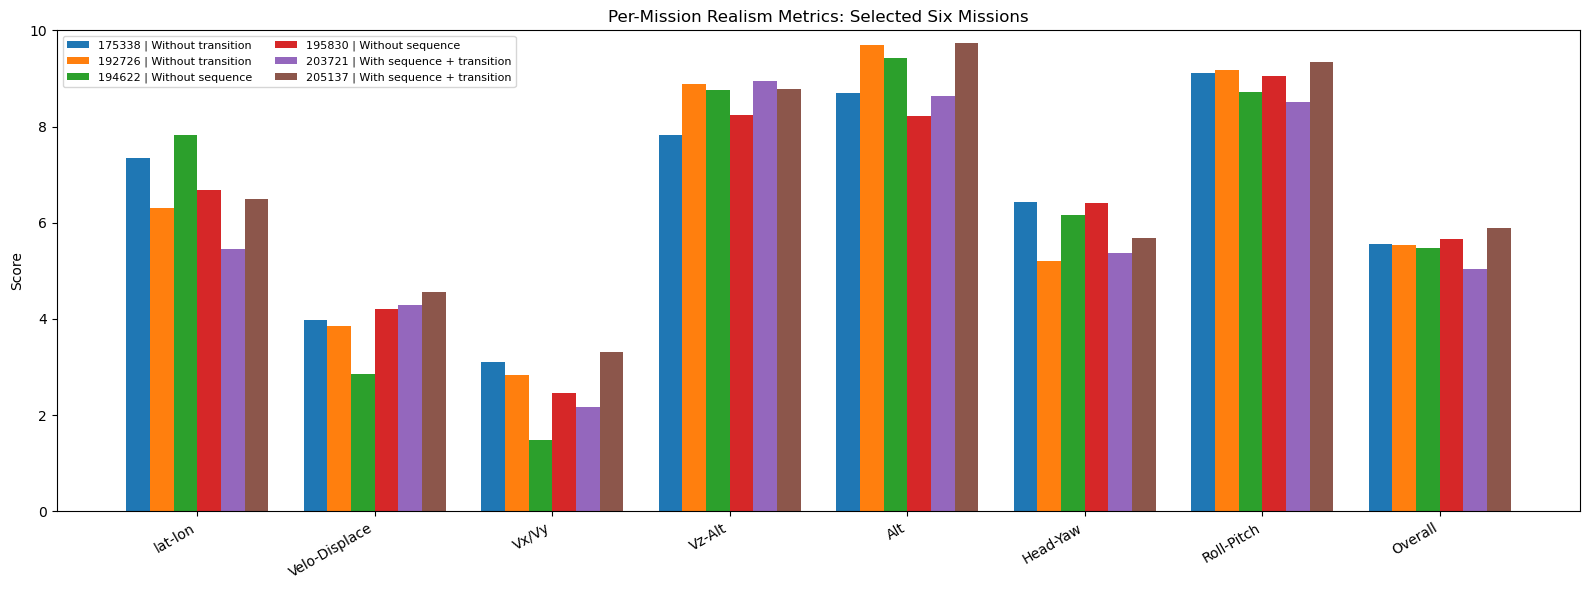

In [9]:
import pandas as pd
import numpy as np
import math
def score_one_mission(CSV_PATH, MISSION_ID):
    # =========================
    # USER SETTINGS
    # =========================


    # =========================
    # Helper functions
    # =========================

    def safe_float(x):
        try:
            if pd.isna(x):
                return np.nan
            return float(x)
        except Exception:
            return np.nan


    def to_deg_latlon(x):
        """
        MAVLink GLOBAL_POSITION_INT lat/lon usually uses int degrees * 1e7.
        Example: 473979709 -> 47.3979709
        """
        x = safe_float(x)
        if pd.isna(x):
            return np.nan
        if abs(x) > 180:
            return x / 1e7
        return x


    def alt_to_m(x):
        """
        GLOBAL_POSITION_INT alt/relative_alt usually in millimeters.
        VFR_HUD.alt already in meters.
        This function converts large values to meters.
        """
        x = safe_float(x)
        if pd.isna(x):
            return np.nan
        if abs(x) > 1000:
            return x / 1000.0
        return x


    def vel_to_ms(x):
        """
        GLOBAL_POSITION_INT vx/vy/vz usually in cm/s.
        Convert to m/s when values look like cm/s.
        """
        x = safe_float(x)
        if pd.isna(x):
            return np.nan
        if abs(x) > 50:
            return x / 100.0
        return x


    def clamp_score(x):
        if pd.isna(x):
            return np.nan
        return max(0.0, min(10.0, float(x)))


    def haversine_m(lat1, lon1, lat2, lon2):
        """
        Distance between two lat/lon points in meters.
        """
        if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
            return np.nan

        R = 6371000.0
        p1 = math.radians(lat1)
        p2 = math.radians(lat2)
        dp = math.radians(lat2 - lat1)
        dl = math.radians(lon2 - lon1)

        a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
        return 2 * R * math.asin(math.sqrt(a))


    def latlon_to_xy_m(lat_ref, lon_ref, lat, lon):
        """
        Convert lat/lon to local x/y meters using equirectangular approximation.
        x = east/west, y = north/south.
        """
        if any(pd.isna(v) for v in [lat_ref, lon_ref, lat, lon]):
            return np.nan, np.nan

        R = 6371000.0
        x = math.radians(lon - lon_ref) * R * math.cos(math.radians(lat_ref))
        y = math.radians(lat - lat_ref) * R
        return x, y


    def angle_deg_from_vector(dx, dy):
        """
        Heading-style angle in degrees.
        0 = north, 90 = east, 180/-180 = south, -90 = west.
        """
        if pd.isna(dx) or pd.isna(dy):
            return np.nan
        if abs(dx) < 1e-9 and abs(dy) < 1e-9:
            return np.nan
        return math.degrees(math.atan2(dx, dy))


    def smallest_angle_error_deg(a, b):
        if pd.isna(a) or pd.isna(b):
            return np.nan
        return abs((a - b + 180) % 360 - 180)


    def yaw_to_deg(yaw):
        """
        ATTITUDE.yaw is usually radians.
        Convert to degrees when it looks like radians.
        """
        yaw = safe_float(yaw)
        if pd.isna(yaw):
            return np.nan
        if abs(yaw) <= 2 * math.pi + 0.1:
            return math.degrees(yaw)
        return yaw


    def heading_to_deg(hdg):
        """
        generated_gpi_hdg may be centidegrees or degrees.
        generated_vfr_heading is usually degrees.
        """
        hdg = safe_float(hdg)
        if pd.isna(hdg):
            return np.nan
        if abs(hdg) > 360:
            return hdg / 100.0
        return hdg


    def score_angle(error_deg, good=5, bad=45):
        """
        10 when angle error <= good.
        0 when angle error >= bad.
        """
        if pd.isna(error_deg):
            return np.nan
        return clamp_score(10 * (1 - (error_deg - good) / (bad - good)))


    def score_ratio(actual, reported, tolerance=0.35, bad_ratio=3.0):
        """
        Scores consistency between actual and reported magnitude.
        actual and reported should be close.
        """
        if pd.isna(actual) or pd.isna(reported):
            return np.nan

        actual = abs(actual)
        reported = abs(reported)

        if actual < 1e-6 and reported < 1e-6:
            return 10.0

        denom = max(actual, reported, 1e-6)
        rel_error = abs(actual - reported) / denom

        if rel_error <= tolerance:
            return 10.0

        # Extra penalty for severe mismatch
        ratio = max(actual, reported) / max(min(actual, reported), 1e-6)
        score = 10 * (1 - (rel_error - tolerance) / (1 - tolerance))

        if ratio > bad_ratio:
            score -= min(4.0, ratio - bad_ratio)

        return clamp_score(score)


    def weighted_nanmean(items):
        """
        items = [(score, weight), ...]
        Ignores NaN and renormalizes weights.
        """
        total = 0.0
        weight_sum = 0.0

        for score, weight in items:
            if not pd.isna(score):
                total += score * weight
                weight_sum += weight

        if weight_sum == 0:
            return np.nan
        return total / weight_sum


    # =========================
    # Load and clean data
    # =========================

    df = pd.read_csv(CSV_PATH, engine="python", on_bad_lines="skip")

    df = df[df["mission_run_id"].astype(str) == MISSION_ID].copy()

    if df.empty:
        raise ValueError(f"No rows found for mission_run_id = {MISSION_ID}")

    # Sort in logical order
    sort_cols = [c for c in ["mission_seq", "llm_step_index", "timestamp"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)

    # Convert needed columns
    df["lat"] = df["generated_gpi_lat"].apply(to_deg_latlon)
    df["lon"] = df["generated_gpi_lon"].apply(to_deg_latlon)
    df["alt_m"] = df["generated_gpi_relative_alt"].apply(alt_to_m)

    df["target_lat_deg"] = df["target_lat"].apply(to_deg_latlon)
    df["target_lon_deg"] = df["target_lon"].apply(to_deg_latlon)
    df["target_alt_m"] = df["target_alt"].apply(alt_to_m)

    df["groundspeed_ms"] = df["generated_vfr_groundspeed"].apply(safe_float)
    df["vx_ms"] = df["generated_gpi_vx"].apply(vel_to_ms)
    df["vy_ms"] = df["generated_gpi_vy"].apply(vel_to_ms)
    df["vz_ms"] = df["generated_gpi_vz"].apply(vel_to_ms)
    df["climb_ms"] = df["generated_vfr_climb"].apply(safe_float)

    df["yaw_deg"] = df["generated_att_yaw"].apply(yaw_to_deg)
    df["vfr_heading_deg"] = df["generated_vfr_heading"].apply(heading_to_deg)
    df["gpi_heading_deg"] = df["generated_gpi_hdg"].apply(heading_to_deg)

    df["roll"] = df["generated_att_roll"].apply(safe_float)
    df["pitch"] = df["generated_att_pitch"].apply(safe_float)
    df["dt_s"] = df["dt"].apply(safe_float)


    # =========================
    # Per-step scoring
    # =========================

    rows = []

    for group_key, g in df.groupby(["mission_seq", "command_id", "command_name"], dropna=False):
        g = g.sort_values("llm_step_index").reset_index(drop=True)

        for i in range(1, len(g)):
            prev = g.iloc[i - 1]
            cur = g.iloc[i]

            dt = cur["dt_s"] - prev["dt_s"]

            if pd.isna(dt) or dt <= 0:
                # fallback if dt column is per-step interval
                dt = cur["dt_s"]

            if pd.isna(dt) or dt <= 0:
                continue

            # Actual displacement
            dist_m = haversine_m(prev["lat"], prev["lon"], cur["lat"], cur["lon"])
            implied_speed = dist_m / dt if not pd.isna(dist_m) else np.nan

            # Local movement vector from previous to current
            dx, dy = latlon_to_xy_m(prev["lat"], prev["lon"], cur["lat"], cur["lon"])
            actual_vx = dx / dt if not pd.isna(dx) else np.nan
            actual_vy = dy / dt if not pd.isna(dy) else np.nan
            actual_heading = angle_deg_from_vector(dx, dy)

            # Target direction from previous position to waypoint destination
            tx, ty = latlon_to_xy_m(prev["lat"], prev["lon"], cur["target_lat_deg"], cur["target_lon_deg"])
            target_heading = angle_deg_from_vector(tx, ty)

            # Altitude and vertical velocity
            alt_change = cur["alt_m"] - prev["alt_m"]
            implied_vz = alt_change / dt if not pd.isna(alt_change) else np.nan

            # In MAVLink, positive vz may mean down depending on convention.
            # For realism, compare both signs and keep the better match.
            vz_score_direct = score_ratio(implied_vz, cur["vz_ms"])
            vz_score_inverse = score_ratio(implied_vz, -cur["vz_ms"])
            vz_score = np.nanmax([vz_score_direct, vz_score_inverse])

            climb_score = score_ratio(implied_vz, cur["climb_ms"])

            # Scores
            line_error = smallest_angle_error_deg(actual_heading, target_heading)
            line_score = score_angle(line_error, good=5, bad=45)

            velocity_displacement_score = score_ratio(implied_speed, cur["groundspeed_ms"])

            vx_score = score_ratio(actual_vx, cur["vx_ms"])
            vy_score = score_ratio(actual_vy, cur["vy_ms"])
            vxvy_magnitude_score = weighted_nanmean([(vx_score, 0.5), (vy_score, 0.5)])

            generated_v_heading = angle_deg_from_vector(cur["vx_ms"], cur["vy_ms"])
            vxvy_direction_error = smallest_angle_error_deg(actual_heading, generated_v_heading)
            vxvy_direction_score = score_angle(vxvy_direction_error, good=8, bad=60)

            vx_vy_score = weighted_nanmean([
                (vxvy_direction_score, 0.60),
                (vxvy_magnitude_score, 0.40),
            ])

            vz_altitude_score = weighted_nanmean([
                (vz_score, 0.60),
                (climb_score, 0.40),
            ])

            # Altitude target score
            alt_err = abs(cur["alt_m"] - cur["target_alt_m"]) if not pd.isna(cur["target_alt_m"]) else np.nan
            if pd.isna(alt_err):
                altitude_score = np.nan
            elif alt_err <= 2:
                altitude_score = 10.0
            elif alt_err >= 20:
                altitude_score = 0.0
            else:
                altitude_score = clamp_score(10 * (1 - (alt_err - 2) / 18))

            # Heading/yaw score
            yaw_error = smallest_angle_error_deg(actual_heading, cur["yaw_deg"])
            yaw_score = score_angle(yaw_error, good=8, bad=60)

            vfr_heading_error = smallest_angle_error_deg(actual_heading, cur["vfr_heading_deg"])
            vfr_heading_score = score_angle(vfr_heading_error, good=8, bad=60)

            heading_score = weighted_nanmean([
                (yaw_score, 0.60),
                (vfr_heading_score, 0.40),
            ])

            # Roll/pitch plausibility
            # Not strict physics; checks if values are safe and not extreme.
            roll_abs = abs(cur["roll"]) if not pd.isna(cur["roll"]) else np.nan
            pitch_abs = abs(cur["pitch"]) if not pd.isna(cur["pitch"]) else np.nan

            roll_score = 10.0 if not pd.isna(roll_abs) and roll_abs <= 0.4 else 6.0
            pitch_score = 10.0 if not pd.isna(pitch_abs) and pitch_abs <= 0.4 else 6.0

            roll_pitch_score = weighted_nanmean([
                (roll_score, 0.5),
                (pitch_score, 0.5),
            ])

            overall_step_score = weighted_nanmean([
                (line_score, 0.25),
                (velocity_displacement_score, 0.25),
                (vx_vy_score, 0.20),
                (vz_altitude_score, 0.15),
                (altitude_score, 0.10),
                (heading_score, 0.05),
            ])

            rows.append({
                "mission_run_id": MISSION_ID,
                "mission_seq": cur["mission_seq"],
                "command_id": cur["command_id"],
                "command_name": cur["command_name"],
                "llm_step_index": cur["llm_step_index"],
                "dt_used_s": dt,

                "distance_m": dist_m,
                "implied_speed_ms": implied_speed,
                "reported_groundspeed_ms": cur["groundspeed_ms"],

                "line_error_deg": line_error,
                "vxvy_direction_error_deg": vxvy_direction_error,
                "yaw_error_deg": yaw_error,

                "line_following_score": line_score,
                "velocity_displacement_score": velocity_displacement_score,
                "vx_vy_score": vx_vy_score,
                "vz_altitude_score": vz_altitude_score,
                "altitude_score": altitude_score,
                "heading_yaw_score": heading_score,
                "roll_pitch_score": roll_pitch_score,
                "overall_step_score": overall_step_score,
            })


    step_scores = pd.DataFrame(rows)

    if step_scores.empty:
        raise ValueError("No step scores generated. Check dt, lat/lon, and mission rows.")


    # =========================
    # Per command/type summary
    # =========================

    type_summary = (
        step_scores
        .groupby(["mission_seq", "command_id", "command_name"], dropna=False)
        .agg(
            n_steps=("overall_step_score", "count"),
            line_following_score=("line_following_score", "mean"),
            velocity_displacement_score=("velocity_displacement_score", "mean"),
            vx_vy_score=("vx_vy_score", "mean"),
            vz_altitude_score=("vz_altitude_score", "mean"),
            altitude_score=("altitude_score", "mean"),
            heading_yaw_score=("heading_yaw_score", "mean"),
            roll_pitch_score=("roll_pitch_score", "mean"),
            overall_type_score=("overall_step_score", "mean"),
            avg_line_error_deg=("line_error_deg", "mean"),
            max_implied_speed_ms=("implied_speed_ms", "max"),
            avg_reported_groundspeed_ms=("reported_groundspeed_ms", "mean"),
        )
        .reset_index()
    )

    # Round for readable output
    score_cols = [
        "line_following_score",
        "velocity_displacement_score",
        "vx_vy_score",
        "vz_altitude_score",
        "altitude_score",
        "heading_yaw_score",
        "roll_pitch_score",
        "overall_type_score",
        "avg_line_error_deg",
        "max_implied_speed_ms",
        "avg_reported_groundspeed_ms",
    ]

    type_summary[score_cols] = type_summary[score_cols].round(3)


    # =========================
    # Mission-level summary
    # =========================

    mission_summary = pd.DataFrame([{
        "mission_run_id": MISSION_ID,
        "n_scored_steps": len(step_scores),
        "line_following_score": step_scores["line_following_score"].mean(),
        "velocity_displacement_score": step_scores["velocity_displacement_score"].mean(),
        "vx_vy_score": step_scores["vx_vy_score"].mean(),
        "vz_altitude_score": step_scores["vz_altitude_score"].mean(),
        "altitude_score": step_scores["altitude_score"].mean(),
        "heading_yaw_score": step_scores["heading_yaw_score"].mean(),
        "roll_pitch_score": step_scores["roll_pitch_score"].mean(),
        "overall_realism_score": step_scores["overall_step_score"].mean(),
        "avg_line_error_deg": step_scores["line_error_deg"].mean(),
        "max_implied_speed_ms": step_scores["implied_speed_ms"].max(),
        "avg_reported_groundspeed_ms": step_scores["reported_groundspeed_ms"].mean(),
    }])

    mission_summary = mission_summary.round(3)

    return mission_summary
# # =========================
# # Print results
# # =========================

# print("\n==============================")
# print("MISSION REALISM SUMMARY")
# print("==============================")
# print(mission_summary.to_string(index=False))

# print("\n==============================")
# print("PER TYPE / COMMAND SUMMARY")
# print("==============================")
# print(type_summary.to_string(index=False))

# print("\n==============================")
# print("WORST 10 STEPS BY OVERALL SCORE")
# print("==============================")
# worst_steps = step_scores.sort_values("overall_step_score").head(10)
# print(worst_steps[[
#     "mission_seq",
#     "command_id",
#     "command_name",
#     "llm_step_index",
#     "line_following_score",
#     "velocity_displacement_score",
#     "vx_vy_score",
#     "vz_altitude_score",
#     "altitude_score",
#     "overall_step_score",
#     "implied_speed_ms",
#     "reported_groundspeed_ms",
#     "line_error_deg",
# ]].round(3).to_string(index=False))


# =========================
# Optional: save outputs
# =========================

# step_scores.to_csv("mission_step_realism_scores.csv", index=False)
# type_summary.to_csv("mission_type_realism_summary.csv", index=False)
# mission_summary.to_csv("mission_overall_realism_summary.csv", index=False)


CSV_PATH = "../tests/logs/mission_llm_generation.csv"

all_mission_scores = pd.concat(
    [score_one_mission(CSV_PATH, mid) for mid in pd.read_csv(CSV_PATH)["mission_run_id"].dropna().unique()],
    ignore_index=True
).sort_values("overall_realism_score", ascending=False)

print(all_mission_scores.round(3).to_string(index=False))


# =========================
# Plot selected 6 missions in one figure
# =========================
import matplotlib.pyplot as plt
import numpy as np

dataset_map = {
    "mission_20260522_175338": "Without transition",
    "mission_20260522_192726": "Without transition",
    "mission_20260522_194622": "Without sequence",
    "mission_20260522_195830": "Without sequence",
    "mission_20260522_203721": "With sequence + transition",
    "mission_20260522_205137": "With sequence + transition",
}

metrics = [
    "line_following_score",
    "velocity_displacement_score",
    "vx_vy_score",
    "vz_altitude_score",
    "altitude_score",
    "heading_yaw_score",
    "roll_pitch_score",
    "overall_realism_score",
]

labels = ["lat-lon", "Velo-Displace", "Vx/Vy", "Vz-Alt", "Alt", "Head-Yaw", "Roll-Pitch", "Overall"]

plot_df = all_mission_scores[all_mission_scores["mission_run_id"].isin(dataset_map)].copy()
plot_df["dataset_type"] = plot_df["mission_run_id"].map(dataset_map)

order = [
    "mission_20260522_175338",
    "mission_20260522_192726",
    "mission_20260522_194622",
    "mission_20260522_195830",
    "mission_20260522_203721",
    "mission_20260522_205137",
]

plot_df["mission_run_id"] = pd.Categorical(plot_df["mission_run_id"], categories=order, ordered=True)
plot_df = plot_df.sort_values("mission_run_id")

x = np.arange(len(metrics))
w = 0.8 / len(plot_df)

plt.figure(figsize=(16, 6))

for i, r in plot_df.reset_index(drop=True).iterrows():
    short_id = str(r["mission_run_id"]).replace("mission_20260522_", "")
    plt.bar(
        x + i * w,
        r[metrics].astype(float).values,
        width=w,
        label=f"{short_id} | {r['dataset_type']}"
    )

plt.xticks(x + w * (len(plot_df) - 1) / 2, labels, rotation=30, ha="right")
plt.ylim(0, 10)
plt.ylabel("Score")
plt.title("Per-Mission Realism Metrics: Selected Six Missions")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


ABLATION STUDY: MEAN SCORE BY SETTING
  ablation_setting  line_following_score  velocity_displacement_score  vx_vy_score  vz_altitude_score  altitude_score  heading_yaw_score  roll_pitch_score  overall_realism_score
Without Transition                 6.829                        3.911        2.977              8.360           9.197              5.820             9.139                  5.548
  Without Sequence                 7.256                        3.530        1.978              8.497           8.822              6.292             8.884                  5.576
         With Both                 5.975                        4.434        2.736              8.863           9.178              5.528             8.932                  5.463


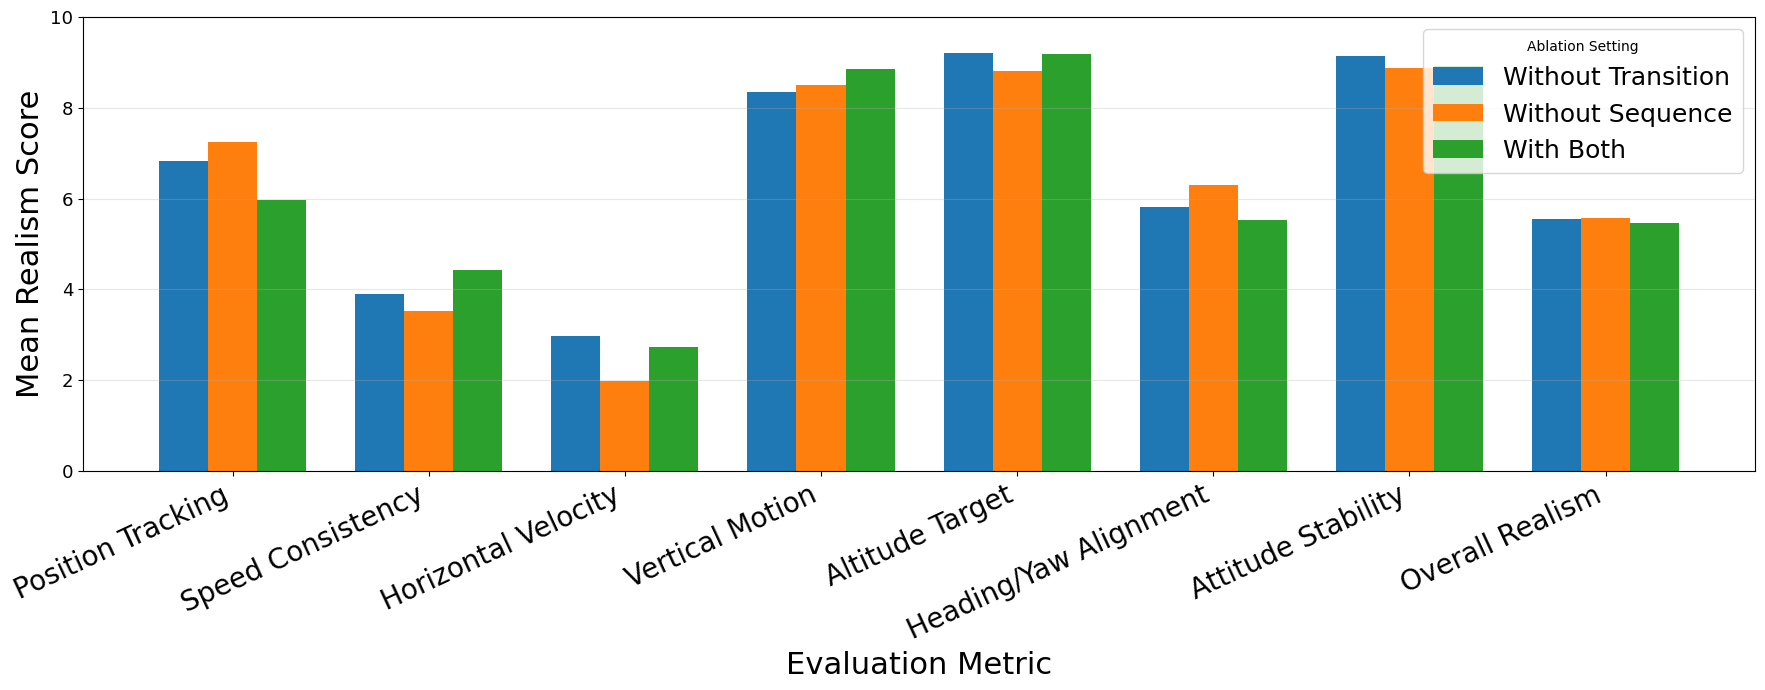

Saved figure: /home/vboxuser/Desktop/UAV_tools/Codes/mavlink_ablation_plots/ablation_mean_score_comparison.png
Saved mean table: /home/vboxuser/Desktop/UAV_tools/Codes/mavlink_ablation_plots/ablation_mean_scores.csv


In [24]:
# =========================
# Ablation study: mean score by setting
# =========================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Optional output folder
out_dir = Path("../mavlink_ablation_plots")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Define ablation groups
# =========================
ablation_map = {
    "mission_20260522_175338": "Without Transition",
    "mission_20260522_192726": "Without Transition",

    "mission_20260522_194622": "Without Sequence",
    "mission_20260522_195830": "Without Sequence",

    "mission_20260522_203721": "With Both",
    "mission_20260522_205137": "With Both",
}

ablation_order = [
    "Without Transition",
    "Without Sequence",
    "With Both",
]

# =========================
# Metrics to compare
# =========================
metrics = [
    "line_following_score",
    "velocity_displacement_score",
    "vx_vy_score",
    "vz_altitude_score",
    "altitude_score",
    "heading_yaw_score",
    "roll_pitch_score",
    "overall_realism_score",
]

metric_labels = [
    "Position Tracking",
    "Speed Consistency",
    "Horizontal Velocity",
    "Vertical Motion",
    "Altitude Target",
    "Heading/Yaw Alignment",
    "Attitude Stability",
    "Overall Realism",
]

# =========================
# Filter selected missions
# =========================
plot_df = all_mission_scores[
    all_mission_scores["mission_run_id"].isin(ablation_map)
].copy()

plot_df["ablation_setting"] = plot_df["mission_run_id"].map(ablation_map)

plot_df["ablation_setting"] = pd.Categorical(
    plot_df["ablation_setting"],
    categories=ablation_order,
    ordered=True
)

# =========================
# Mean score of each ablation type
# =========================
ablation_mean_df = (
    plot_df
    .groupby("ablation_setting", observed=False)[metrics]
    .mean()
    .reset_index()
)

ablation_std_df = (
    plot_df
    .groupby("ablation_setting", observed=False)[metrics]
    .std()
    .reset_index()
)

print("\n==============================")
print("ABLATION STUDY: MEAN SCORE BY SETTING")
print("==============================")
print(ablation_mean_df.round(3).to_string(index=False))

# Save mean table
ablation_mean_df.round(3).to_csv(
    out_dir / "ablation_mean_scores.csv",
    index=False
)

# =========================
# Plot mean ablation comparison
# =========================
x = np.arange(len(metrics))
bar_width = 0.25

plt.figure(figsize=(18, 7))

for i, setting in enumerate(ablation_order):
    row = ablation_mean_df[ablation_mean_df["ablation_setting"] == setting]

    if row.empty:
        continue

    values = row[metrics].astype(float).values.flatten()

    plt.bar(
        x + i * bar_width,
        values,
        width=bar_width,
        label=setting
    )

plt.xticks(
    x + bar_width,
    metric_labels,
    rotation=25,
    ha="right",
    fontsize=20
)

plt.yticks(fontsize=13)
plt.ylim(0, 10)

plt.ylabel("Mean Realism Score", fontsize=22)
plt.xlabel("Evaluation Metric", fontsize=22)



plt.legend(
    title="Ablation Setting",
    fontsize=18,
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    out_dir / "ablation_mean_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", (out_dir / "ablation_mean_score_comparison.png").resolve())
print("Saved mean table:", (out_dir / "ablation_mean_scores.csv").resolve())

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# -----------------------------
# Fixed file path
# -----------------------------
csv_path = Path("../tests/logs/mission_llm_generation.csv")   # change only if your filename is different

# -----------------------------
# Input mission ID
# -----------------------------
mission_id = input("Enter mission_run_id: ").strip()

# -----------------------------
# Load CSV safely
# -----------------------------
df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

# -----------------------------
# Filter mission
# -----------------------------
m = df[df["mission_run_id"].astype(str).str.strip() == mission_id].copy()

if m.empty:
    print(f"No rows found for mission_id: {mission_id}")
else:
    # Keep rows with generated position
    pts = m.dropna(subset=["generated_gpi_lat", "generated_gpi_lon"]).copy()

    # Convert MAVLink lat/lon integers to degrees
    pts["lat_deg"] = pd.to_numeric(pts["generated_gpi_lat"], errors="coerce") / 1e7
    pts["lon_deg"] = pd.to_numeric(pts["generated_gpi_lon"], errors="coerce") / 1e7

    pts["target_lat_deg"] = pd.to_numeric(pts["target_lat"], errors="coerce") / 1e7
    pts["target_lon_deg"] = pd.to_numeric(pts["target_lon"], errors="coerce") / 1e7

    # Use VFR heading if available; otherwise use GPI hdg / 100
    pts["heading_deg"] = pd.to_numeric(pts["generated_vfr_heading"], errors="coerce")
    fallback_hdg = pd.to_numeric(pts["generated_gpi_hdg"], errors="coerce") / 100.0
    pts["heading_deg"] = pts["heading_deg"].fillna(fallback_hdg)

    pts = pts.dropna(subset=["lat_deg", "lon_deg"]).copy()

    # -----------------------------
    # Plot lat/lon path
    # -----------------------------
    plt.figure(figsize=(9, 7))

    plt.plot(
        pts["lon_deg"],
        pts["lat_deg"],
        marker="o",
        linewidth=1,
        markersize=3,
        label="Generated path"
    )

    # Plot command targets
    targets = pts[[
        "target_lon_deg",
        "target_lat_deg",
        "mission_seq",
        "command_name"
    ]].drop_duplicates()

    plt.scatter(
        targets["target_lon_deg"],
        targets["target_lat_deg"],
        marker="*",
        s=140,
        label="Command targets"
    )

    for _, r in targets.iterrows():
        if pd.notna(r["target_lon_deg"]) and pd.notna(r["target_lat_deg"]):
            plt.annotate(
                f"seq {int(r['mission_seq'])}",
                (r["target_lon_deg"], r["target_lat_deg"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

    # -----------------------------
    # Add heading arrows
    # -----------------------------
    arrow_pts = pts.dropna(subset=["heading_deg"]).iloc[::5].copy()

    # MAVLink heading convention:
    # 0 deg = North, 90 deg = East
    # Plot axes:
    # x = longitude/east, y = latitude/north
    heading_rad = np.deg2rad(arrow_pts["heading_deg"].astype(float))
    u = np.sin(heading_rad)   # east / lon direction
    v = np.cos(heading_rad)   # north / lat direction

    arrow_len = 0.00018

    plt.quiver(
        arrow_pts["lon_deg"],
        arrow_pts["lat_deg"],
        u * arrow_len,
        v * arrow_len,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003,
        label="Heading arrows"
    )

    plt.xlabel("Longitude (degrees)")
    plt.ylabel("Latitude (degrees)")
    plt.title(f"Lat/Lon Path with Heading for {mission_id}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Generated points plotted: {len(pts)}")
    print(f"Heading arrows plotted: {len(arrow_pts)}")

No rows found for mission_id: 


#### run code below for generic mission scoring

In [3]:
import pandas as pd
import numpy as np
import math

# =========================
# Load file
# =========================
csv_path = "../tests/logs/mission_llm_generation.csv"
df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

print("Loaded:", csv_path)
print("Rows:", len(df))
print("Mission IDs:", df["mission_run_id"].dropna().nunique())


# =========================
# Helper functions
# =========================

def safe_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def clamp01(x):
    if pd.isna(x):
        return np.nan
    return max(0.0, min(1.0, float(x)))


def simple_mean_with_missing(scores, missing_value=0.0):
    fixed_scores = [
        missing_value if pd.isna(s) else float(s)
        for s in scores
    ]
    return float(np.mean(fixed_scores)) if len(fixed_scores) > 0 else np.nan


def haversine_m(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
    lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    lat1, lon1, lat2, lon2 = lat1 / 1e7, lon1 / 1e7, lat2 / 1e7, lon2 / 1e7

    R = 6371000.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)

    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def bearing_deg(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
    lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])

    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    lat1 = math.radians(lat1 / 1e7)
    lon1 = math.radians(lon1 / 1e7)
    lat2 = math.radians(lat2 / 1e7)
    lon2 = math.radians(lon2 / 1e7)

    dlon = lon2 - lon1

    x = math.sin(dlon) * math.cos(lat2)
    y = (
        math.cos(lat1) * math.sin(lat2)
        - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    )

    return (math.degrees(math.atan2(x, y)) + 360) % 360


def angle_diff_deg(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return abs((a - b + 180) % 360 - 180)


def yaw_to_deg(yaw_rad):
    yaw = safe_float(yaw_rad)
    if pd.isna(yaw):
        return np.nan
    return math.degrees(yaw) % 360


def score_from_error(error, tolerance):
    if pd.isna(error):
        return np.nan
    return clamp01(1 - min(abs(error) / tolerance, 1))


def get_col(row, possible_cols):
    for c in possible_cols:
        if c in row and pd.notna(row[c]):
            return row[c]
    return np.nan


def get_command(row):
    return str(get_col(row, ["command_name", "cmd_name", "mission_command_name", "command"])).upper()


def get_target_lat(row):
    return get_col(row, ["target_lat", "param5", "command_param5"])


def get_target_lon(row):
    return get_col(row, ["target_lon", "param6", "command_param6"])


def get_target_alt(row):
    return safe_float(get_col(row, ["target_alt", "param7", "command_param7"]))


def is_waypoint(command):
    return "WAYPOINT" in command or "NAV_WAYPOINT" in command or command == "16"


# =========================
# Main checker
# =========================

def check_destination_velocity_realism(g):
    g = g.copy().reset_index(drop=True)
    out = []

    for i, row in g.iterrows():
        prev = g.iloc[i - 1] if i > 0 else None

        mission_id = row.get("mission_run_id", np.nan)
        command = get_command(row)

        lat = row.get("generated_gpi_lat", np.nan)
        lon = row.get("generated_gpi_lon", np.nan)

        target_lat = get_target_lat(row)
        target_lon = get_target_lon(row)
        target_alt = get_target_alt(row)

        vfr_alt = safe_float(row.get("generated_vfr_alt", np.nan))
        groundspeed = safe_float(row.get("generated_vfr_groundspeed", np.nan))
        heading = safe_float(row.get("generated_vfr_heading", np.nan))
        climb = safe_float(row.get("generated_vfr_climb", np.nan))

        vx = safe_float(row.get("generated_gpi_vx", np.nan))
        vy = safe_float(row.get("generated_gpi_vy", np.nan))
        vz = safe_float(row.get("generated_gpi_vz", np.nan))

        roll = safe_float(row.get("generated_att_roll", np.nan))
        pitch = safe_float(row.get("generated_att_pitch", np.nan))
        yaw = safe_float(row.get("generated_att_yaw", np.nan))

        # -------------------------
        # Distance to destination
        # -------------------------
        dist_to_destination_m = haversine_m(lat, lon, target_lat, target_lon)

        if prev is not None:
            prev_dist_to_destination_m = haversine_m(
                prev.get("generated_gpi_lat", np.nan),
                prev.get("generated_gpi_lon", np.nan),
                target_lat,
                target_lon,
            )

            actual_displacement_m = haversine_m(
                prev.get("generated_gpi_lat", np.nan),
                prev.get("generated_gpi_lon", np.nan),
                lat,
                lon,
            )
        else:
            prev_dist_to_destination_m = np.nan
            actual_displacement_m = np.nan

        if is_waypoint(command):
            if pd.isna(dist_to_destination_m) or pd.isna(prev_dist_to_destination_m):
                destination_position_score = np.nan
            else:
                destination_position_score = 1.0 if dist_to_destination_m <= prev_dist_to_destination_m + 0.5 else 0.0
        else:
            destination_position_score = np.nan

        # -------------------------
        # Altitude compared to destination altitude
        # -------------------------
        if is_waypoint(command):
            if pd.isna(vfr_alt) or pd.isna(target_alt):
                destination_altitude_error_m = np.nan
                destination_altitude_score = np.nan
            else:
                destination_altitude_error_m = abs(vfr_alt - target_alt)
                destination_altitude_score = score_from_error(destination_altitude_error_m, tolerance=5.0)
        else:
            destination_altitude_error_m = np.nan
            destination_altitude_score = np.nan

        # -------------------------
        # Bearing to destination
        # -------------------------
        bearing_to_destination_deg = bearing_deg(lat, lon, target_lat, target_lon)

        if is_waypoint(command):
            if pd.isna(heading) or pd.isna(bearing_to_destination_deg):
                heading_to_destination_error_deg = np.nan
                heading_to_destination_score = np.nan
            else:
                heading_to_destination_error_deg = angle_diff_deg(heading, bearing_to_destination_deg)
                heading_to_destination_score = score_from_error(
                    heading_to_destination_error_deg,
                    tolerance=45
                )

            if pd.isna(yaw) or pd.isna(bearing_to_destination_deg):
                yaw_to_destination_error_deg = np.nan
                yaw_to_destination_score = np.nan
            else:
                yaw_deg = yaw_to_deg(yaw)
                yaw_to_destination_error_deg = angle_diff_deg(yaw_deg, bearing_to_destination_deg)
                yaw_to_destination_score = score_from_error(
                    yaw_to_destination_error_deg,
                    tolerance=45
                )
        else:
            heading_to_destination_error_deg = np.nan
            heading_to_destination_score = np.nan
            yaw_to_destination_error_deg = np.nan
            yaw_to_destination_score = np.nan

        destination_direction_score = simple_mean_with_missing([
            heading_to_destination_score,
            yaw_to_destination_score,
        ])

        # -------------------------
        # Velocity magnitude realism
        # vx/vy/vz are cm/s, VFR groundspeed/climb are m/s
        # -------------------------
        if pd.isna(vx) or pd.isna(vy) or pd.isna(groundspeed):
            vxvy_speed_mps = np.nan
            vxvy_magnitude_error_mps = np.nan
            vxvy_magnitude_score = np.nan
        else:
            vx_mps = vx / 100.0
            vy_mps = vy / 100.0
            vxvy_speed_mps = math.sqrt(vx_mps**2 + vy_mps**2)
            vxvy_magnitude_error_mps = abs(vxvy_speed_mps - groundspeed)
            vxvy_magnitude_score = score_from_error(
                vxvy_magnitude_error_mps,
                tolerance=2.0
            )

        # -------------------------
        # Velocity direction toward destination
        # MAVLink NED: vx = north, vy = east
        # heading = atan2(east, north)
        # -------------------------
        if pd.isna(vx) or pd.isna(vy) or pd.isna(bearing_to_destination_deg):
            vxvy_heading_deg = np.nan
            vxvy_destination_direction_error_deg = np.nan
            vxvy_destination_direction_score = np.nan
        else:
            vx_mps = vx / 100.0
            vy_mps = vy / 100.0
            speed_xy = math.sqrt(vx_mps**2 + vy_mps**2)

            if speed_xy < 0.2:
                vxvy_heading_deg = np.nan
                vxvy_destination_direction_error_deg = np.nan
                vxvy_destination_direction_score = np.nan
            else:
                vxvy_heading_deg = (math.degrees(math.atan2(vy_mps, vx_mps)) + 360) % 360
                vxvy_destination_direction_error_deg = angle_diff_deg(
                    vxvy_heading_deg,
                    bearing_to_destination_deg
                )
                vxvy_destination_direction_score = score_from_error(
                    vxvy_destination_direction_error_deg,
                    tolerance=45
                )

        # -------------------------
        # vz compared to VFR climb
        # -------------------------
        if pd.isna(vz) or pd.isna(climb):
            vz_mps = np.nan
            vz_climb_error_mps = np.nan
            vz_climb_score = np.nan
        else:
            vz_mps = vz / 100.0
            vz_climb_error_mps = abs(vz_mps - climb)
            vz_climb_score = score_from_error(
                vz_climb_error_mps,
                tolerance=1.0
            )

        velocity_score = simple_mean_with_missing([
            vxvy_magnitude_score,
            vxvy_destination_direction_score,
            vz_climb_score,
        ])

        # -------------------------
        # Velocity-to-displacement consistency
        # actual displacement should match vx/vy speed * dt
        # -------------------------
        dt = 0.5

        if pd.isna(actual_displacement_m) or pd.isna(vxvy_speed_mps):
            velocity_displacement_error_m = np.nan
            velocity_displacement_score = np.nan
            expected_displacement_from_velocity_m = np.nan
        else:
            expected_displacement_from_velocity_m = vxvy_speed_mps * dt
            velocity_displacement_error_m = abs(
                actual_displacement_m - expected_displacement_from_velocity_m
            )
            velocity_displacement_score = score_from_error(
                velocity_displacement_error_m,
                tolerance=2.0
            )

        # -------------------------
        # Groundspeed-to-displacement consistency
        # actual displacement should match VFR groundspeed * dt
        # -------------------------
        if pd.isna(actual_displacement_m) or pd.isna(groundspeed):
            groundspeed_displacement_error_m = np.nan
            groundspeed_displacement_score = np.nan
            expected_displacement_from_groundspeed_m = np.nan
        else:
            expected_displacement_from_groundspeed_m = groundspeed * dt
            groundspeed_displacement_error_m = abs(
                actual_displacement_m - expected_displacement_from_groundspeed_m
            )
            groundspeed_displacement_score = score_from_error(
                groundspeed_displacement_error_m,
                tolerance=2.0
            )

        # -------------------------
        # Roll / pitch / yaw realism
        # -------------------------
        if pd.isna(roll):
            roll_score = np.nan
        else:
            roll_score = 1.0 if abs(roll) <= 0.25 else 0.0

        if pd.isna(pitch):
            pitch_score = np.nan
        else:
            pitch_score = 1.0 if abs(pitch) <= 0.25 else 0.0

        attitude_score = simple_mean_with_missing([
            roll_score,
            pitch_score,
            yaw_to_destination_score,
        ])

        # -------------------------
        # Final focused score
        # -------------------------
        focused_realism_score = simple_mean_with_missing([
            destination_position_score,
            destination_altitude_score,
            destination_direction_score,
            velocity_score,
            velocity_displacement_score,
            groundspeed_displacement_score,
            attitude_score,
        ])

        out.append({
            "mission_run_id": mission_id,
            "mission_element_type": command,
            "llm_call_id": row.get("llm_call_id", np.nan),
            "llm_step_index": row.get("llm_step_index", np.nan),

            # destination position
            "dist_to_destination_m": dist_to_destination_m,
            "prev_dist_to_destination_m": prev_dist_to_destination_m,
            "destination_position_score": destination_position_score,

            # destination altitude
            "vfr_alt_m": vfr_alt,
            "target_alt_m": target_alt,
            "destination_altitude_error_m": destination_altitude_error_m,
            "destination_altitude_score": destination_altitude_score,

            # heading/yaw to destination
            "bearing_to_destination_deg": bearing_to_destination_deg,
            "reported_heading_deg": heading,
            "heading_to_destination_error_deg": heading_to_destination_error_deg,
            "heading_to_destination_score": heading_to_destination_score,
            "yaw_to_destination_error_deg": yaw_to_destination_error_deg,
            "yaw_to_destination_score": yaw_to_destination_score,
            "destination_direction_score": destination_direction_score,

            # velocity realism
            "reported_groundspeed_mps": groundspeed,
            "vxvy_speed_mps": vxvy_speed_mps,
            "vxvy_magnitude_error_mps": vxvy_magnitude_error_mps,
            "vxvy_magnitude_score": vxvy_magnitude_score,
            "vxvy_heading_deg": vxvy_heading_deg,
            "vxvy_destination_direction_error_deg": vxvy_destination_direction_error_deg,
            "vxvy_destination_direction_score": vxvy_destination_direction_score,
            "vfr_climb_mps": climb,
            "vz_mps": vz_mps,
            "vz_climb_error_mps": vz_climb_error_mps,
            "vz_climb_score": vz_climb_score,
            "velocity_score": velocity_score,

            # displacement consistency
            "actual_displacement_m": actual_displacement_m,
            "expected_displacement_from_velocity_m": expected_displacement_from_velocity_m,
            "velocity_displacement_error_m": velocity_displacement_error_m,
            "velocity_displacement_score": velocity_displacement_score,
            "expected_displacement_from_groundspeed_m": expected_displacement_from_groundspeed_m,
            "groundspeed_displacement_error_m": groundspeed_displacement_error_m,
            "groundspeed_displacement_score": groundspeed_displacement_score,

            # attitude
            "roll_score": roll_score,
            "pitch_score": pitch_score,
            "attitude_score": attitude_score,

            # final
            "focused_realism_score": focused_realism_score,
            "focused_realism_10": round(focused_realism_score * 10, 2),
        })

    return pd.DataFrame(out)


# =========================
# Run
# =========================

sort_cols = [
    c for c in ["mission_run_id", "timestamp", "llm_call_id", "llm_step_index"]
    if c in df.columns
]

df = df.sort_values(sort_cols).reset_index(drop=True)

all_checks = []

for mission_id, g in df.groupby("mission_run_id", dropna=False):
    all_checks.append(check_destination_velocity_realism(g))

checks = pd.concat(all_checks, ignore_index=True)


# =========================
# Summary
# =========================

summary_cols = [
    "focused_realism_score",
    "destination_position_score",
    "destination_altitude_score",
    "destination_direction_score",
    "heading_to_destination_score",
    "yaw_to_destination_score",
    "velocity_score",
    "vxvy_magnitude_score",
    "vxvy_destination_direction_score",
    "vz_climb_score",
    "velocity_displacement_score",
    "groundspeed_displacement_score",
    "attitude_score",
    "roll_score",
    "pitch_score",
]

mission_summary = (
    checks
    .groupby("mission_run_id")[summary_cols]
    .apply(lambda x: x.fillna(0).mean())
    .reset_index()
)

mission_summary["focused_realism_10"] = mission_summary["focused_realism_score"] * 10
mission_summary = mission_summary.sort_values("focused_realism_10", ascending=False)

print("\n=== Focused realism summary ===")
print(
    mission_summary[[
        "mission_run_id",
        "focused_realism_10",
        "destination_position_score",
        "destination_altitude_score",
        "destination_direction_score",
        "velocity_score",
        "velocity_displacement_score",
        "groundspeed_displacement_score",
        "attitude_score",
    ]]
    .round(3)
    .to_string(index=False)
)


# =========================
# Worst rows
# =========================

worst_rows = checks.sort_values("focused_realism_score", ascending=True).head(20)

print("\n=== Worst 20 focused rows ===")
print(
    worst_rows[[
        "mission_run_id",
        "mission_element_type",
        "llm_call_id",
        "llm_step_index",
        "focused_realism_10",
        "dist_to_destination_m",
        "destination_altitude_error_m",
        "heading_to_destination_error_deg",
        "yaw_to_destination_error_deg",
        "actual_displacement_m",
        "expected_displacement_from_velocity_m",
        "expected_displacement_from_groundspeed_m",
        "velocity_displacement_error_m",
        "groundspeed_displacement_error_m",
        "velocity_score",
        "attitude_score",
    ]]
    .round(3)
    .to_string(index=False)
)

Loaded: ../tests/logs/mission_llm_generation.csv
Rows: 3689
Mission IDs: 34

=== Focused realism summary ===
         mission_run_id  focused_realism_10  destination_position_score  destination_altitude_score  destination_direction_score  velocity_score  velocity_displacement_score  groundspeed_displacement_score  attitude_score
mission_20260618_183147               7.245                       0.944                       0.894                        0.636           0.800                        0.472                           0.497           0.827
mission_20260522_192726               7.079                       0.850                       0.820                        0.638           0.796                        0.556                           0.556           0.740
mission_20260605_174444               6.987                       0.889                       0.889                        0.518           0.805                        0.475                           0.476           0.839
mis

2026-05-22 17-53-14

In [6]:
# !pip install pymavlink

!pip install pyserial

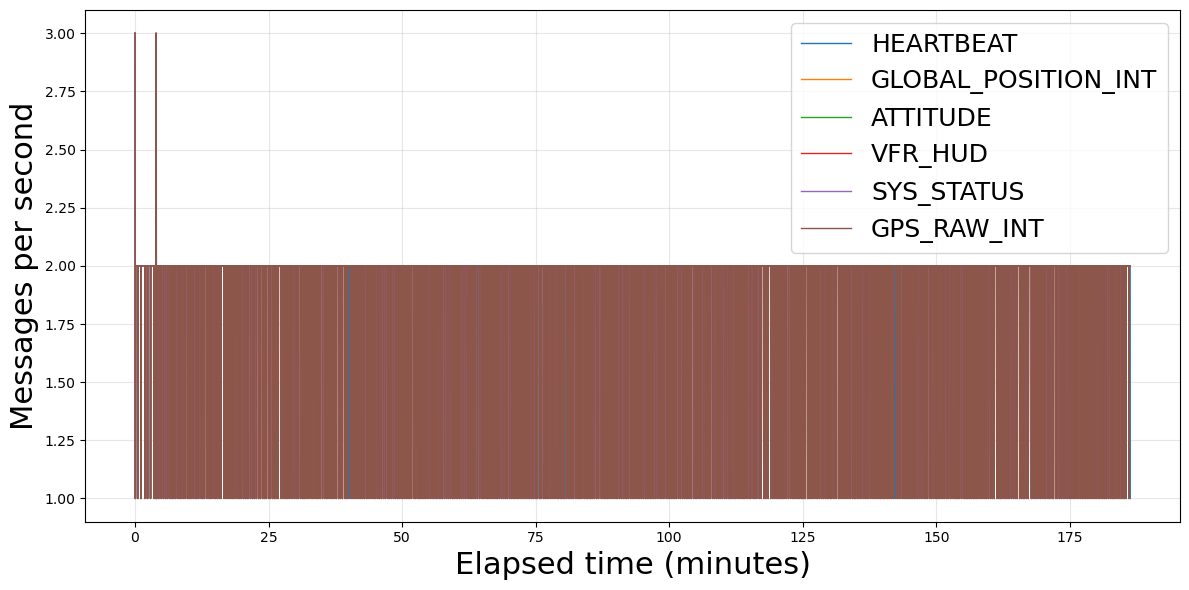

/tmp/ipykernel_3949/1077569338.py:135: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)


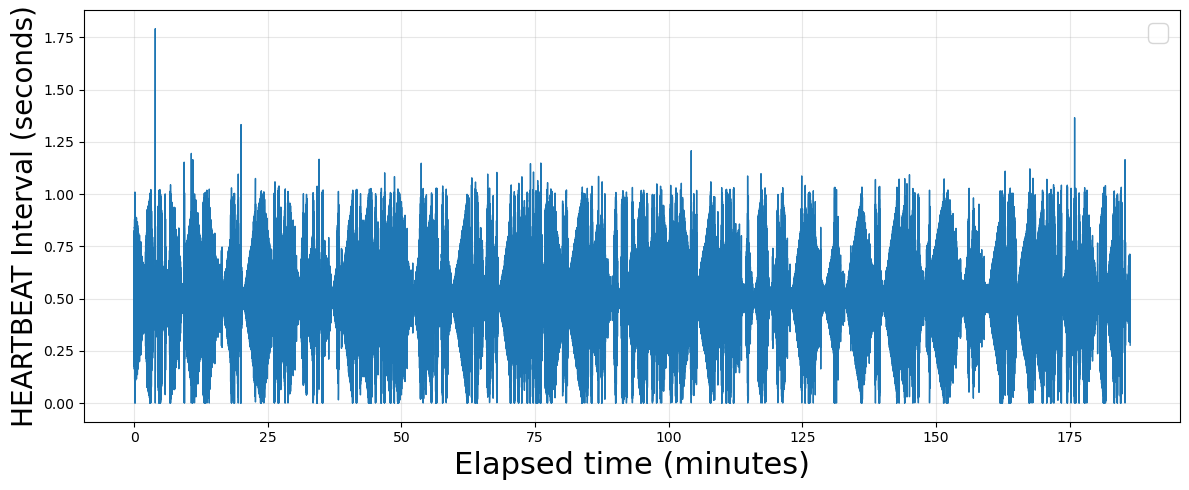

Saved plots:
mavlink_connectivity_plots/connectivity_mavlink_message_rate.png
mavlink_connectivity_plots/communication_heartbeat_interval.png

Summary:
Session duration: 186.31 minutes
Total messages parsed: 153184
HEARTBEAT count: 22211
Median HEARTBEAT interval: 0.503 sec
Max HEARTBEAT interval: 1.792 sec


In [8]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# Input / output paths
# -----------------------------
tlog_path = "/home/vboxuser/Documents/QGroundControl/Telemetry/2026-05-22 17-53-14.tlog"   # change this if needed
out_dir = "mavlink_connectivity_plots"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# Read MAVLink messages from .tlog
# -----------------------------
selected_msgs = {
    "HEARTBEAT",
    "SYS_STATUS",
    "GPS_RAW_INT",
    "GLOBAL_POSITION_INT",
    "ATTITUDE",
    "VFR_HUD",
    "MISSION_CURRENT",
}

rows = []

mlog = mavutil.mavlink_connection(tlog_path)

while True:
    msg = mlog.recv_match(blocking=False)

    if msg is None:
        break

    msg_type = msg.get_type()

    if msg_type in selected_msgs:
        rows.append({
            "timestamp": msg._timestamp,
            "message_type": msg_type
        })

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No selected MAVLink messages found in the tlog file.")

# -----------------------------
# Convert timestamps
# -----------------------------
df["elapsed_sec"] = df["timestamp"] - df["timestamp"].min()
df["elapsed_min"] = df["elapsed_sec"] / 60.0
df["second_bin"] = df["elapsed_sec"].astype(int)

# ==========================================================
# Graph 1: Connectivity - MAVLink message rate stability
# ==========================================================

rate_df = (
    df.groupby(["second_bin", "message_type"])
      .size()
      .reset_index(name="messages_per_second")
)

pivot_df = (
    rate_df.pivot(
        index="second_bin",
        columns="message_type",
        values="messages_per_second"
    )
    .fillna(0)
)

pivot_df["elapsed_min"] = pivot_df.index / 60.0

plt.figure(figsize=(12, 6))

for msg_type in [
    "HEARTBEAT",
    "GLOBAL_POSITION_INT",
    "ATTITUDE",
    "VFR_HUD",
    "SYS_STATUS",
    "GPS_RAW_INT",
]:
    if msg_type in pivot_df.columns:
        plt.plot(
            pivot_df["elapsed_min"],
            pivot_df[msg_type],
            label=msg_type,
            linewidth=1
        )

plt.xlabel("Elapsed time (minutes)", fontsize=22)
plt.ylabel("Messages per second", fontsize=22)

# plt.title("Connectivity: MAVLink Message Rate Stability")
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.tight_layout()

connectivity_plot = os.path.join(out_dir, "connectivity_mavlink_message_rate.png")
plt.savefig(connectivity_plot, dpi=300)
plt.show()

# ==========================================================
# Graph 2: Communication consistency - HEARTBEAT interval
# ==========================================================

heartbeat_df = df[df["message_type"] == "HEARTBEAT"].copy()
heartbeat_df = heartbeat_df.sort_values("timestamp")

heartbeat_df["heartbeat_interval_sec"] = heartbeat_df["timestamp"].diff()
heartbeat_df = heartbeat_df.dropna(subset=["heartbeat_interval_sec"])

plt.figure(figsize=(12, 5))

plt.plot(
    heartbeat_df["elapsed_min"],
    heartbeat_df["heartbeat_interval_sec"],
    linewidth=1
)

# plt.axhline(
#     y=1.5,
#     linestyle="--",
#     linewidth=1,
#     label="1.5 sec reference"
# )

plt.xlabel("Elapsed time (minutes)", fontsize=22)
plt.ylabel("HEARTBEAT Interval (seconds)" , fontsize=20)
# plt.title("Communication Consistency: HEARTBEAT Interval Over Time")
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.tight_layout()

heartbeat_plot = os.path.join(out_dir, "communication_heartbeat_interval.png")
plt.savefig(heartbeat_plot, dpi=300)
plt.show()

# -----------------------------
# Print summary
# -----------------------------
print("Saved plots:")
print(connectivity_plot)
print(heartbeat_plot)

print("\nSummary:")
print(f"Session duration: {df['elapsed_min'].max():.2f} minutes")
print(f"Total messages parsed: {len(df)}")
print(f"HEARTBEAT count: {len(heartbeat_df) + 1}")
print(f"Median HEARTBEAT interval: {heartbeat_df['heartbeat_interval_sec'].median():.3f} sec")
print(f"Max HEARTBEAT interval: {heartbeat_df['heartbeat_interval_sec'].max():.3f} sec")

Using: /home/vboxuser/Documents/QGroundControl/Telemetry/2026-05-23 16-47-29.tlog


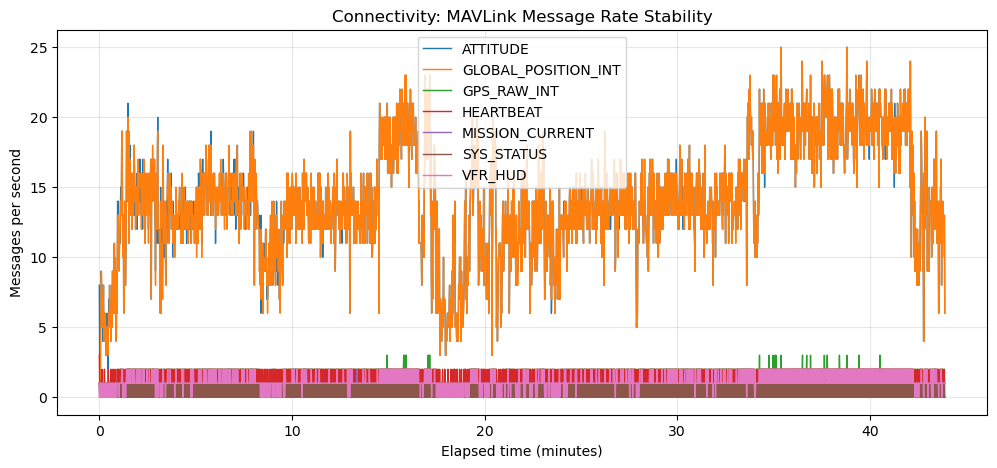

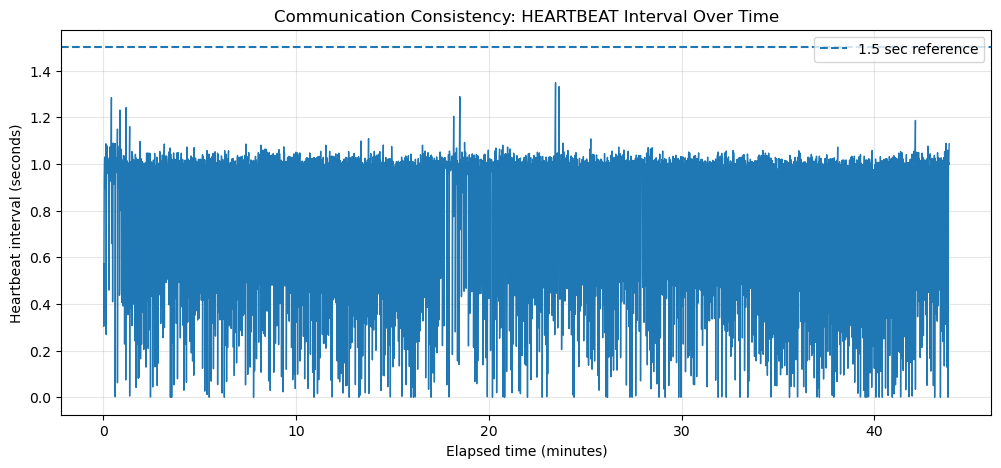

Done.
Session duration: 43.89 minutes
Heartbeat count: 3384


In [14]:
from pathlib import Path
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt

# Change only this line
file_name = "2026-05-23 16-47-29.tlog"

tlog_path = Path("/home/vboxuser/Documents/QGroundControl/Telemetry") / file_name

if not tlog_path.exists():
    raise FileNotFoundError(f"File not found: {tlog_path}")

print("Using:", tlog_path)

selected_msgs = [
    "HEARTBEAT",
    "SYS_STATUS",
    "GPS_RAW_INT",
    "GLOBAL_POSITION_INT",
    "ATTITUDE",
    "VFR_HUD",
    "MISSION_CURRENT",
]

rows = []
mlog = mavutil.mavlink_connection(str(tlog_path))

while True:
    msg = mlog.recv_match(blocking=False)
    if msg is None:
        break

    if msg.get_type() in selected_msgs:
        rows.append({
            "timestamp": msg._timestamp,
            "message_type": msg.get_type()
        })

df = pd.DataFrame(rows)

df["elapsed_sec"] = df["timestamp"] - df["timestamp"].min()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["second_bin"] = df["elapsed_sec"].astype(int)

# Message rate plot
rate_df = df.groupby(["second_bin", "message_type"]).size().reset_index(name="rate")
pivot = rate_df.pivot(index="second_bin", columns="message_type", values="rate").fillna(0)
pivot["elapsed_min"] = pivot.index / 60

plt.figure(figsize=(12, 5))
for col in pivot.columns:
    if col != "elapsed_min":
        plt.plot(pivot["elapsed_min"], pivot[col], label=col, linewidth=1)

plt.title("Connectivity: MAVLink Message Rate Stability")
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Messages per second")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Heartbeat interval plot
hb = df[df["message_type"] == "HEARTBEAT"].copy()
hb["interval_sec"] = hb["timestamp"].diff()
hb = hb.dropna()

plt.figure(figsize=(12, 5))
plt.plot(hb["elapsed_min"], hb["interval_sec"], linewidth=1)
plt.axhline(1.5, linestyle="--", label="1.5 sec reference")
plt.title("Communication Consistency: HEARTBEAT Interval Over Time")
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Heartbeat interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Done.")
print("Session duration:", round(df["elapsed_min"].max(), 2), "minutes")
print("Heartbeat count:", len(df[df["message_type"] == "HEARTBEAT"]))

Using: /home/vboxuser/Documents/QGroundControl/Telemetry/2026-05-22 17-53-14.tlog


TypeError: unsupported operand type(s) for /: 'str' and 'str'

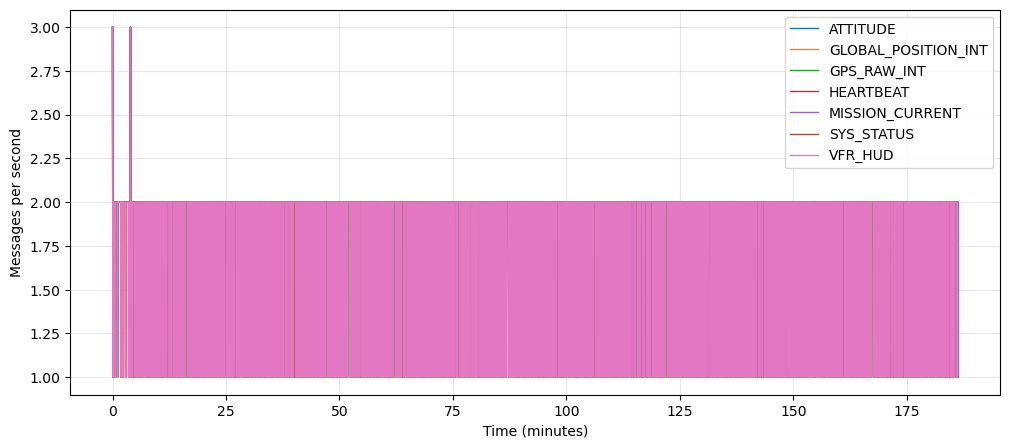

In [17]:
from pathlib import Path
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt

# Change only this line
file_name = "2026-05-22 17-53-14.tlog"

tlog_path = Path("/home/vboxuser/Documents/QGroundControl/Telemetry") / file_name

if not tlog_path.exists():
    raise FileNotFoundError(f"File not found: {tlog_path}")

print("Using:", tlog_path)

selected_msgs = [
    "HEARTBEAT",
    "SYS_STATUS",
    "GPS_RAW_INT",
    "GLOBAL_POSITION_INT",
    "ATTITUDE",
    "VFR_HUD",
    "MISSION_CURRENT",
]

rows = []
mlog = mavutil.mavlink_connection(str(tlog_path))

while True:
    msg = mlog.recv_match(blocking=False)
    if msg is None:
        break

    if msg.get_type() in selected_msgs:
        rows.append({
            "timestamp": msg._timestamp,
            "message_type": msg.get_type()
        })

df = pd.DataFrame(rows)

df["elapsed_sec"] = df["timestamp"] - df["timestamp"].min()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["second_bin"] = df["elapsed_sec"].astype(int)

# Message rate plot
rate_df = df.groupby(["second_bin", "message_type"]).size().reset_index(name="rate")
pivot = rate_df.pivot(index="second_bin", columns="message_type", values="rate").fillna(0)
pivot["elapsed_min"] = pivot.index / 60

plt.figure(figsize=(12, 5))
for col in pivot.columns:
    if col != "elapsed_min":
        plt.plot(pivot["elapsed_min"], pivot[col], label=col, linewidth=1)

# plt.title("UAV Message Rate")
plt.xlabel("Time (min)")
plt.ylabel("Messages per second")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Heartbeat interval plot
hb = df[df["message_type"] == "HEARTBEAT"].copy()
hb["interval_sec"] = hb["timestamp"].diff()
hb = hb.dropna()

plt.figure(figsize=(12, 5))
plt.plot(hb["elapsed_min"], hb["interval_sec"], linewidth=1)
plt.axhline(1.5, linestyle="--", label="1.5 sec reference")
# plt.title("Communication Consistency: HEARTBEAT Interval Over Time")
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Heartbeat interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Done.")
print("Session duration:", round(df["elapsed_min"].max(), 2), "minutes")
print("Heartbeat count:", len(df[df["message_type"] == "HEARTBEAT"]))

Using: /home/vboxuser/Documents/QGroundControl/Telemetry/2026-05-22 17-53-14.tlog


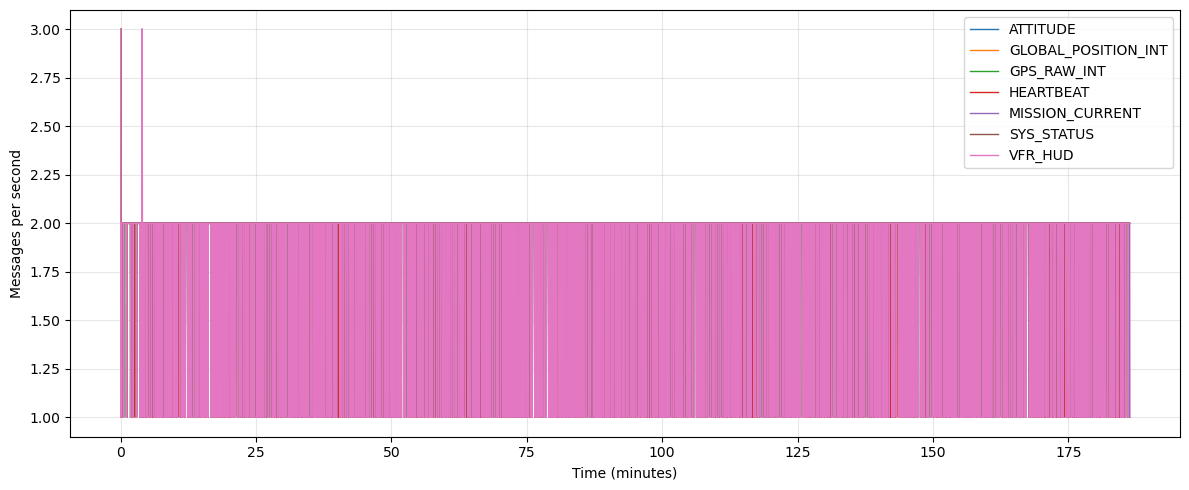

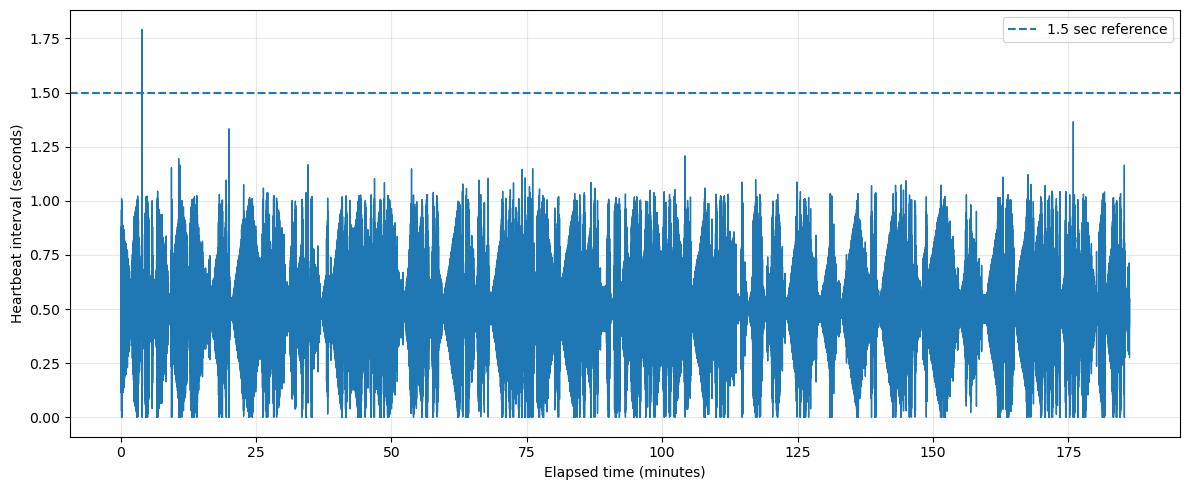

Done.
Saved plots in: /home/vboxuser/Desktop/UAV_tools/Codes/mavlink_connectivity_plots
Session duration: 186.31 minutes
Heartbeat count: 22211


In [18]:
from pathlib import Path
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt

# Change only this line
file_name = "2026-05-22 17-53-14.tlog"

tlog_path = Path("/home/vboxuser/Documents/QGroundControl/Telemetry") / file_name

if not tlog_path.exists():
    raise FileNotFoundError(f"File not found: {tlog_path}")

print("Using:", tlog_path)

selected_msgs = [
    "HEARTBEAT",
    "SYS_STATUS",
    "GPS_RAW_INT",
    "GLOBAL_POSITION_INT",
    "ATTITUDE",
    "VFR_HUD",
    "MISSION_CURRENT",
]

rows = []
mlog = mavutil.mavlink_connection(str(tlog_path))

while True:
    msg = mlog.recv_match(blocking=False)
    if msg is None:
        break

    if msg.get_type() in selected_msgs:
        rows.append({
            "timestamp": msg._timestamp,
            "message_type": msg.get_type()
        })

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No selected MAVLink messages found in the tlog file.")

df["elapsed_sec"] = df["timestamp"] - df["timestamp"].min()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["second_bin"] = df["elapsed_sec"].astype(int)

# Output folder
out_dir = Path("../mavlink_connectivity_plots")
out_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Message rate plot
# -----------------------------
rate_df = df.groupby(["second_bin", "message_type"]).size().reset_index(name="rate")
pivot = rate_df.pivot(index="second_bin", columns="message_type", values="rate").fillna(0)
pivot["elapsed_min"] = pivot.index / 60

plt.figure(figsize=(12, 5))

for col in pivot.columns:
    if col != "elapsed_min":
        plt.plot(pivot["elapsed_min"], pivot[col], label=col, linewidth=1)

plt.xlabel("Time (minutes)")
plt.ylabel("Messages per second")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(out_dir / "mavlink_message_rate.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Heartbeat interval plot
# -----------------------------
hb = df[df["message_type"] == "HEARTBEAT"].copy()
hb["interval_sec"] = hb["timestamp"].diff()
hb = hb.dropna()

plt.figure(figsize=(12, 5))

plt.plot(hb["elapsed_min"], hb["interval_sec"], linewidth=1)
plt.axhline(1.5, linestyle="--", label="1.5 sec reference")

plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Heartbeat interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(out_dir / "heartbeat_interval.png", dpi=300, bbox_inches="tight")
plt.show()

print("Done.")
print("Saved plots in:", out_dir.resolve())
print("Session duration:", round(df["elapsed_min"].max(), 2), "minutes")
print("Heartbeat count:", len(df[df["message_type"] == "HEARTBEAT"]))

Common comparison duration: 43.89 minutes


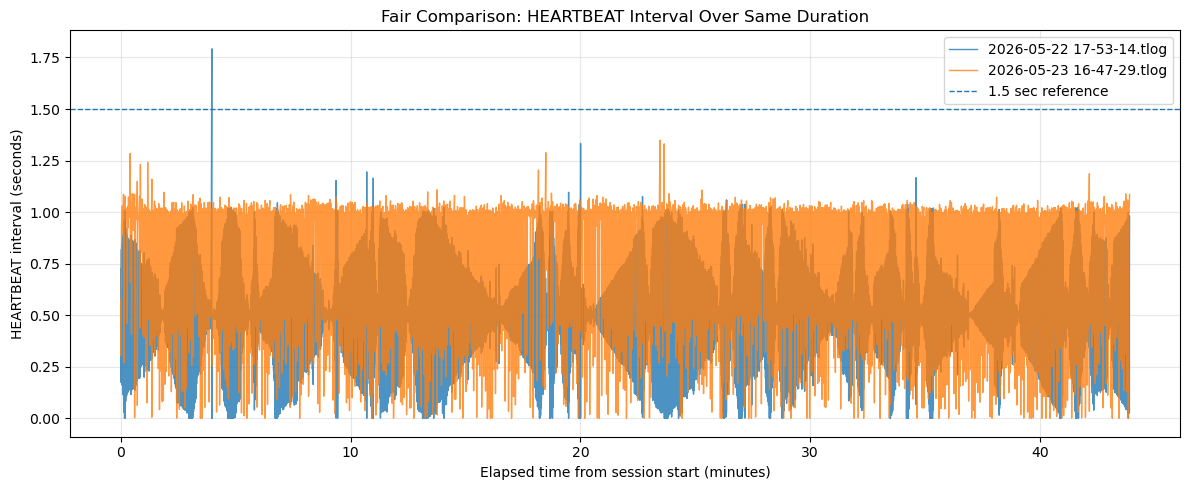

/tmp/ipykernel_3949/3043080756.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


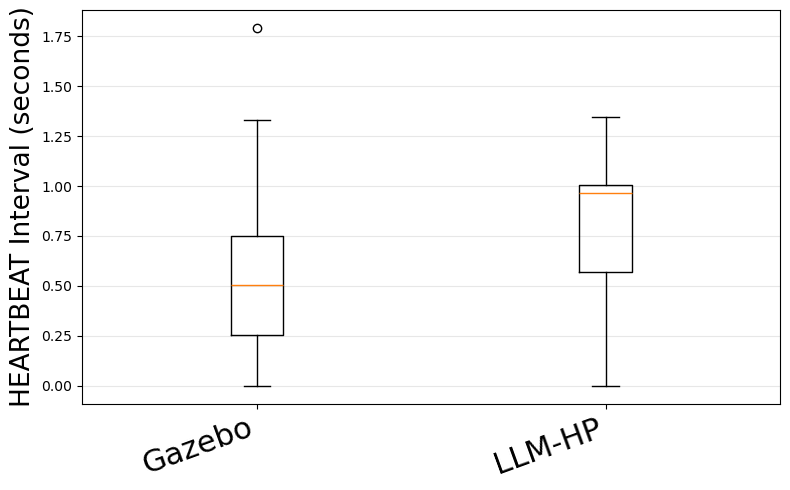

                       file  compared_duration_min  heartbeat_count  \
0  2026-05-22 17-53-14.tlog                  43.89             5238   
1  2026-05-23 16-47-29.tlog                  43.89             3384   

   median_interval_sec  mean_interval_sec  std_interval_sec  max_interval_sec  \
0                0.504              0.503             0.295             1.792   
1                0.967              0.778             0.318             1.348   

   dropouts_over_1.5_sec  dropouts_over_2.0_sec  
0                      1                      0  
1                      0                      0  


In [20]:
# side by side comparison

from pathlib import Path
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Change only these two filenames
# ==============================

save_dir = Path("mavlink_connectivity_plots")
save_dir.mkdir(parents=True, exist_ok=True)

base_dir = Path("/home/vboxuser/Documents/QGroundControl/Telemetry")

file1 = "2026-05-22 17-53-14.tlog"
file2 = "2026-05-23 16-47-29.tlog"


label1 = "Gazebo"
label2 = "LLM-HP"

# ==============================
# Extract HEARTBEAT intervals
# ==============================
def extract_heartbeat_intervals(file_name):
    tlog_path = base_dir / file_name

    if not tlog_path.exists():
        raise FileNotFoundError(f"File not found: {tlog_path}")

    rows = []
    mlog = mavutil.mavlink_connection(str(tlog_path))

    while True:
        msg = mlog.recv_match(blocking=False)
        if msg is None:
            break

        if msg.get_type() == "HEARTBEAT":
            rows.append({
                "timestamp": msg._timestamp
            })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No HEARTBEAT messages found in {file_name}")

    df["elapsed_sec"] = df["timestamp"] - df["timestamp"].min()
    df["elapsed_min"] = df["elapsed_sec"] / 60.0
    df["heartbeat_interval_sec"] = df["timestamp"].diff()
    df = df.dropna()

    return df

hb1 = extract_heartbeat_intervals(file1)
hb2 = extract_heartbeat_intervals(file2)

# ==============================
# Match both logs to same duration
# ==============================
common_duration_min = min(
    hb1["elapsed_min"].max(),
    hb2["elapsed_min"].max()
)

hb1_matched = hb1[hb1["elapsed_min"] <= common_duration_min].copy()
hb2_matched = hb2[hb2["elapsed_min"] <= common_duration_min].copy()

print("Common comparison duration:", round(common_duration_min, 2), "minutes")

# ==============================
# Plot fair heartbeat comparison
# ==============================
plt.figure(figsize=(12, 5))

plt.plot(
    hb1_matched["elapsed_min"],
    hb1_matched["heartbeat_interval_sec"],
    label=file1,
    linewidth=1,
    alpha=0.8
)

plt.plot(
    hb2_matched["elapsed_min"],
    hb2_matched["heartbeat_interval_sec"],
    label=file2,
    linewidth=1,
    alpha=0.8
)

plt.axhline(
    y=1.5,
    linestyle="--",
    linewidth=1,
    label="1.5 sec reference"
)

plt.title("Fair Comparison: HEARTBEAT Interval Over Same Duration")
plt.xlabel("Elapsed time from session start (minutes)")
plt.ylabel("HEARTBEAT interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Boxplot fair comparison
# ==============================
plt.figure(figsize=(8, 5))

# plt.boxplot(
#     [
#         hb1_matched["heartbeat_interval_sec"],
#         hb2_matched["heartbeat_interval_sec"]
#     ],
#     labels=[file1, file2],
#     showfliers=True
# )
plt.boxplot(
    [
        hb1_matched["heartbeat_interval_sec"],
        hb2_matched["heartbeat_interval_sec"]
    ],
    labels=[label1, label2],
    showfliers=True
)

# plt.axhline(
#     y=1.5,
#     linestyle="--",
#     linewidth=1,
#     label="1.5 sec reference"
# )


# plt.title("Fair Comparison: HEARTBEAT Interval Distribution")
plt.ylabel("HEARTBEAT Interval (seconds)", fontsize=19)
plt.xticks(rotation=20, ha="right" , fontsize=22)
# plt.legend(fontsize=18)
plt.savefig(save_dir / "heartbeat_interval_boxplot.png", dpi=300, bbox_inches="tight")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Summary metrics
# ==============================
def summarize(df, name):
    return {
        "file": name,
        "compared_duration_min": round(df["elapsed_min"].max(), 2),
        "heartbeat_count": len(df) + 1,
        "median_interval_sec": round(df["heartbeat_interval_sec"].median(), 3),
        "mean_interval_sec": round(df["heartbeat_interval_sec"].mean(), 3),
        "std_interval_sec": round(df["heartbeat_interval_sec"].std(), 3),
        "max_interval_sec": round(df["heartbeat_interval_sec"].max(), 3),
        "dropouts_over_1.5_sec": int((df["heartbeat_interval_sec"] > 1.5).sum()),
        "dropouts_over_2.0_sec": int((df["heartbeat_interval_sec"] > 2.0).sum())
    }

summary_df = pd.DataFrame([
    summarize(hb1_matched, file1),
    summarize(hb2_matched, file2)
])

print(summary_df)

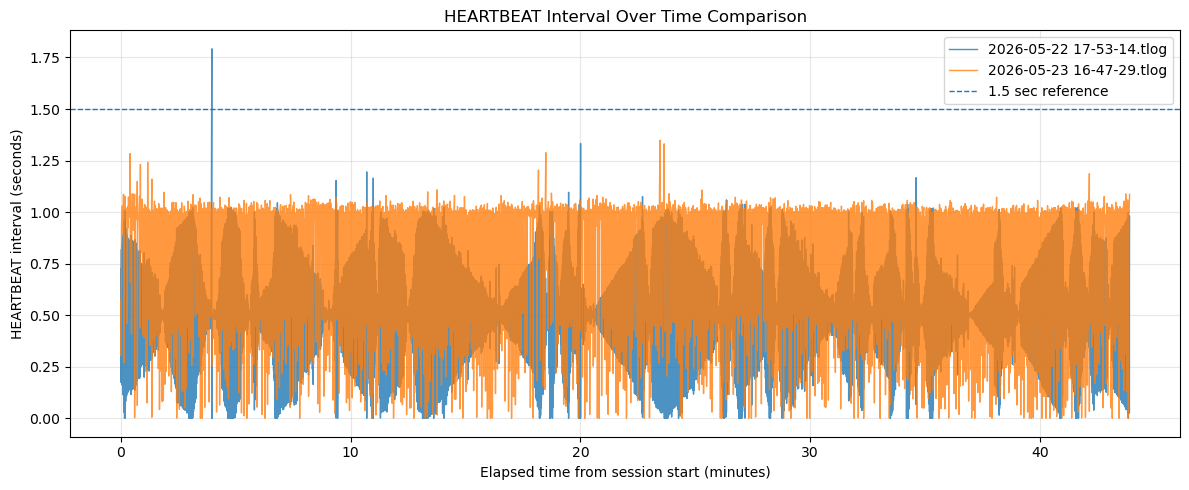

/tmp/ipykernel_4794/2923433210.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


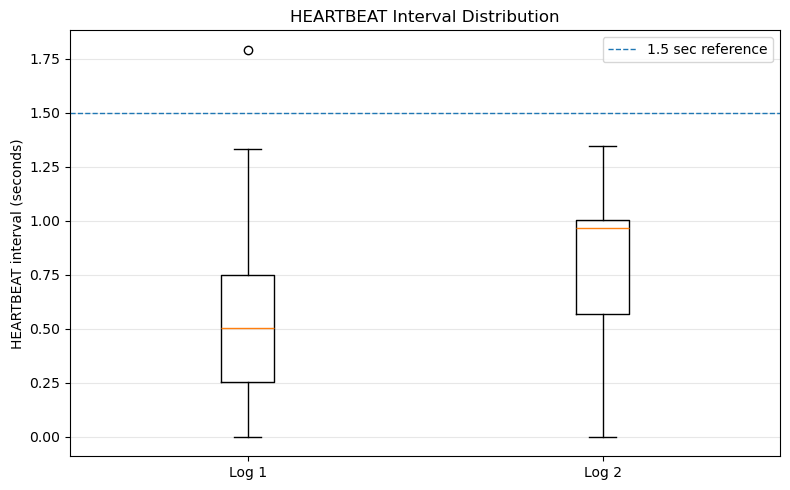

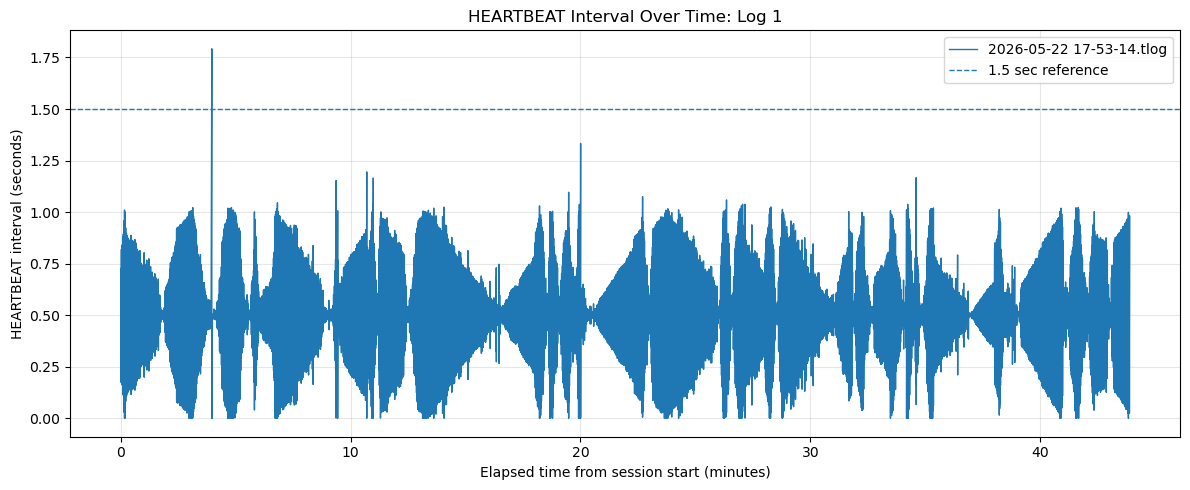

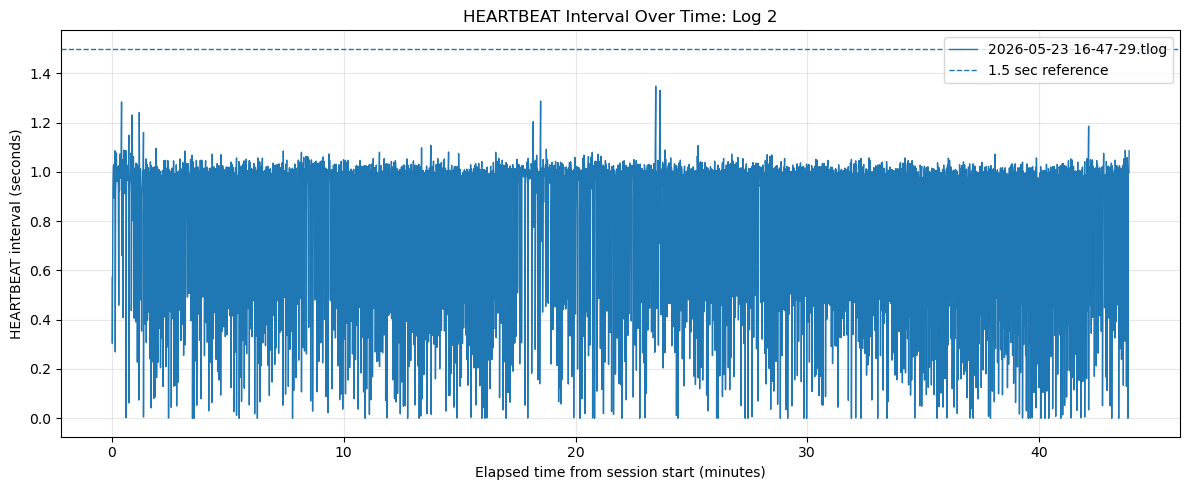

In [20]:
# ==============================
# Individual plots
# ==============================

# ------------------------------
# Plot 1: HEARTBEAT interval over time comparison
# ------------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    hb1_matched["elapsed_min"],
    hb1_matched["heartbeat_interval_sec"],
    label=file1,
    linewidth=1,
    alpha=0.8
)

plt.plot(
    hb2_matched["elapsed_min"],
    hb2_matched["heartbeat_interval_sec"],
    label=file2,
    linewidth=1,
    alpha=0.8
)

plt.axhline(
    y=1.5,
    linestyle="--",
    linewidth=1,
    label="1.5 sec reference"
)

plt.title("HEARTBEAT Interval Over Time Comparison")
plt.xlabel("Elapsed time from session start (minutes)")
plt.ylabel("HEARTBEAT interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    out_dir / "heartbeat_interval_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------
# Plot 2: HEARTBEAT interval distribution boxplot
# ------------------------------
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        hb1_matched["heartbeat_interval_sec"],
        hb2_matched["heartbeat_interval_sec"]
    ],
    labels=["Log 1", "Log 2"],
    showfliers=True
)

plt.axhline(
    y=1.5,
    linestyle="--",
    linewidth=1,
    label="1.5 sec reference"
)

plt.title("HEARTBEAT Interval Distribution")
plt.ylabel("HEARTBEAT interval (seconds)")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    out_dir / "heartbeat_interval_distribution_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------
# Plot 3: Log 1 individual HEARTBEAT interval
# ------------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    hb1_matched["elapsed_min"],
    hb1_matched["heartbeat_interval_sec"],
    label=file1,
    linewidth=1
)

plt.axhline(
    y=1.5,
    linestyle="--",
    linewidth=1,
    label="1.5 sec reference"
)

plt.title("HEARTBEAT Interval Over Time: Log 1")
plt.xlabel("Elapsed time from session start (minutes)")
plt.ylabel("HEARTBEAT interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    out_dir / "heartbeat_interval_log1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------
# Plot 4: Log 2 individual HEARTBEAT interval
# ------------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    hb2_matched["elapsed_min"],
    hb2_matched["heartbeat_interval_sec"],
    label=file2,
    linewidth=1
)

plt.axhline(
    y=1.5,
    linestyle="--",
    linewidth=1,
    label="1.5 sec reference"
)

plt.title("HEARTBEAT Interval Over Time: Log 2")
plt.xlabel("Elapsed time from session start (minutes)")
plt.ylabel("HEARTBEAT interval (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    out_dir / "heartbeat_interval_log2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
## new scoring update

In [1]:
import pandas as pd
import numpy as np
import math

# =========================================================================
# Simulation-realism scorer for LLM-generated MAVLink telemetry.
#
# Focus: PHYSICAL REALISM ONLY. No mission-following checks (no
# "is it getting closer to the waypoint", no "is altitude near target",
# no "is heading pointed at the destination bearing"). Those measure
# whether the LLM follows the mission, not whether the numbers are real.
#
# Every check here is internal consistency between telemetry streams, or
# a physical-plausibility bound. There is intentionally NO combined
# realism score -- each component is reported on its own.
#
# Goals covered:
#   1. speed & displacement  -> speed_magnitude, climb_consistency,
#                               horiz/vert displacement
#   2. heading in flight      -> heading vs actual travel direction
#   3. yaw / roll / pitch      -> yaw vs heading, roll/pitch bounds
# =========================================================================

# ---- tunables -----------------------------------------------------------
DT               = 0.5     # fixed step size (seconds)
TOL_SPEED        = 2.0     # m/s, horizontal speed agreement
TOL_CLIMB        = 2.0     # m/s, vertical speed agreement (was 1.0 -> matched to others)
TOL_DISP         = 2.0     # m, displacement vs speed*dt
TOL_ANGLE        = 45.0    # deg, heading/yaw agreement
ROLL_PITCH_LIMIT = 0.25    # rad (~14 deg) plausible level-flight bound
SPEED_GATE       = 0.2     # m/s, below this travel direction is undefined (hover/climb)

csv_path = "../tests/logs/mission_llm_generation.csv"


# =========================
# Helper functions
# =========================

def safe_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def clamp01(x):
    if pd.isna(x):
        return np.nan
    return max(0.0, min(1.0, float(x)))


def nanmean(scores):
    """Mean over present (non-NaN) components. NaN means 'not applicable
    this row' (e.g. first row, or travel direction while hovering) and is
    excluded -- never silently treated as a zero."""
    vals = [float(s) for s in scores if not pd.isna(s)]
    return float(np.mean(vals)) if vals else np.nan


def haversine_m(lat1_e7, lon1_e7, lat2_e7, lon2_e7):
    lat1, lon1, lat2, lon2 = map(safe_float, [lat1_e7, lon1_e7, lat2_e7, lon2_e7])
    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan
    lat1, lon1, lat2, lon2 = lat1 / 1e7, lon1 / 1e7, lat2 / 1e7, lon2 / 1e7
    R = 6371000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def angle_diff_deg(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return abs((a - b + 180) % 360 - 180)


def yaw_to_deg(yaw_rad):
    yaw = safe_float(yaw_rad)
    if pd.isna(yaw):
        return np.nan
    return math.degrees(yaw) % 360


def score_from_error(error, tolerance):
    """s(e, tau) = max(0, min(1, 1 - |e|/tau))."""
    if pd.isna(error):
        return np.nan
    return clamp01(1 - min(abs(error) / tolerance, 1))


def get_col(row, possible_cols):
    for c in possible_cols:
        if c in row and pd.notna(row[c]):
            return row[c]
    return np.nan


def get_command(row):
    return str(get_col(row, ["command_name", "cmd_name", "command"])).upper()


# =========================
# Main checker (per mission, chained in time order)
# =========================

def check_realism(g):
    g = g.copy().reset_index(drop=True)
    out = []

    for i, row in g.iterrows():
        prev = g.iloc[i - 1] if i > 0 else None

        command = get_command(row)

        lat = row.get("generated_gpi_lat", np.nan)
        lon = row.get("generated_gpi_lon", np.nan)
        gpi_alt = safe_float(get_col(row, ["generated_gpi_alt", "generated_gpi_relative_alt"]))  # mm

        groundspeed = safe_float(row.get("generated_vfr_groundspeed", np.nan))  # m/s
        heading = safe_float(row.get("generated_vfr_heading", np.nan))          # deg
        climb = safe_float(row.get("generated_vfr_climb", np.nan))              # m/s, +up

        vx = safe_float(row.get("generated_gpi_vx", np.nan))  # cm/s, NED north
        vy = safe_float(row.get("generated_gpi_vy", np.nan))  # cm/s, NED east
        vz = safe_float(row.get("generated_gpi_vz", np.nan))  # cm/s, NED down (+down)

        roll = safe_float(row.get("generated_att_roll", np.nan))    # rad
        pitch = safe_float(row.get("generated_att_pitch", np.nan))  # rad
        yaw = safe_float(row.get("generated_att_yaw", np.nan))      # rad

        # =================================================================
        # GOAL 1a: horizontal speed agreement  (vxy  vs  VFR groundspeed)
        # =================================================================
        if pd.isna(vx) or pd.isna(vy) or pd.isna(groundspeed):
            vxy_speed = np.nan
            speed_magnitude_score = np.nan
        else:
            vxy_speed = math.hypot(vx / 100.0, vy / 100.0)
            speed_magnitude_score = score_from_error(abs(vxy_speed - groundspeed), TOL_SPEED)

        # =================================================================
        # GOAL 1b: vertical speed agreement  (vz  vs  VFR climb)
        # NED vz is +down, VFR climb is +up  ->  they should be negatives.
        # =================================================================
        if pd.isna(vz) or pd.isna(climb):
            climb_consistency_score = np.nan
        else:
            climb_consistency_score = score_from_error(abs(vz / 100.0 + climb), TOL_CLIMB)

        # =================================================================
        # GOAL 2: heading vs ACTUAL TRAVEL DIRECTION (not destination)
        # travel direction undefined below SPEED_GATE (hover / pure climb)
        # NED: bearing = atan2(east, north) = atan2(vy, vx)
        # =================================================================
        if pd.isna(vx) or pd.isna(vy):
            travel_dir_deg = np.nan
        else:
            spd = math.hypot(vx / 100.0, vy / 100.0)
            travel_dir_deg = (math.degrees(math.atan2(vy / 100.0, vx / 100.0)) + 360) % 360 if spd >= SPEED_GATE else np.nan

        heading_score = score_from_error(angle_diff_deg(heading, travel_dir_deg), TOL_ANGLE)

        # =================================================================
        # GOAL 3a: yaw legitimacy -> body yaw should agree with heading
        # (both describe where the nose points; mission-agnostic)
        # =================================================================
        yaw_score = score_from_error(angle_diff_deg(yaw_to_deg(yaw), heading), TOL_ANGLE)

        # =================================================================
        # GOAL 3b: roll / pitch plausibility bounds (binary)
        # =================================================================
        roll_score = np.nan if pd.isna(roll) else (1.0 if abs(roll) <= ROLL_PITCH_LIMIT else 0.0)
        pitch_score = np.nan if pd.isna(pitch) else (1.0 if abs(pitch) <= ROLL_PITCH_LIMIT else 0.0)

        # =================================================================
        # displacement consistency (needs previous row)
        # =================================================================
        if prev is not None:
            actual_disp_m = haversine_m(
                prev.get("generated_gpi_lat", np.nan), prev.get("generated_gpi_lon", np.nan), lat, lon
            )
            prev_alt = safe_float(get_col(prev, ["generated_gpi_alt", "generated_gpi_relative_alt"]))
        else:
            actual_disp_m = np.nan
            prev_alt = np.nan

        # GOAL 1c: horizontal displacement vs vxy*dt and vs groundspeed*dt
        if pd.isna(actual_disp_m) or pd.isna(vxy_speed):
            disp_vs_velocity_score = np.nan
        else:
            disp_vs_velocity_score = score_from_error(abs(actual_disp_m - vxy_speed * DT), TOL_DISP)

        if pd.isna(actual_disp_m) or pd.isna(groundspeed):
            disp_vs_groundspeed_score = np.nan
        else:
            disp_vs_groundspeed_score = score_from_error(abs(actual_disp_m - groundspeed * DT), TOL_DISP)

        # GOAL 1d: VERTICAL displacement vs climb rate  (the missing axis)
        # alt is mm -> m; expected climb from NED vz is (-vz/100)*dt  (+up)
        if pd.isna(prev_alt) or pd.isna(gpi_alt) or pd.isna(vz):
            vert_disp_score = np.nan
            actual_climb_m = np.nan
        else:
            actual_climb_m = (gpi_alt - prev_alt) / 1000.0
            expected_climb_m = (-vz / 100.0) * DT
            vert_disp_score = score_from_error(abs(actual_climb_m - expected_climb_m), TOL_DISP)

        out.append({
            "mission_run_id": row.get("mission_run_id", np.nan),
            "command": command,
            "llm_call_id": row.get("llm_call_id", np.nan),
            "llm_step_index": row.get("llm_step_index", np.nan),

            # --- goal 1: speed & displacement ---
            "speed_magnitude_score": speed_magnitude_score,
            "climb_consistency_score": climb_consistency_score,
            "disp_vs_velocity_score": disp_vs_velocity_score,
            "disp_vs_groundspeed_score": disp_vs_groundspeed_score,
            "vert_disp_score": vert_disp_score,

            # --- goal 2: heading ---
            "heading_score": heading_score,

            # --- goal 3: yaw / roll / pitch ---
            "yaw_score": yaw_score,
            "roll_score": roll_score,
            "pitch_score": pitch_score,

            # --- diagnostics (raw, for inspecting failures) ---
            "vxy_speed_mps": vxy_speed,
            "reported_groundspeed_mps": groundspeed,
            "actual_disp_m": actual_disp_m,
            "actual_climb_m": actual_climb_m,
            "vz_mps": (vz / 100.0) if not pd.isna(vz) else np.nan,
            "vfr_climb_mps": climb,
            "travel_dir_deg": travel_dir_deg,
            "reported_heading_deg": heading,
            "yaw_deg": yaw_to_deg(yaw),
            "roll_rad": roll,
            "pitch_rad": pitch,
        })

    return pd.DataFrame(out)


# =========================
# Run
# =========================

def main():
    df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")
    print("Loaded:", csv_path)
    print("Rows:", len(df))
    print("Mission IDs:", df["mission_run_id"].dropna().nunique())

    # time order; steps within a call are sub-second apart, calls are seconds apart,
    # so timestamp ordering chains the trajectory correctly across call boundaries.
    sort_cols = [c for c in ["mission_run_id", "timestamp", "llm_call_id", "llm_step_index"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)

    checks = pd.concat(
        [check_realism(g) for _, g in df.groupby("mission_run_id", dropna=False)],
        ignore_index=True,
    )

    component_cols = [
        "speed_magnitude_score",
        "climb_consistency_score",
        "disp_vs_velocity_score",
        "disp_vs_groundspeed_score",
        "vert_disp_score",
        "heading_score",
        "yaw_score",
        "roll_score",
        "pitch_score",
    ]

    # ---- per-mission mean of each component (nanmean: skip not-applicable) ----
    mission_summary = (
        checks.groupby("mission_run_id")[component_cols]
        .apply(lambda x: x.apply(lambda col: col.dropna().mean()))
        .reset_index()
    )

    print("\n=== Per-component realism by mission (no combined score) ===")
    print(mission_summary.round(3).to_string(index=False))

    # ---- overall per-component means across all rows ----
    print("\n=== Overall per-component means ===")
    for c in component_cols:
        col = checks[c].dropna()
        n = len(col)
        print(f"  {c:28s} {col.mean():.3f}   (n={n})")

    # ---- worst rows by number of failed components ----
    checks["_fail_count"] = checks[component_cols].apply(
        lambda r: int((r.dropna() < 0.5).sum()), axis=1
    )
    worst = checks.sort_values("_fail_count", ascending=False).head(20)
    print("\n=== Worst 20 rows (most failed components) ===")
    show = ["mission_run_id", "command", "llm_step_index", "_fail_count"] + component_cols
    print(worst[show].round(2).to_string(index=False))

    checks.drop(columns="_fail_count").to_csv("realism_components.csv", index=False)
    print("\nWrote per-row components -> realism_components.csv")


if __name__ == "__main__":
    main()

Loaded: ../tests/logs/mission_llm_generation.csv
Rows: 6604
Mission IDs: 46

=== Per-component realism by mission (no combined score) ===
         mission_run_id  speed_magnitude_score  climb_consistency_score  disp_vs_velocity_score  disp_vs_groundspeed_score  vert_disp_score  heading_score  yaw_score  roll_score  pitch_score
mission_20260521_202827                  0.987                    0.998                   0.779                      0.780            0.958          0.866      0.998         1.0         1.00
mission_20260522_130928                  0.997                    0.994                   0.781                      0.781            0.979          0.999      1.000         1.0         1.00
mission_20260522_134409                  0.975                    0.977                   0.869                      0.859            0.931          0.994      1.000         1.0         1.00
mission_20260522_175338                  0.982                    0.987                   0.580   

In [ ]:
# item plots::


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Config
# ============================================================

INPUT_CSV = Path("../tests/logs/mission_llm_generation_v2.csv")
OUT_DIR = Path("mission_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# If many missions exist, set this to limit the overlay.
# Example: MAX_MISSIONS = 5
MAX_MISSIONS = None



TARGET_COMMANDS = {
    "MAV_CMD_NAV_TAKEOFF",
    "MAV_CMD_NAV_WAYPOINT",
    "MAV_CMD_NAV_RETURN_TO_LAUNCH",
    "MAV_CMD_NAV_LAND",
}

# ============================================================
# Select missions manually
# ============================================================

SELECTED_MISSIONS = {
    "M1": "mission_20260625_170759",
    # "M1": "mission_20260609_144632",
    "M2": "mission_20260626_105656",
    "M3": "mission_20260626_164603"
}

# ============================================================
# Mission CSV header
# ============================================================

COLUMNS = [
    "mission_run_id",
    "mission_name",
    "timestamp",
    "mission_seq",
    "mission_status",
    "command_id",
    "command_name",
    "frame",
    "current",
    "autocontinue",
    "param1",
    "param2",
    "param3",
    "param4",
    "param5",
    "param6",
    "param7",
    "target_lat",
    "target_lon",
    "target_alt",
    "llm_call_id",
    "llm_step_index",
    "dt",
    "llm_latency_ms",
    "llm_model_name",
    "input_gpi_lat",
    "input_gpi_lon",
    "input_gpi_alt",
    "input_gpi_relative_alt",
    "input_gpi_vx",
    "input_gpi_vy",
    "input_gpi_vz",
    "input_gpi_hdg",
    "input_roll",
    "input_pitch",
    "input_yaw",
    "input_vfr_groundspeed",
    "input_vfr_heading",
    "input_vfr_throttle",
    "input_vfr_alt",
    "input_vfr_climb",
    "input_battery_remaining",
    "input_voltage_battery",
    "input_load",
    "input_gps_fix_type",
    "generated_gpi_lat",
    "generated_gpi_lon",
    "generated_gpi_alt",
    "generated_gpi_relative_alt",
    "generated_gpi_vx",
    "generated_gpi_vy",
    "generated_gpi_vz",
    "generated_gpi_hdg",
    "generated_att_roll",
    "generated_att_pitch",
    "generated_att_yaw",
    "generated_vfr_groundspeed",
    "generated_vfr_heading",
    "generated_vfr_throttle",
    "generated_vfr_alt",
    "generated_vfr_climb",
    "generated_sys_battery_remaining",
    "generated_sys_voltage_battery",
    "generated_sys_load",
    "generated_gps_fix_type",
]


# ============================================================
# Load and clean data
# ============================================================

def load_mission_csv(path: Path) -> pd.DataFrame:
    """
    Loads mission_items.csv.
    Handles both:
      1. CSV with header
      2. CSV without header
    """

    try:
        df_try = pd.read_csv(path, na_values=["", "nan", "NaN", "None"])
        if "mission_run_id" in df_try.columns and "generated_vfr_alt" in df_try.columns:
            df = df_try
        else:
            df = pd.read_csv(
                path,
                names=COLUMNS,
                header=None,
                na_values=["", "nan", "NaN", "None"],
            )
    except Exception:
        df = pd.read_csv(
            path,
            names=COLUMNS,
            header=None,
            na_values=["", "nan", "NaN", "None"],
        )

    # Convert numeric columns safely
    text_cols = {
        "mission_run_id",
        "mission_name",
        "mission_status",
        "command_name",
        "llm_call_id",
        "llm_model_name",
    }

    for col in df.columns:
        if col not in text_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def add_derived_fields(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Stable row index
    df["sample_index"] = np.arange(len(df))

    # Convert MAVLink integer lat/lon to degrees
    latlon_cols = [
        "target_lat",
        "target_lon",
        "input_gpi_lat",
        "input_gpi_lon",
        "generated_gpi_lat",
        "generated_gpi_lon",
    ]

    for col in latlon_cols:
        if col in df.columns:
            df[col + "_deg"] = df[col] / 1e7

    # Per-mission elapsed time
    df["elapsed_s"] = np.nan

    for mission_id, group in df.groupby("mission_label", sort=False):
        idx = group.index

        if group["timestamp"].notna().any():
            base_time = group["timestamp"].min()
            df.loc[idx, "elapsed_s"] = group["timestamp"] - base_time + group["dt"].fillna(0)
        else:
            df.loc[idx, "elapsed_s"] = np.arange(len(group))

    return df


def select_missions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Selects only the missions listed in SELECTED_MISSIONS.

    SELECTED_MISSIONS format:
        {
            "mid1": "mission_...",
            "mid2": "mission_...",
        }

    The short labels mid1, mid2, etc. are added as mission_label.
    """

    if SELECTED_MISSIONS is None:
        df["mission_label"] = df["mission_run_id"]
        return df

    mission_id_to_label = {
        mission_id: label
        for label, mission_id in SELECTED_MISSIONS.items()
    }

    selected_ids = list(mission_id_to_label.keys())

    df = df[df["mission_run_id"].isin(selected_ids)].copy()
    df["mission_label"] = df["mission_run_id"].map(mission_id_to_label)

    return df


def short_label(label: str, max_len: int = 18) -> str:
    label = str(label)
    if len(label) <= max_len:
        return label
    return label[:max_len] + "..."


def save_plot(filename: str):
    path = OUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=240, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")


# ============================================================
# Coordinate conversion for trajectory plots
# ============================================================

def add_local_meter_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Converts generated lat/lon into local East/North meters.

    Uses the first valid generated position in the whole file as origin,
    so multiple missions can be overlaid in the same coordinate frame.
    """

    df = df.copy()

    valid = df.dropna(subset=["generated_gpi_lat_deg", "generated_gpi_lon_deg"])

    if valid.empty:
        raise ValueError("No valid generated latitude/longitude found.")

    lat0 = valid["generated_gpi_lat_deg"].iloc[0]
    lon0 = valid["generated_gpi_lon_deg"].iloc[0]

    meters_per_deg_lat = 111_320.0
    meters_per_deg_lon = 111_320.0 * np.cos(np.radians(lat0))

    df["generated_east_m"] = (df["generated_gpi_lon_deg"] - lon0) * meters_per_deg_lon
    df["generated_north_m"] = (df["generated_gpi_lat_deg"] - lat0) * meters_per_deg_lat

    df["target_east_m"] = (df["target_lon_deg"] - lon0) * meters_per_deg_lon
    df["target_north_m"] = (df["target_lat_deg"] - lat0) * meters_per_deg_lat

    return df


# ============================================================
# Plot 1: 3D trajectory overlay
# ============================================================

def plot_3d_trajectory(df: pd.DataFrame):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    for mission_id, group in df.groupby("mission_label", sort=False):
        group = group.dropna(
            subset=["generated_east_m", "generated_north_m", "generated_vfr_alt"]
        )

        if group.empty:
            continue

        label = short_label(mission_id)

        ax.plot(
            group["generated_east_m"],
            group["generated_north_m"],
            group["generated_vfr_alt"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=label,
        )

        # Start point
        ax.scatter(
            group["generated_east_m"].iloc[0],
            group["generated_north_m"].iloc[0],
            group["generated_vfr_alt"].iloc[0],
            marker="o",
            s=45,
        )

        # End point
        ax.scatter(
            group["generated_east_m"].iloc[-1],
            group["generated_north_m"].iloc[-1],
            group["generated_vfr_alt"].iloc[-1],
            marker="^",
            s=55,
        )

        targets = df.dropna(subset=["target_east_m", "target_north_m", "target_alt"]).copy()

        targets = targets[
            targets["command_name"].isin(TARGET_COMMANDS)
            & ~((targets["target_lat"] == 0) & (targets["target_lon"] == 0))
        ]

        targets = targets.drop_duplicates(
            ["mission_run_id", "mission_seq", "target_east_m", "target_north_m", "target_alt"]
        )

    if not targets.empty:
        ax.scatter(
            targets["target_east_m"],
            targets["target_north_m"],
            targets["target_alt"],
            marker="x",
            s=80,
            label="Targets",
        )

    ax.set_title("3D generated UAV trajectory overlay")
    ax.set_xlabel("East displacement (m)")
    ax.set_ylabel("North displacement (m)")
    ax.set_zlabel("Altitude (m)")
    ax.view_init(elev=25, azim=-55)
    ax.legend(fontsize=8)

    save_plot("01_3d_trajectory_overlay.png")


# ============================================================
# Plot 2: Altitude profile overlay
# ============================================================

def plot_altitude_profile(df: pd.DataFrame):
    plt.figure(figsize=(9, 5))

    for mission_id, group in df.groupby("mission_label", sort=False):
        group = group.dropna(subset=["elapsed_s", "generated_vfr_alt"])

        if group.empty:
            continue

        plt.plot(
            group["elapsed_s"],
            group["generated_vfr_alt"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=short_label(mission_id),
        )

    plt.xlabel("Elapsed time within mission (s)")
    plt.ylabel("Generated altitude (m)")
    plt.title("Generated altitude profile overlay")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)

    save_plot("02_altitude_profile_overlay.png")


# ============================================================
# Plot 3: Groundspeed profile overlay
# ============================================================

def plot_groundspeed_profile(df: pd.DataFrame):
    plt.figure(figsize=(9, 5))

    for mission_id, group in df.groupby("mission_label", sort=False):
        group = group.dropna(subset=["elapsed_s", "generated_vfr_groundspeed"])

        if group.empty:
            continue

        plt.plot(
            group["elapsed_s"],
            group["generated_vfr_groundspeed"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=short_label(mission_id),
        )

    plt.xlabel("Elapsed time within mission (s)")
    plt.ylabel("Generated groundspeed (m/s)")
    plt.title("Generated groundspeed profile overlay")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)

    save_plot("03_groundspeed_profile_overlay.png")


# ============================================================
# Plot 4: Climb-rate profile overlay
# ============================================================

def plot_climbrate_profile(df: pd.DataFrame):
    plt.figure(figsize=(9, 5))

    for mission_id, group in df.groupby("mission_label", sort=False):
        group = group.dropna(subset=["elapsed_s", "generated_vfr_climb"])

        if group.empty:
            continue

        plt.plot(
            group["elapsed_s"],
            group["generated_vfr_climb"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=short_label(mission_id),
        )

    plt.axhline(0, linestyle="--", linewidth=1.0)
    plt.xlabel("Elapsed time within mission (s)")
    plt.ylabel("Generated climb rate (m/s)")
    plt.title("Generated climb/descent rate overlay")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)

    save_plot("04_climbrate_profile_overlay.png")


# ============================================================
# Plot 5: 2D trajectory overlay
# ============================================================

def plot_2d_trajectory(df: pd.DataFrame):
    plt.figure(figsize=(8, 7))

    for mission_id, group in df.groupby("mission_label", sort=False):
        group = group.dropna(subset=["generated_east_m", "generated_north_m"])

        if group.empty:
            continue

        plt.plot(
            group["generated_east_m"],
            group["generated_north_m"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=short_label(mission_id),
        )

        # Start point
        plt.scatter(
            group["generated_east_m"].iloc[0],
            group["generated_north_m"].iloc[0],
            marker="o",
            s=45,
        )

        # End point
        plt.scatter(
            group["generated_east_m"].iloc[-1],
            group["generated_north_m"].iloc[-1],
            marker="^",
            s=55,
        )

        targets = df.dropna(subset=["target_east_m", "target_north_m"]).copy()
        targets = targets[
            targets["command_name"].isin(TARGET_COMMANDS)
            & ~((targets["target_lat"] == 0) & (targets["target_lon"] == 0))
        ]
        targets = targets.drop_duplicates(
            ["mission_run_id", "mission_seq", "target_east_m", "target_north_m"]
        )

    if not targets.empty:
        plt.scatter(
            targets["target_east_m"],
            targets["target_north_m"],
            marker="x",
            s=80,
            label="Targets",
        )

    plt.xlabel("East displacement (m)")
    plt.ylabel("North displacement (m)")
    plt.title("2D generated UAV trajectory overlay")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.legend(fontsize=8)

    save_plot("05_2d_trajectory_overlay.png")


# ============================================================
# Plot 6: Velocity components overlay
# ============================================================

def plot_velocity_components(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))

    velocity_cols = [
        ("generated_gpi_vx", "vx"),
        ("generated_gpi_vy", "vy"),
        ("generated_gpi_vz", "vz"),
    ]

    for mission_id, group in df.groupby("mission_label", sort=False):
        label_base = short_label(mission_id, max_len=12)

        for col, short_name in velocity_cols:
            if col not in group.columns:
                continue

            sub = group.dropna(subset=["elapsed_s", col])

            if sub.empty:
                continue

            plt.plot(
                sub["elapsed_s"],
                sub[col],
                linewidth=1.3,
                label=f"{label_base} {short_name}",
            )

    plt.axhline(0, linestyle="--", linewidth=1.0)
    plt.xlabel("Elapsed time within mission (s)")
    plt.ylabel("Generated velocity component")
    plt.title("Generated velocity components overlay")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, ncol=2)

    save_plot("06_velocity_components_overlay.png")


# ============================================================
# Plot 7: Missing generated fields
# ============================================================

def plot_missing_generated_fields(df: pd.DataFrame):
    generated_cols = [col for col in df.columns if col.startswith("generated_")]

    if not generated_cols:
        print("No generated_* columns found.")
        return

    missing_by_mission = (
        df.groupby("mission_run_id")[generated_cols]
        .apply(lambda x: x.isna().sum())
    )

    # Remove columns with no missing values anywhere
    missing_by_mission = missing_by_mission.loc[
        :, missing_by_mission.sum(axis=0) > 0
    ]

    plt.figure(figsize=(12, 5))

    if missing_by_mission.empty:
        plt.text(
            0.5,
            0.5,
            "No missing generated fields detected",
            ha="center",
            va="center",
            fontsize=14,
        )
        plt.axis("off")
    else:
        matrix = missing_by_mission.to_numpy()

        plt.imshow(matrix, aspect="auto")
        plt.colorbar(label="Missing row count")

        plt.xticks(
            ticks=np.arange(len(missing_by_mission.columns)),
            labels=missing_by_mission.columns,
            rotation=45,
            ha="right",
            fontsize=8,
        )

        plt.yticks(
            ticks=np.arange(len(missing_by_mission.index)),
            labels=[short_label(x, max_len=22) for x in missing_by_mission.index],
            fontsize=8,
        )

        plt.xlabel("Generated telemetry field")
        plt.ylabel("Mission run")
        plt.title("Missing generated telemetry fields by mission")

    save_plot("07_missing_generated_fields.png")

# ============================================================
# PLOT 8
# ============================================================

def plot_default_mission_path_2d(df: pd.DataFrame):
    plt.figure(figsize=(8, 7))

    plotted_any = False

    for mission_id, group in df.groupby("mission_label", sort=False):
        # -----------------------------
        # Generated trajectory
        # -----------------------------
        traj = group.dropna(subset=["generated_east_m", "generated_north_m"]).copy()

        if not traj.empty:
            plotted_any = True

            plt.plot(
                traj["generated_east_m"],
                traj["generated_north_m"],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=f"{short_label(mission_id)} generated",
            )

            plt.scatter(
                traj["generated_east_m"].iloc[0],
                traj["generated_north_m"].iloc[0],
                marker="o",
                s=45,
            )

            plt.scatter(
                traj["generated_east_m"].iloc[-1],
                traj["generated_north_m"].iloc[-1],
                marker="^",
                s=55,
            )

        # -----------------------------
        # Default/correct mission path
        # -----------------------------
        targets = group.dropna(subset=["target_east_m", "target_north_m"]).copy()

        targets = targets[
            targets["command_name"].isin(TARGET_COMMANDS)
            & ~((targets["target_lat"] == 0) & (targets["target_lon"] == 0))
        ]

        targets = targets.drop_duplicates(
            ["mission_seq", "target_east_m", "target_north_m"]
        ).sort_values("mission_seq")

        if not targets.empty:
            plotted_any = True

            plt.plot(
                targets["target_east_m"],
                targets["target_north_m"],
                linestyle="--",
                marker="x",
                markersize=9,
                linewidth=2.0,
                label=f"{short_label(mission_id)} default path",
            )

            for _, row in targets.iterrows():
                plt.text(
                    row["target_east_m"],
                    row["target_north_m"],
                    f"seq {int(row['mission_seq'])}",
                    fontsize=8,
                )

    if not plotted_any:
        raise ValueError("No valid generated/default path data found.")

    plt.xlabel("East displacement (m)")
    plt.ylabel("North displacement (m)")
    plt.title("Generated trajectory vs default mission path")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.legend(fontsize=8)

    save_plot("08_default_mission_path_2d.png")

def plot_default_mission_path_3d(df: pd.DataFrame):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    plotted_any = False

    # ========================================================
    # 1. Plot generated/flown trajectory for each mission
    # ========================================================
    for mission_id, group in df.groupby("mission_label", sort=False):

        traj = group.dropna(
            subset=["generated_east_m", "generated_north_m", "generated_vfr_alt"]
        ).copy()

        if traj.empty:
            continue

        plotted_any = True

        ax.plot(
            traj["generated_east_m"],
            traj["generated_north_m"],
            traj["generated_vfr_alt"],
            marker="o",
            markersize=5,
            linewidth=2.5,
            label=f"{short_label(mission_id)}",
        )

        # # Only mark generated destination/end point
        # ax.scatter(
        #     traj["generated_east_m"].iloc[-1],
        #     traj["generated_north_m"].iloc[-1],
        #     traj["generated_vfr_alt"].iloc[-1],
        #     marker="^",
        #     s=100,
        #     label=f"{short_label(mission_id)} destination",
        # )

    # ========================================================
    # 2. Plot only ONE default/correct mission path
    #    Since M1, M2, M3 use the same default mission
    # ========================================================
    first_mission_label = list(df["mission_label"].dropna().unique())[0]
    default_group = df[df["mission_label"] == first_mission_label].copy()

    targets = default_group.dropna(
        subset=["target_east_m", "target_north_m", "target_alt"]
    ).copy()

    targets = targets[
        targets["command_name"].isin(TARGET_COMMANDS)
        & ~((targets["target_lat"] == 0) & (targets["target_lon"] == 0))
    ]

    targets = targets.drop_duplicates(
        ["mission_seq", "target_east_m", "target_north_m", "target_alt"]
    ).sort_values("mission_seq")

    if not targets.empty:
        plotted_any = True

        ax.plot(
            targets["target_east_m"],
            targets["target_north_m"],
            targets["target_alt"],
            linestyle="--",
            marker="x",
            markersize=10,
            linewidth=3.0,
            color="black",
            label="Default",
        )

        # # Only mark default destination point
        # ax.scatter(
        #     targets["target_east_m"].iloc[-1],
        #     targets["target_north_m"].iloc[-1],
        #     targets["target_alt"].iloc[-1],
        #     marker="X",
        #     s=170,
        #     color="red",
        #     label="Default destination",
        # )

        # Optional sequence labels
        for _, row in targets.iterrows():
            ax.text(
                row["target_east_m"],
                row["target_north_m"],
                row["target_alt"],
                f"seq {int(row['mission_seq'])}",
                fontsize=12,
            )

    if not plotted_any:
        raise ValueError("No valid generated/default 3D path data found.")

    ax.set_xlabel("East displacement (m)", fontsize=22, labelpad=18)
    ax.set_ylabel("North displacement (m)", fontsize=22, labelpad=18)
    ax.set_zlabel("Altitude (m)", fontsize=22, labelpad=14)

    ax.tick_params(axis="x", labelsize=22)
    ax.tick_params(axis="y", labelsize=22)
    ax.tick_params(axis="z", labelsize=18)

    ax.set_title(
        "",
        fontsize=24,
    )

    ax.view_init(elev=25, azim=-55)
    ax.legend(fontsize=13)

    save_plot("09_default_mission_path_3d.png")
# def plot_default_mission_path_3d(df: pd.DataFrame):
#     fig = plt.figure(figsize=(9, 7))
#     ax = fig.add_subplot(111, projection="3d")

#     plotted_any = False

#     for mission_id, group in df.groupby("mission_label", sort=False):
#         # -----------------------------
#         # Generated/flown 3D trajectory
#         # -----------------------------
#         traj = group.dropna(
#             subset=["generated_east_m", "generated_north_m", "generated_vfr_alt"]
#         ).copy()

#         if not traj.empty:
#             plotted_any = True

#             ax.plot(
#                 traj["generated_east_m"],
#                 traj["generated_north_m"],
#                 traj["generated_vfr_alt"],
#                 marker="o",
#                 markersize=3,
#                 linewidth=1.5,
#                 label=f"{short_label(mission_id)} generated",
#             )

#             # Start point
#             ax.scatter(
#                 traj["generated_east_m"].iloc[0],
#                 traj["generated_north_m"].iloc[0],
#                 traj["generated_vfr_alt"].iloc[0],
#                 marker="o",
#                 s=45,
#             )

#             # End point
#             ax.scatter(
#                 traj["generated_east_m"].iloc[-1],
#                 traj["generated_north_m"].iloc[-1],
#                 traj["generated_vfr_alt"].iloc[-1],
#                 marker="^",
#                 s=55,
#             )

#         # -----------------------------
#         # Default/correct 3D mission path
#         # -----------------------------
#         targets = group.dropna(
#             subset=["target_east_m", "target_north_m", "target_alt"]
#         ).copy()

#         targets = targets[
#             targets["command_name"].isin(TARGET_COMMANDS)
#             & ~((targets["target_lat"] == 0) & (targets["target_lon"] == 0))
#         ]

#         targets = targets.drop_duplicates(
#             ["mission_seq", "target_east_m", "target_north_m", "target_alt"]
#         ).sort_values("mission_seq")

#         if not targets.empty:
#             plotted_any = True

#             ax.plot(
#                 targets["target_east_m"],
#                 targets["target_north_m"],
#                 targets["target_alt"],
#                 linestyle="--",
#                 marker="x",
#                 markersize=8,
#                 linewidth=2.0,
#                 label=f"{short_label(mission_id)} default path",
#             )

#             for _, row in targets.iterrows():
#                 ax.text(
#                     row["target_east_m"],
#                     row["target_north_m"],
#                     row["target_alt"],
#                     f"seq {int(row['mission_seq'])}",
#                     fontsize=8,
#                 )

#     if not plotted_any:
#         raise ValueError("No valid generated/default 3D path data found.")

#     ax.set_xlabel("East displacement (m)")
#     ax.set_ylabel("North displacement (m)")
#     ax.set_zlabel("Altitude (m)")
#     ax.set_title("3D generated trajectory vs default mission path")
#     ax.view_init(elev=25, azim=-55)
#     ax.legend(fontsize=8)

#     save_plot("09_default_mission_path_3d.png")

# ============================================================
# Main
# ============================================================

def main():
    if not INPUT_CSV.exists():
        raise FileNotFoundError(f"Could not find input file: {INPUT_CSV}")
    
    df = load_mission_csv(INPUT_CSV)

    # Must come before add_derived_fields()
    df = select_missions(df)

    if df.empty:
        raw_df = load_mission_csv(INPUT_CSV)
        print("Available mission_run_id values:")
        print(raw_df["mission_run_id"].dropna().unique())
        raise ValueError("Selected mission IDs do not match the CSV.")

    df = add_derived_fields(df)
    df = add_local_meter_coordinates(df)

    cleaned_path = OUT_DIR / "mission_items_cleaned_with_derived_fields.csv"
    df.to_csv(cleaned_path, index=False)
    print(f"Saved cleaned CSV: {cleaned_path}")

    print(f"Rows loaded: {len(df)}")
    print(f"Missions found: {df['mission_run_id'].nunique()}")
    print("Commands found:")
    print(df["command_name"].value_counts(dropna=False))

    plot_3d_trajectory(df)
    plot_altitude_profile(df)
    plot_groundspeed_profile(df)
    plot_climbrate_profile(df)
    plot_2d_trajectory(df)
    plot_velocity_components(df)
    plot_missing_generated_fields(df)
    plot_default_mission_path_2d(df)
    plot_default_mission_path_3d(df)

    print("\nDone. Plots saved in:", OUT_DIR.resolve())



main()

Saved cleaned CSV: mission_plots/mission_items_cleaned_with_derived_fields.csv
Rows loaded: 760
Missions found: 3
Commands found:
command_name
MAV_CMD_NAV_WAYPOINT            385
MAV_CMD_NAV_RETURN_TO_LAUNCH    305
MAV_CMD_NAV_TAKEOFF              40
MAV_CMD_DO_CHANGE_SPEED          30
Name: count, dtype: int64
Saved: mission_plots/01_3d_trajectory_overlay.png
Saved: mission_plots/02_altitude_profile_overlay.png
Saved: mission_plots/03_groundspeed_profile_overlay.png
Saved: mission_plots/04_climbrate_profile_overlay.png
Saved: mission_plots/05_2d_trajectory_overlay.png
Saved: mission_plots/06_velocity_components_overlay.png
Saved: mission_plots/07_missing_generated_fields.png
Saved: mission_plots/08_default_mission_path_2d.png
Saved: mission_plots/09_default_mission_path_3d.png

Done. Plots saved in: /home/vboxuser/Desktop/UAV_tools/Codes/evaluation/mission_plots


Available missions:
mission_run_id
mission_20260624_192140     165
mission_20260624_202644    1055
mission_20260625_170759     275
mission_20260625_185522       5
mission_20260625_203601     175
mission_20260625_215606     855
mission_20260626_105656     285
mission_20260626_130154      60
mission_20260626_152440     110
mission_20260626_164603     200
Name: count, dtype: int64


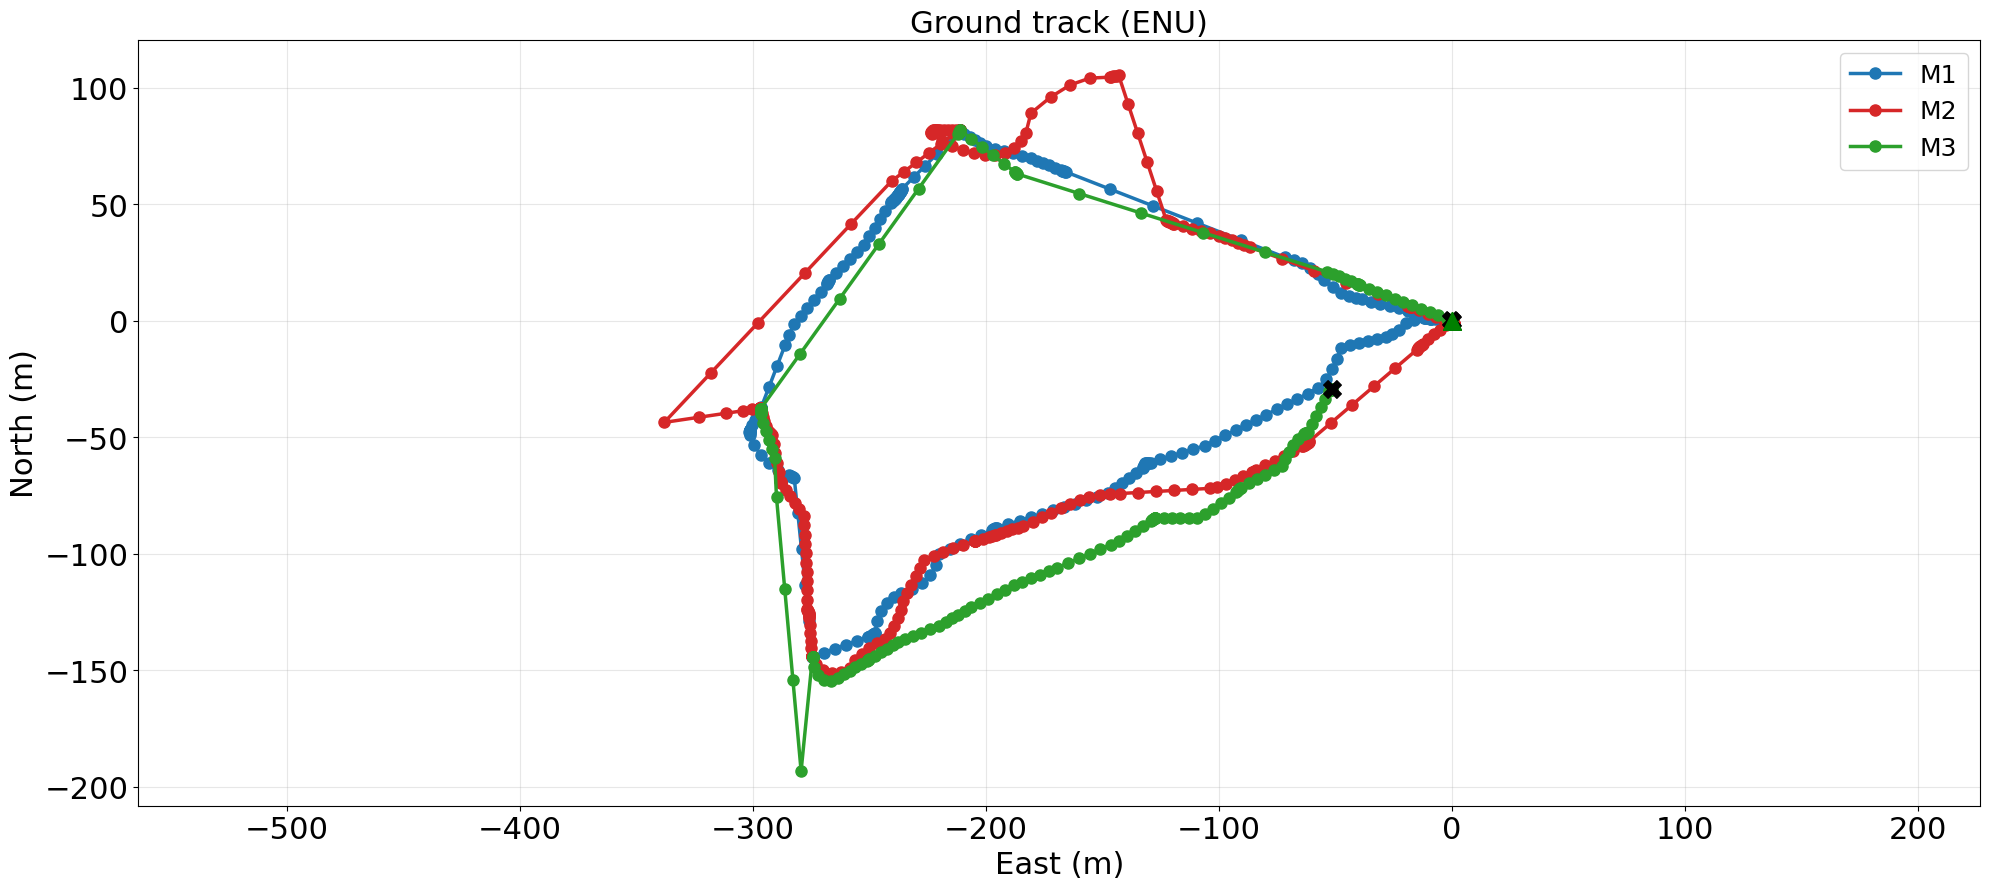

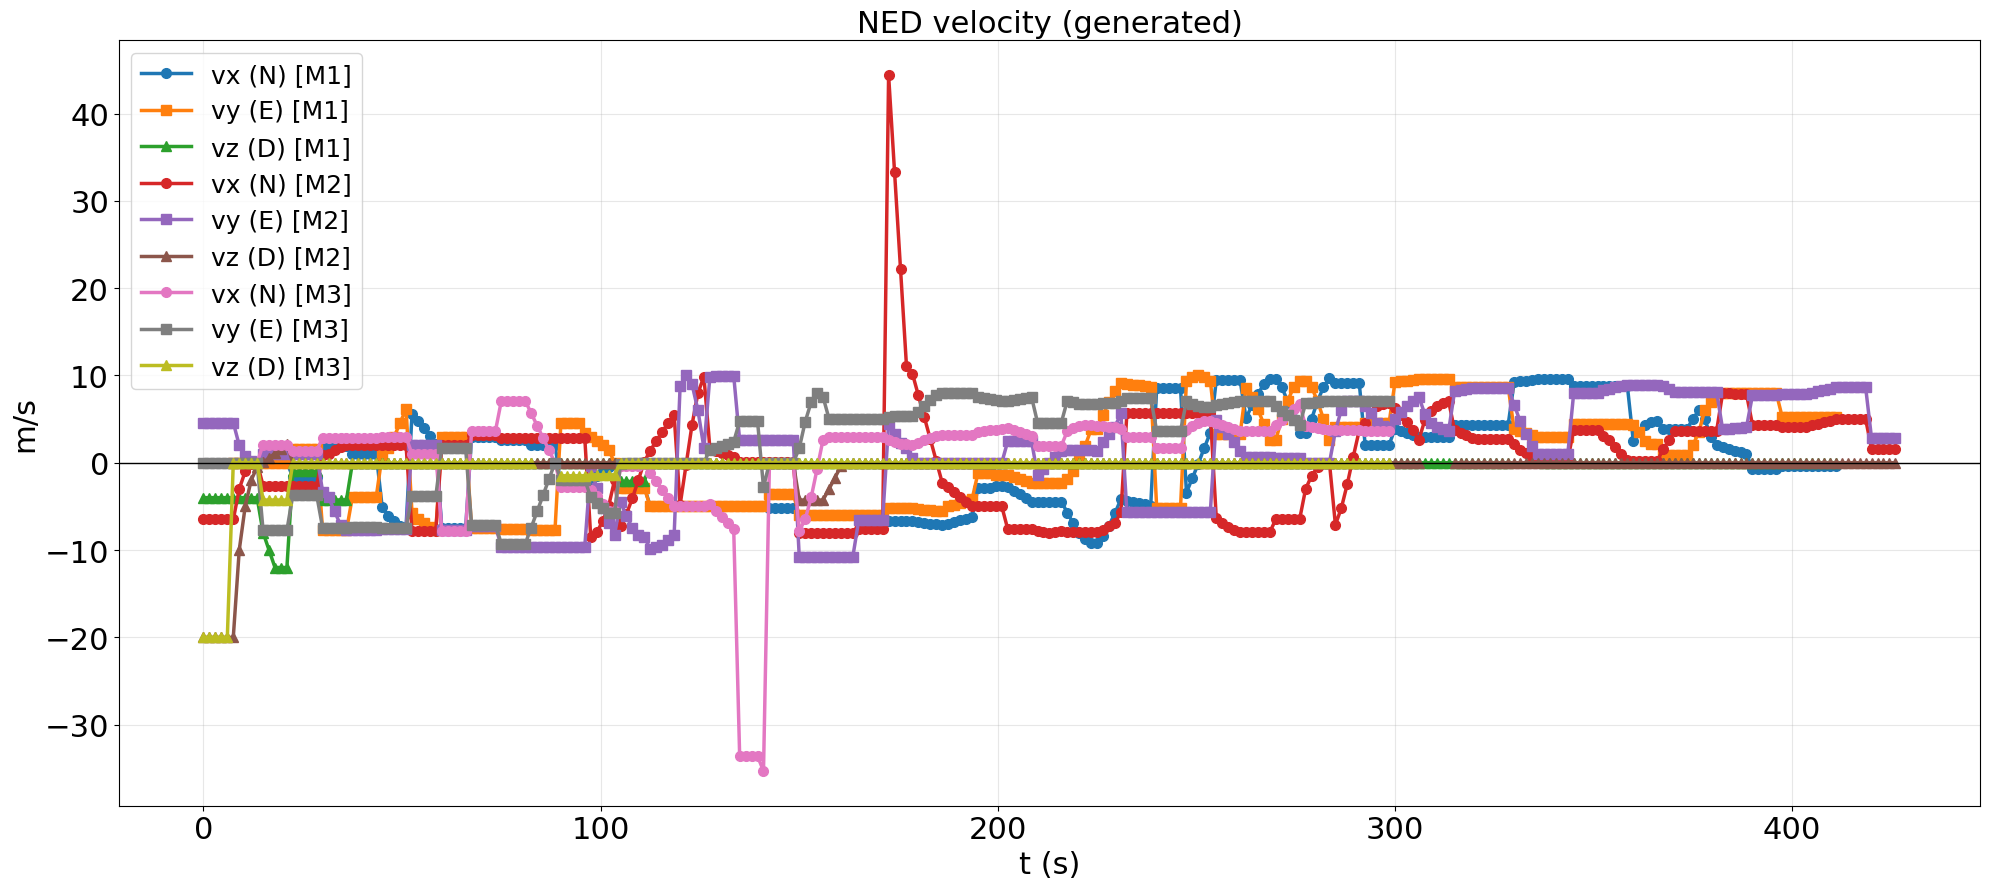

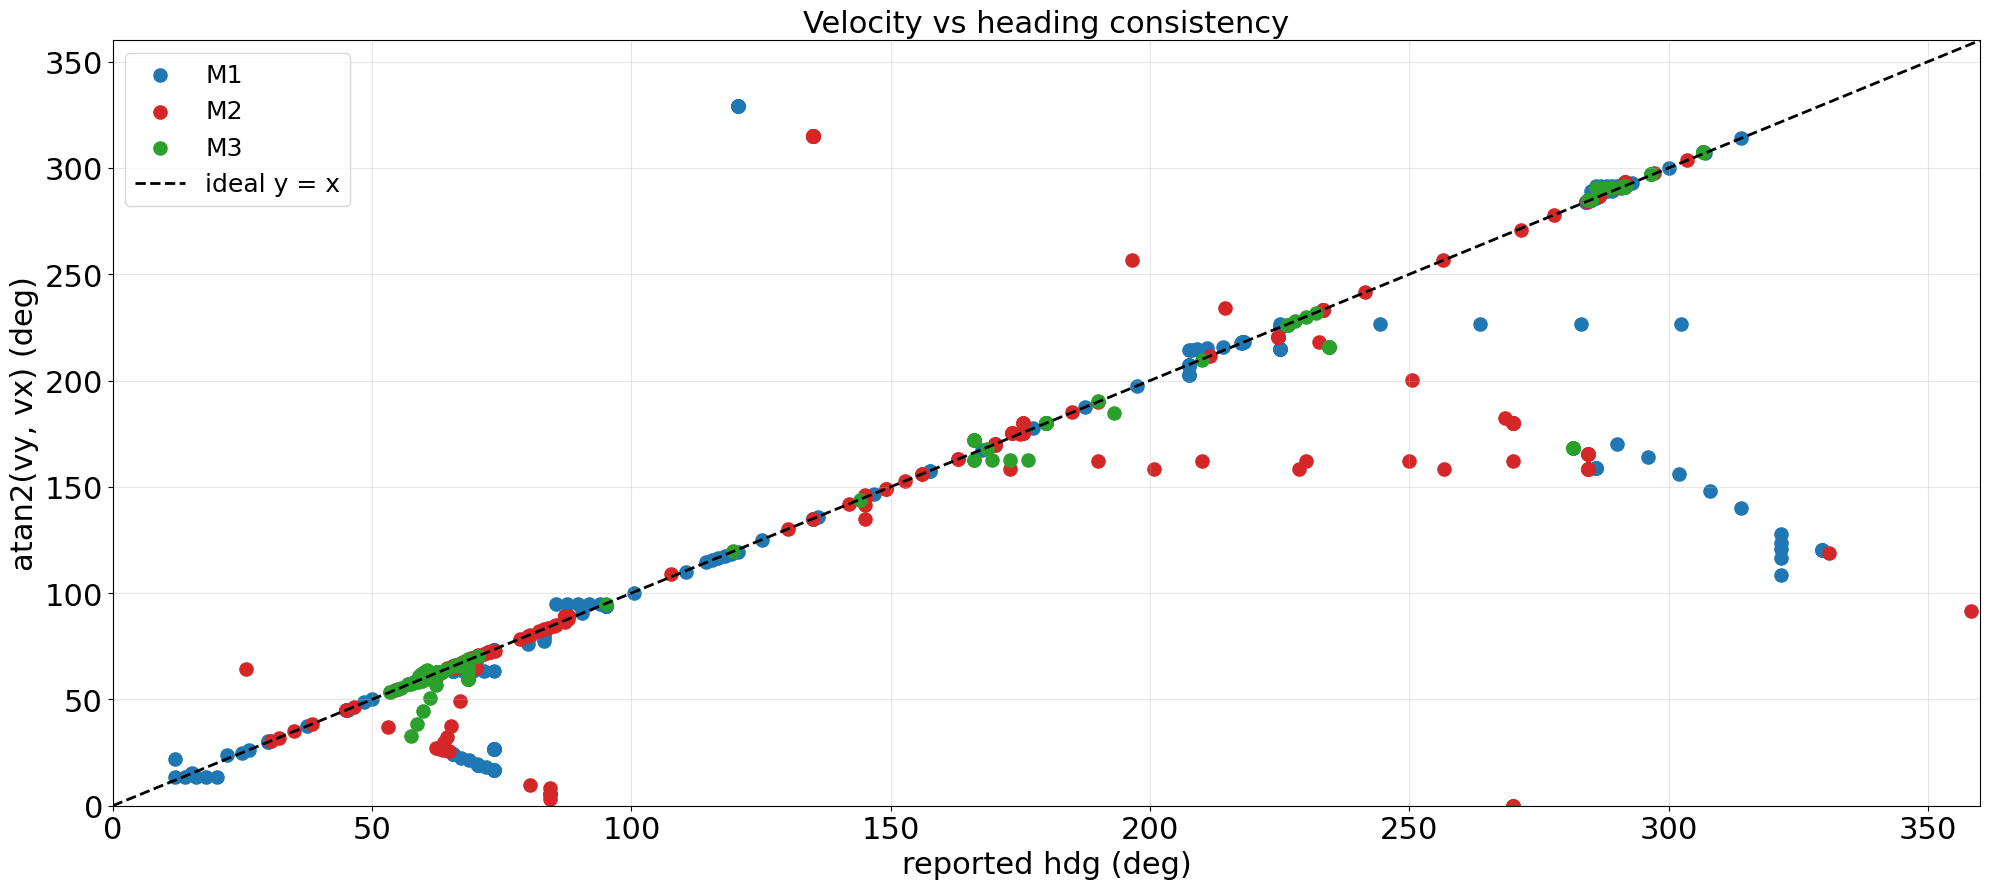

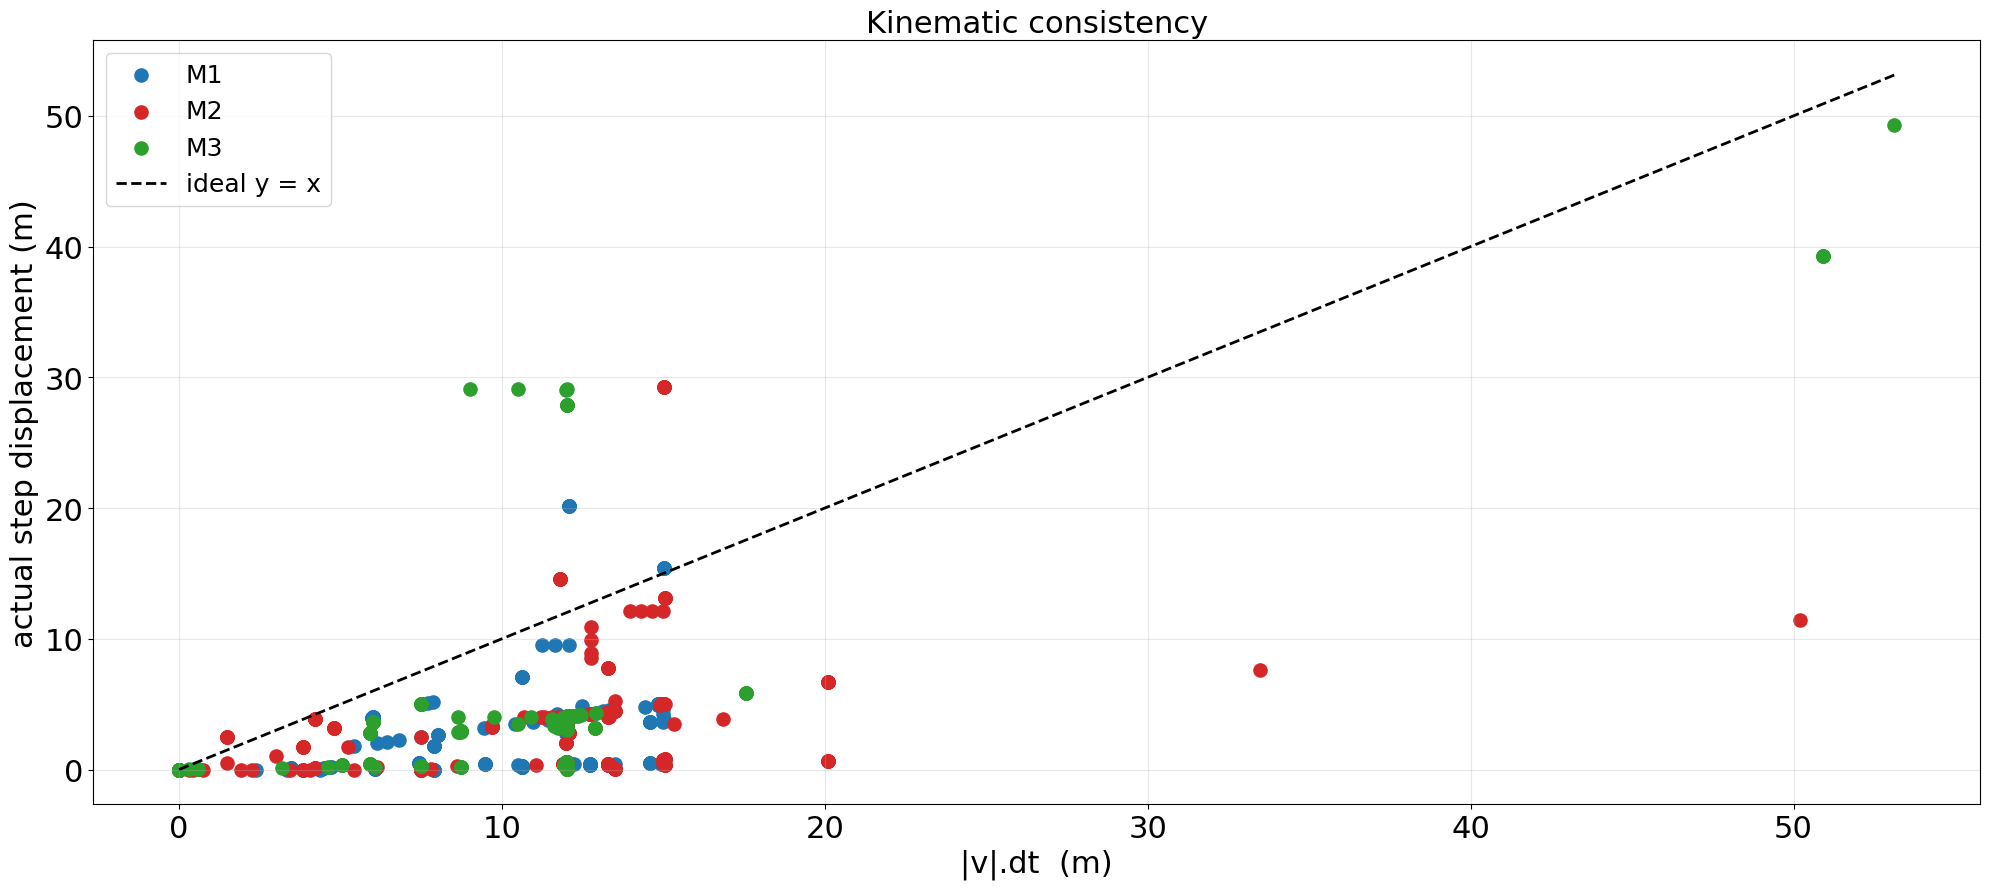

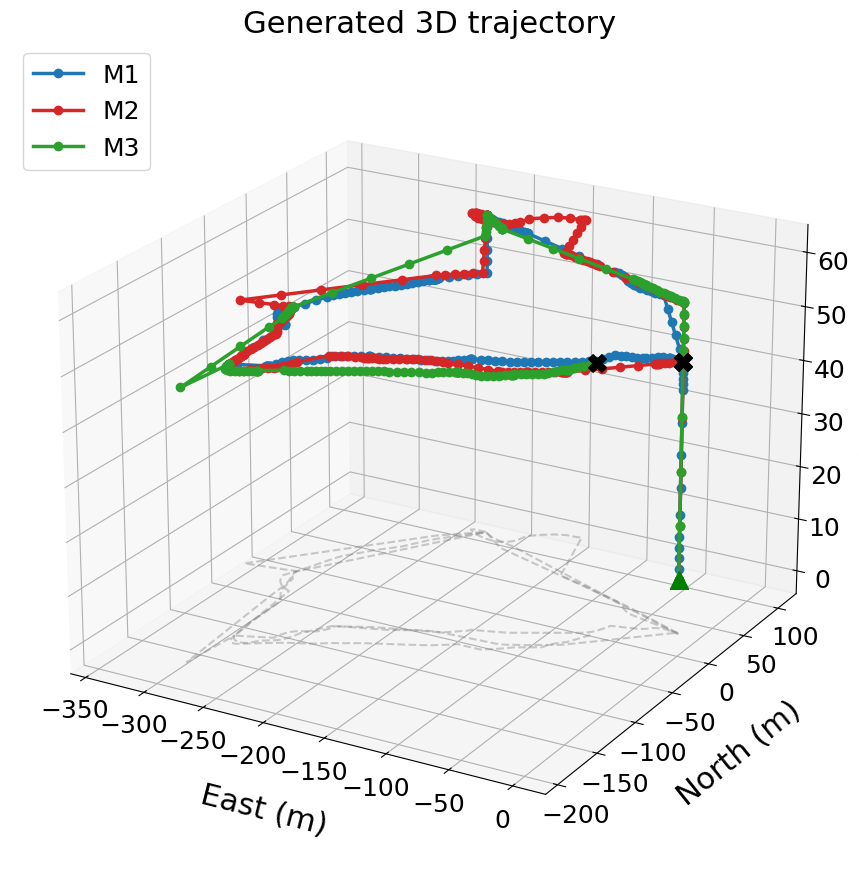

Saved 5 plots for [M1_M2_M3] -> mission_plots/


In [11]:
"""
Telemetry plotting helpers for LLM-generated MAVLink evaluation.

Reads a paired-row CSV with columns:
  mission_run_id, mission_name, mission_seq, command_name, llm_call_id,
  llm_step_index, dt,
  input_gpi_lat/lon/relative_alt/vx/vy/vz/hdg,
  generated_gpi_lat/lon/relative_alt/vx/vy/vz/hdg, ...

Pick which run(s) to plot via SELECTED_MISSIONS (label -> mission_run_id).
Selected runs are overlaid, each in its own colour, legended by the short label.

Unit conventions in the raw log:
  lat/lon       : int 1e-7 -> degrees
  relative_alt  : mm       -> metres
  vx/vy/vz      : cm/s      -> m/s   (NED: vz < 0 = climbing)
  hdg           : centideg  -> degrees
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)

# ============================================================
# Config
# ============================================================

INPUT_CSV = Path("../tests/logs/mission_llm_generation_v2.csv")
OUT_DIR = Path("mission_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# If many missions exist, set this to limit the overlay.
# Example: MAX_MISSIONS = 5
MAX_MISSIONS = None


# ============================================================
# Select missions manually   (label -> mission_run_id)
# ============================================================

SELECTED_MISSIONS = {
    "M1": "mission_20260625_170759",
    # "M1": "mission_20260609_144632",
    "M2": "mission_20260626_105656",
    "M3": "mission_20260626_164603"
}


# Canonical v2 header. Used to name columns when the CSV has no header row
# (e.g. an appended log). If the file already has a valid header it is trusted.
COLUMNS = [
    "mission_run_id", "mission_name", "timestamp", "mission_seq",
    "mission_status", "command_id", "command_name", "frame", "current",
    "autocontinue", "param1", "param2", "param3", "param4", "param5",
    "param6", "param7", "target_lat", "target_lon", "target_alt",
    "llm_call_id", "llm_step_index", "dt", "llm_latency_ms", "llm_model_name",
    "input_gpi_lat", "input_gpi_lon", "input_gpi_alt", "input_gpi_relative_alt",
    "input_gpi_vx", "input_gpi_vy", "input_gpi_vz", "input_gpi_hdg",
    "input_roll", "input_pitch", "input_yaw", "input_vfr_groundspeed",
    "input_vfr_heading", "input_vfr_throttle", "input_vfr_alt",
    "input_vfr_climb", "input_battery_remaining", "input_voltage_battery",
    "input_load", "input_gps_fix_type",
    "generated_gpi_lat", "generated_gpi_lon", "generated_gpi_alt",
    "generated_gpi_relative_alt", "generated_gpi_vx", "generated_gpi_vy",
    "generated_gpi_vz", "generated_gpi_hdg", "generated_att_roll",
    "generated_att_pitch", "generated_att_yaw", "generated_vfr_groundspeed",
    "generated_vfr_heading", "generated_vfr_throttle", "generated_vfr_alt",
    "generated_vfr_climb", "generated_sys_battery_remaining",
    "generated_sys_voltage_battery", "generated_sys_load",
    "generated_gps_fix_type",
]


# ============================================================
# Internals
# ============================================================

ID_COL = "mission_run_id"
LABEL_COL = "label"

FIGSIZE = (20, 9)
TICK_FS, AXIS_FS, LEG_FS = 22, 22, 18
PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e", "#17becf"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})


def _style(ax, title, xlabel, ylabel, legend=True):
    ax.set_title(title, fontsize=AXIS_FS)
    ax.set_xlabel(xlabel, fontsize=AXIS_FS)
    ax.set_ylabel(ylabel, fontsize=AXIS_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.grid(alpha=0.3)
    if legend:
        ax.legend(fontsize=LEG_FS)


def _read(path, usecols=None):
    """Read the log whether or not it carries a header row.
    If the first cell isn't 'mission_run_id', treat the file as headerless
    and apply COLUMNS as names."""
    path = Path(path)
    with open(path) as f:
        first_cell = f.readline().split(",")[0].strip().strip('"')
    if first_cell == "mission_run_id":
        return pd.read_csv(path, usecols=usecols)
    return pd.read_csv(path, header=None, names=COLUMNS, usecols=usecols)


def list_missions(path=INPUT_CSV):
    """Return the available mission_run_id values (with row counts)."""
    df = _read(path, usecols=[ID_COL])
    return df[ID_COL].value_counts().sort_index()


def _decode_one(grp, side):
    p = f"{side}_gpi_"
    g = pd.DataFrame(index=grp.index)
    g["lat"] = grp[p + "lat"] * 1e-7
    g["lon"] = grp[p + "lon"] * 1e-7
    g["up"] = grp[p + "relative_alt"] / 1000.0
    g["vx"] = grp[p + "vx"] / 100.0
    g["vy"] = grp[p + "vy"] / 100.0
    g["vz"] = grp[p + "vz"] / 100.0
    g["hdg"] = grp[p + "hdg"] / 100.0
    for c in (ID_COL, "llm_call_id", "llm_step_index", "dt",
              "mission_seq", "command_name"):
        if c in grp.columns:
            g[c] = grp[c].values

    # local ENU metres about THIS mission's first VALID fix
    # (some logs have empty generated lat/lon on the opening call)
    valid = g[["lat", "lon"]].dropna()
    if valid.empty:
        lat0 = lon0 = 0.0
    else:
        lat0, lon0 = valid.iloc[0]["lat"], valid.iloc[0]["lon"]
    g["E"] = (g["lon"] - lon0) * (111320.0 * np.cos(np.radians(lat0)))
    g["N"] = (g["lat"] - lat0) * 111320.0

    # time axis reset per mission
    dt = float(np.median(g["dt"].fillna(0.5))) if "dt" in g else 0.5
    g["t"] = np.arange(len(g)) * dt
    return g


def _resolve(missions):
    """Normalise the `missions` argument to (ordered_ids, label_map)."""
    if missions is None:
        return None, {}
    if isinstance(missions, dict):                       # {label: run_id}
        ids = list(missions.values())
        return ids, {v: k for k, v in missions.items()}
    if isinstance(missions, str):                        # "a, b, c"
        ids = [m.strip() for m in missions.split(",") if m.strip()]
        return ids, {}
    return list(missions), {}                            # list/tuple


def load(missions=SELECTED_MISSIONS, path=INPUT_CSV, side="generated",
         max_missions=MAX_MISSIONS):
    """Read the CSV and return a decoded frame with ONLY the selected runs.

    missions : dict {label: run_id}  (default SELECTED_MISSIONS)
               | "a, b, c" | ["a", "b"] | "a" | None (all runs)
    side     : 'generated' or 'input'
    max_missions : cap the number of overlaid runs (None = no cap)

    Each run keeps its own ENU origin and time axis, and a `label` column
    used for legends (falls back to the run id when no label was given).
    """
    df = _read(path)
    available = list(df[ID_COL].unique())

    ids, label_map = _resolve(missions)
    if ids is None:
        ids = available
    else:
        unknown = [m for m in ids if m not in available]
        if unknown:
            raise ValueError(
                f"mission(s) not in {path}: {unknown}\n"
                f"available: {sorted(available)}")

    if max_missions is not None:
        ids = ids[:max_missions]

    # decode each run separately, preserving selection order for stable colours
    frames = []
    for mid in ids:
        grp = df[df[ID_COL] == mid]
        g = _decode_one(grp, side)
        g[LABEL_COL] = label_map.get(mid, mid)
        frames.append(g)
    return pd.concat(frames, ignore_index=True)


def _iter(g):
    """Yield (index, label, sub) per run in stable selection order."""
    for k, mid in enumerate(pd.unique(g[ID_COL])):
        sub = g[g[ID_COL] == mid]
        lab = sub[LABEL_COL].iloc[0] if LABEL_COL in sub else mid
        yield k, lab, sub


def _multi(g):
    return (ID_COL in g) and g[ID_COL].nunique() > 1


def _xy(sub, cols):
    """Drop rows where any of cols is NaN (so lines/markers skip gaps)."""
    return sub.dropna(subset=cols)


# ============================================================
# Plots
# ============================================================

def plot_ground_track(g, ax=None):
    ax = ax or plt.figure(figsize=FIGSIZE).add_subplot(111)
    for k, lab, sub in _iter(g):
        sub = _xy(sub, ["E", "N"])
        if sub.empty:
            continue
        ax.plot(sub["E"], sub["N"], "-o", color=PALETTE[k % len(PALETTE)],
                lw=2.5, ms=8, label=lab)
        ax.scatter(sub["E"].iloc[0], sub["N"].iloc[0], color="green", s=160,
                   marker="^", zorder=5)
        ax.scatter(sub["E"].iloc[-1], sub["N"].iloc[-1], color="black", s=160,
                   marker="X", zorder=5)
    ax.set_aspect("equal", adjustable="datalim")
    _style(ax, "Ground track (ENU)", "East (m)", "North (m)", legend=True)
    return ax


def plot_ned_velocity(g, ax=None):
    ax = ax or plt.figure(figsize=FIGSIZE).add_subplot(111)
    multi = _multi(g)
    for k, lab, sub in _iter(g):
        tag = f" [{lab}]" if multi else ""
        ax.plot(sub["t"], sub["vx"], "-o", lw=2.5, ms=7, label="vx (N)" + tag)
        ax.plot(sub["t"], sub["vy"], "-s", lw=2.5, ms=7, label="vy (E)" + tag)
        ax.plot(sub["t"], sub["vz"], "-^", lw=2.5, ms=7, label="vz (D)" + tag)
    ax.axhline(0, color="k", lw=1)
    _style(ax, "NED velocity (generated)", "t (s)", "m/s")
    return ax


def plot_velocity_heading(g, ax=None, speed_floor=0.2):
    ax = ax or plt.figure(figsize=FIGSIZE).add_subplot(111)
    multi = _multi(g)
    for k, lab, sub in _iter(g):
        moving = (sub["vx"].abs() + sub["vy"].abs()) > speed_floor
        course = np.degrees(np.arctan2(sub["vy"], sub["vx"])) % 360
        ax.scatter(sub["hdg"][moving], course[moving], s=90,
                   color=PALETTE[k % len(PALETTE)],
                   label=lab if multi else "steps (|v| > floor)")
    ax.plot([0, 360], [0, 360], "k--", lw=2, label="ideal y = x")
    ax.set_xlim(0, 360)
    ax.set_ylim(0, 360)
    _style(ax, "Velocity vs heading consistency",
           "reported hdg (deg)", "atan2(vy, vx) (deg)")
    return ax


def plot_kinematic(g, ax=None):
    ax = ax or plt.figure(figsize=FIGSIZE).add_subplot(111)
    multi = _multi(g)
    mx = 1e-6
    for k, lab, sub in _iter(g):
        dx, dy = sub["E"].diff(), sub["N"].diff()
        step_dist = np.sqrt(dx ** 2 + dy ** 2)
        dt = float(np.median(sub["dt"].fillna(0.5))) if "dt" in sub else 0.5
        pred = np.sqrt(sub["vx"] ** 2 + sub["vy"] ** 2) * dt
        if "llm_call_id" in sub:
            same = sub["llm_call_id"].eq(sub["llm_call_id"].shift())
        else:
            same = pd.Series(True, index=sub.index)
        sd, pe = step_dist[same], pred[same]
        ax.scatter(pe, sd, s=90, color=PALETTE[k % len(PALETTE)],
                   label=lab if multi else "steps (same call)")
        mx = float(np.nanmax([mx, pe.max(), sd.max()]))
    ax.plot([0, mx], [0, mx], "k--", lw=2, label="ideal y = x")
    _style(ax, "Kinematic consistency",
           "|v|.dt  (m)", "actual step displacement (m)")
    return ax


def plot_trajectory_3d(g, color_by="mission_seq", ax=None):
    ax = ax or plt.figure(figsize=FIGSIZE).add_subplot(111, projection="3d")
    multi = _multi(g)

    for k, lab, sub in _iter(g):
        sub = _xy(sub, ["E", "N", "up"])
        if sub.empty:
            continue
        if multi:
            ax.plot(sub["E"], sub["N"], sub["up"], "-o",
                    color=PALETTE[k % len(PALETTE)], lw=2.5, ms=6, label=lab)
        elif color_by in sub and sub[color_by].nunique() > 1:
            for j, (key, leg) in enumerate(sub.groupby(color_by)):
                if leg.empty:
                    continue
                name = leg["command_name"].iloc[0] if "command_name" in leg else ""
                ax.plot(leg["E"], leg["N"], leg["up"], "-o",
                        color=PALETTE[j % len(PALETTE)], lw=2.5, ms=6,
                        label=f"{color_by} {key}: {name}".strip(": "))
        else:
            ax.plot(sub["E"], sub["N"], sub["up"], "-o", color="#1f77b4",
                    lw=2.5, ms=6, label=lab)
        ax.plot(sub["E"], sub["N"], np.zeros(len(sub)), color="grey",
                alpha=0.4, lw=1.5, ls="--")
        ax.scatter(sub["E"].iloc[0], sub["N"].iloc[0], sub["up"].iloc[0],
                   color="green", s=160, marker="^", depthshade=False)
        ax.scatter(sub["E"].iloc[-1], sub["N"].iloc[-1], sub["up"].iloc[-1],
                   color="black", s=160, marker="X", depthshade=False)

    ax.set_xlabel("East (m)", fontsize=AXIS_FS, labelpad=20)
    ax.set_ylabel("North (m)", fontsize=AXIS_FS, labelpad=20)
    ax.set_zlabel("Up (m)", fontsize=AXIS_FS, labelpad=12)
    ax.tick_params(labelsize=TICK_FS - 4)
    ax.set_title("Generated 3D trajectory", fontsize=AXIS_FS)
    ax.legend(fontsize=LEG_FS, loc="upper left")
    ax.view_init(elev=22, azim=-60)
    return ax


# ============================================================
# Driver: render every plot to OUT_DIR
# ============================================================

PLOTS = {
    "ground_track": plot_ground_track,
    "ned_velocity": plot_ned_velocity,
    "velocity_heading": plot_velocity_heading,
    "kinematic": plot_kinematic,
}


def render_all(missions=SELECTED_MISSIONS, path=INPUT_CSV, out_dir=OUT_DIR,
               side="generated", max_missions=MAX_MISSIONS, show=False):
    """Load the selected runs and save all plots into out_dir.
    Filenames are suffixed with the joined run labels."""
    g = load(missions, path=path, side=side, max_missions=max_missions)
    tag = "_".join(dict.fromkeys(g[LABEL_COL]))  # ordered, de-duplicated

    for name, fn in PLOTS.items():
        fn(g)
        plt.tight_layout()
        plt.savefig(out_dir / f"{name}_{tag}.png", dpi=110,
                    bbox_inches="tight", facecolor="white")
        plt.show() if show else plt.close()

    plot_trajectory_3d(g)
    plt.tight_layout()
    plt.savefig(out_dir / f"trajectory3d_{tag}.png", dpi=110,
                bbox_inches="tight", facecolor="white")
    plt.show() if show else plt.close()

    print(f"Saved {len(PLOTS) + 1} plots for [{tag}] -> {out_dir}/")
    return g


if __name__ == "__main__":
    print("Available missions:")
    print(list_missions())
    render_all(show=True)

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Config
# ============================================================

INPUT_CSV = Path("../tests/logs/mission_llm_generation_v2.csv")
OUT_DIR = Path("mission_velocity_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_MISSIONS = {
    "M1": "mission_20260625_170759",
    "M2": "mission_20260626_105656",
    "M3": "mission_20260626_164603",
}

# Set to None if you want all missions:
# SELECTED_MISSIONS = None


# ============================================================
# Plot style
# ============================================================

FIGSIZE_WIDE = (20, 9)

AXIS_FS = 22
TICK_FS = 22
TITLE_FS = 24
LEG_FS = 16

LINE_W = 2.5
MARKER_SIZE = 7

PALETTE = [
    "#1f77b4",
    "#d62728",
    "#2ca02c",
    "#9467bd",
    "#ff7f0e",
    "#17becf",
]


# ============================================================
# Velocity acceptability limits
# ============================================================

HVEL_MAX_MPS = 12.0          # horizontal speed limit, m/s
VZ_CLIMB_MAX_MPS = -3.0      # NED vz: negative = climbing
VZ_DESCENT_MAX_MPS = 1.5     # NED vz: positive = descending

KIN_TOLERANCE = 0.25         # ±25% around ideal y = x


# ============================================================
# CSV header
# ============================================================

COLUMNS = [
    "mission_run_id",
    "mission_name",
    "timestamp",
    "mission_seq",
    "mission_status",
    "command_id",
    "command_name",
    "frame",
    "current",
    "autocontinue",
    "param1",
    "param2",
    "param3",
    "param4",
    "param5",
    "param6",
    "param7",
    "target_lat",
    "target_lon",
    "target_alt",
    "llm_call_id",
    "llm_step_index",
    "dt",
    "llm_latency_ms",
    "llm_model_name",
    "input_gpi_lat",
    "input_gpi_lon",
    "input_gpi_alt",
    "input_gpi_relative_alt",
    "input_gpi_vx",
    "input_gpi_vy",
    "input_gpi_vz",
    "input_gpi_hdg",
    "input_roll",
    "input_pitch",
    "input_yaw",
    "input_vfr_groundspeed",
    "input_vfr_heading",
    "input_vfr_throttle",
    "input_vfr_alt",
    "input_vfr_climb",
    "input_battery_remaining",
    "input_voltage_battery",
    "input_load",
    "input_gps_fix_type",
    "generated_gpi_lat",
    "generated_gpi_lon",
    "generated_gpi_alt",
    "generated_gpi_relative_alt",
    "generated_gpi_vx",
    "generated_gpi_vy",
    "generated_gpi_vz",
    "generated_gpi_hdg",
    "generated_att_roll",
    "generated_att_pitch",
    "generated_att_yaw",
    "generated_vfr_groundspeed",
    "generated_vfr_heading",
    "generated_vfr_throttle",
    "generated_vfr_alt",
    "generated_vfr_climb",
    "generated_sys_battery_remaining",
    "generated_sys_voltage_battery",
    "generated_sys_load",
    "generated_gps_fix_type",
]


# ============================================================
# Helpers
# ============================================================

def short_label(x, max_len=18):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."


def save_plot(filename):
    path = OUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"Saved: {path}")


def style_2d_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=TITLE_FS)
    ax.set_xlabel(xlabel, fontsize=AXIS_FS)
    ax.set_ylabel(ylabel, fontsize=AXIS_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEG_FS)


def load_mission_csv(path: Path) -> pd.DataFrame:
    """
    Loads the mission CSV.

    Handles:
    1. CSV with header
    2. CSV without header
    3. CSV with extra columns
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find input file: {path}")

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        first_cell = f.readline().split(",")[0].strip().strip('"')

    if first_cell == "mission_run_id":
        df = pd.read_csv(path, na_values=["", "nan", "NaN", "None"])
    else:
        raw = pd.read_csv(
            path,
            header=None,
            na_values=["", "nan", "NaN", "None"],
        )

        ncols = raw.shape[1]

        if ncols <= len(COLUMNS):
            raw.columns = COLUMNS[:ncols]
        else:
            extra_cols = [f"extra_col_{i}" for i in range(ncols - len(COLUMNS))]
            raw.columns = COLUMNS + extra_cols

        df = raw

    text_cols = {
        "mission_run_id",
        "mission_name",
        "mission_status",
        "command_name",
        "llm_call_id",
        "llm_model_name",
    }

    for col in df.columns:
        if col not in text_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def select_missions(df: pd.DataFrame, missions=SELECTED_MISSIONS) -> pd.DataFrame:
    df = df.copy()

    if missions is None:
        df["mission_label"] = df["mission_run_id"]
        return df

    mission_id_to_label = {
        mission_id: label
        for label, mission_id in missions.items()
    }

    selected_ids = list(mission_id_to_label.keys())

    available = set(df["mission_run_id"].dropna().unique())
    missing = [mid for mid in selected_ids if mid not in available]

    if missing:
        print("\nAvailable mission_run_id values:")
        for mid in sorted(available):
            print(mid)
        raise ValueError(f"\nSelected mission IDs not found: {missing}")

    df = df[df["mission_run_id"].isin(selected_ids)].copy()
    df["mission_label"] = df["mission_run_id"].map(mission_id_to_label)

    return df


def add_derived_fields(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # -----------------------------
    # Convert lat/lon to degrees
    # -----------------------------
    latlon_cols = [
        "target_lat",
        "target_lon",
        "input_gpi_lat",
        "input_gpi_lon",
        "generated_gpi_lat",
        "generated_gpi_lon",
    ]

    for col in latlon_cols:
        if col in df.columns:
            df[col + "_deg"] = df[col] / 1e7

    # -----------------------------
    # Velocity cm/s -> m/s
    # -----------------------------
    df["generated_vx_mps"] = df["generated_gpi_vx"] / 100.0
    df["generated_vy_mps"] = df["generated_gpi_vy"] / 100.0
    df["generated_vz_mps"] = df["generated_gpi_vz"] / 100.0

    df["horizontal_speed_mps"] = np.sqrt(
        df["generated_vx_mps"] ** 2 + df["generated_vy_mps"] ** 2
    )

    # -----------------------------
    # Elapsed time per mission
    # -----------------------------
    df["elapsed_s"] = np.nan

    for _, group in df.groupby("mission_label", sort=False):
        idx = group.index

        if (
            "timestamp" in group.columns
            and group["timestamp"].notna().any()
            and group["timestamp"].nunique(dropna=True) > 1
        ):
            base_time = group["timestamp"].dropna().min()
            df.loc[idx, "elapsed_s"] = (
                group["timestamp"] - base_time + group["dt"].fillna(0)
            )
        else:
            # fallback if timestamp is absent or constant
            df.loc[idx, "elapsed_s"] = np.arange(len(group)) * 0.5

    return df


def add_local_meter_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Converts generated lat/lon to local East/North meters.

    Uses the first valid generated point as origin.
    """

    df = df.copy()

    valid = df.dropna(
        subset=["generated_gpi_lat_deg", "generated_gpi_lon_deg"]
    ).copy()

    valid = valid[
        ~((valid["generated_gpi_lat_deg"] == 0) & (valid["generated_gpi_lon_deg"] == 0))
    ]

    if valid.empty:
        raise ValueError("No valid generated latitude/longitude found.")

    lat0 = valid["generated_gpi_lat_deg"].iloc[0]
    lon0 = valid["generated_gpi_lon_deg"].iloc[0]

    meters_per_deg_lat = 111_320.0
    meters_per_deg_lon = 111_320.0 * np.cos(np.radians(lat0))

    df["generated_E"] = (
        df["generated_gpi_lon_deg"] - lon0
    ) * meters_per_deg_lon

    df["generated_N"] = (
        df["generated_gpi_lat_deg"] - lat0
    ) * meters_per_deg_lat

    return df


def prepare_dataframe(path: Path, missions=SELECTED_MISSIONS) -> pd.DataFrame:
    df = load_mission_csv(path)
    df = select_missions(df, missions=missions)

    if df.empty:
        raise ValueError("No rows found after mission selection.")

    required = [
        "mission_run_id",
        "generated_gpi_lat",
        "generated_gpi_lon",
        "generated_gpi_vx",
        "generated_gpi_vy",
        "generated_gpi_vz",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = add_derived_fields(df)
    df = add_local_meter_coordinates(df)

    return df


def iter_missions(df: pd.DataFrame):
    for k, (mission_id, group) in enumerate(df.groupby("mission_run_id", sort=False)):
        label = group["mission_label"].iloc[0]
        color = PALETTE[k % len(PALETTE)]
        yield k, mission_id, label, color, group


def list_missions(path: Path):
    df = load_mission_csv(path)
    return df["mission_run_id"].value_counts().sort_index()


# ============================================================
# Plot 1: NED velocity with acceptable range
# ============================================================

def plot_ned_velocity_with_acceptable_range(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    # Acceptable vx/vy component band
    ax.axhspan(
        -HVEL_MAX_MPS,
        HVEL_MAX_MPS,
        alpha=0.08,
        label=f"vx/vy component range ±{HVEL_MAX_MPS:g} m/s",
        zorder=0,
    )

    # Acceptable vz NED band
    ax.axhspan(
        VZ_CLIMB_MAX_MPS,
        VZ_DESCENT_MAX_MPS,
        alpha=0.18,
        label=f"vz range {VZ_CLIMB_MAX_MPS:g} to +{VZ_DESCENT_MAX_MPS:g} m/s",
        zorder=0,
    )

    ax.axhline(HVEL_MAX_MPS, linestyle="--", linewidth=2.0)
    ax.axhline(-HVEL_MAX_MPS, linestyle="--", linewidth=2.0)

    ax.axhline(VZ_CLIMB_MAX_MPS, linestyle=":", linewidth=2.5)
    ax.axhline(VZ_DESCENT_MAX_MPS, linestyle=":", linewidth=2.5)

    multi = df["mission_run_id"].nunique() > 1

    for _, _, label, color, group in iter_missions(df):
        tag = f" [{label}]" if multi else ""

        sub = group.dropna(
            subset=[
                "elapsed_s",
                "generated_vx_mps",
                "generated_vy_mps",
                "generated_vz_mps",
            ]
        )

        if sub.empty:
            continue

        ax.plot(
            sub["elapsed_s"],
            sub["generated_vx_mps"],
            "-o",
            linewidth=LINE_W,
            markersize=MARKER_SIZE,
            label="vx (N)" + tag,
        )

        ax.plot(
            sub["elapsed_s"],
            sub["generated_vy_mps"],
            "-s",
            linewidth=LINE_W,
            markersize=MARKER_SIZE,
            label="vy (E)" + tag,
        )

        ax.plot(
            sub["elapsed_s"],
            sub["generated_vz_mps"],
            "-^",
            linewidth=LINE_W,
            markersize=MARKER_SIZE,
            label="vz (D)" + tag,
        )

    ax.axhline(0, color="black", linewidth=1.2)

    style_2d_axis(
        ax,
        title="",
        xlabel="Elapsed time (s)",
        ylabel="Velocity (m/s)",
    )

    save_plot("velocity_ned_acceptable_range.png")


# ============================================================
# Plot 2: Horizontal speed acceptability
# ============================================================

def plot_horizontal_speed_acceptability(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    ax.axhspan(
        0,
        HVEL_MAX_MPS,
        alpha=0.15,
        label=f"acceptable horizontal speed ≤ {HVEL_MAX_MPS:g} m/s",
        zorder=0,
    )

    ax.axhline(
        HVEL_MAX_MPS,
        linestyle="--",
        linewidth=2.5,
        label=f"limit = {HVEL_MAX_MPS:g} m/s",
    )

    for _, _, label, color, group in iter_missions(df):
        sub = group.dropna(
            subset=["elapsed_s", "horizontal_speed_mps"]
        ).copy()

        if sub.empty:
            continue

        ax.plot(
            sub["elapsed_s"],
            sub["horizontal_speed_mps"],
            "-o",
            color=color,
            linewidth=LINE_W,
            markersize=MARKER_SIZE,
            label=short_label(label),
        )

    style_2d_axis(
        ax,
        title="Horizontal speed acceptability",
        xlabel="Elapsed time within mission (s)",
        ylabel="Horizontal speed (m/s)",
    )

    save_plot("velocity_horizontal_speed_acceptability.png")


# ============================================================
# Plot 3: Kinematic consistency with acceptable band
# ============================================================

def plot_kinematic_consistency_with_band(
    df: pd.DataFrame,
    tolerance: float = KIN_TOLERANCE,
):
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    max_axis = 1e-6

    for _, _, label, color, group in iter_missions(df):
        sub = group.dropna(
            subset=[
                "generated_E",
                "generated_N",
                "horizontal_speed_mps",
            ]
        ).copy()

        if sub.empty:
            continue

        dx = sub["generated_E"].diff()
        dy = sub["generated_N"].diff()

        actual_step_m = np.sqrt(dx ** 2 + dy ** 2)

        if "dt" in sub.columns and sub["dt"].notna().any():
            dt = sub["dt"].fillna(0.5)
        else:
            dt = pd.Series(0.5, index=sub.index)

        predicted_step_m = sub["horizontal_speed_mps"] * dt

        valid = actual_step_m.notna() & predicted_step_m.notna()

        x = predicted_step_m[valid]
        y = actual_step_m[valid]

        if x.empty:
            continue

        ax.scatter(
            x,
            y,
            s=120,
            color=color,
            label=short_label(label),
        )

        max_axis = max(max_axis, float(x.max()), float(y.max()))

    xx = np.linspace(0, max_axis, 300)

    lower = (1.0 - tolerance) * xx
    upper = (1.0 + tolerance) * xx

    ax.fill_between(
        xx,
        lower,
        upper,
        alpha=0.18,
        label=f"acceptable ±{int(tolerance * 100)}%",
    )

    ax.plot(
        xx,
        xx,
        "k--",
        linewidth=2.5,
        label="ideal y = x",
    )

    style_2d_axis(
        ax,
        title="Kinematic consistency with acceptable band",
        xlabel=r"$|v|\cdot dt$  (m)",
        ylabel="Actual step displacement (m)",
    )

    save_plot("kinematic_consistency_acceptable_band.png")


# ============================================================
# Summary CSV
# ============================================================

def save_velocity_violation_summary(df: pd.DataFrame):
    rows = []

    for _, mission_id, label, _, group in iter_missions(df):
        sub = group.copy()

        horizontal_bad = sub["horizontal_speed_mps"] > HVEL_MAX_MPS
        vz_bad = (
            (sub["generated_vz_mps"] < VZ_CLIMB_MAX_MPS)
            | (sub["generated_vz_mps"] > VZ_DESCENT_MAX_MPS)
        )

        total_rows = len(sub)

        rows.append(
            {
                "mission_label": label,
                "mission_run_id": mission_id,
                "rows": total_rows,
                "horizontal_speed_violations": int(horizontal_bad.sum()),
                "horizontal_speed_violation_pct": 100.0 * horizontal_bad.sum() / total_rows,
                "vz_violations": int(vz_bad.sum()),
                "vz_violation_pct": 100.0 * vz_bad.sum() / total_rows,
                "max_horizontal_speed_mps": sub["horizontal_speed_mps"].max(),
                "min_vz_mps": sub["generated_vz_mps"].min(),
                "max_vz_mps": sub["generated_vz_mps"].max(),
            }
        )

    summary = pd.DataFrame(rows)
    out_path = OUT_DIR / "velocity_acceptability_summary.csv"
    summary.to_csv(out_path, index=False)

    print(f"Saved: {out_path}")
    print("\nVelocity acceptability summary:")
    print(summary.to_string(index=False))


# ============================================================
# Main
# ============================================================

def main():
    print("Available missions:")
    print(list_missions(INPUT_CSV))

    df = prepare_dataframe(INPUT_CSV, missions=SELECTED_MISSIONS)

    cleaned_path = OUT_DIR / "mission_velocity_cleaned.csv"
    df.to_csv(cleaned_path, index=False)
    print(f"\nSaved cleaned CSV: {cleaned_path}")

    print(f"Rows loaded: {len(df)}")
    print(f"Missions plotted: {df['mission_run_id'].nunique()}")

    plot_ned_velocity_with_acceptable_range(df)
    plot_horizontal_speed_acceptability(df)
    plot_kinematic_consistency_with_band(df)
    save_velocity_violation_summary(df)

    print("\nDone. Plots saved in:", OUT_DIR.resolve())


if __name__ == "__main__":
    main()

Available missions:
mission_run_id
mission_20260624_192140     165
mission_20260624_202644    1055
mission_20260625_170759     275
mission_20260625_185522       5
mission_20260625_203601     175
mission_20260625_215606     855
mission_20260626_105656     285
mission_20260626_130154      60
mission_20260626_152440     110
mission_20260626_164603     200
Name: count, dtype: int64

Saved cleaned CSV: mission_velocity_plots/mission_velocity_cleaned.csv
Rows loaded: 760
Missions plotted: 3
Saved: mission_velocity_plots/velocity_ned_acceptable_range.png
Saved: mission_velocity_plots/velocity_horizontal_speed_acceptability.png
Saved: mission_velocity_plots/kinematic_consistency_acceptable_band.png
Saved: mission_velocity_plots/velocity_acceptability_summary.csv

Velocity acceptability summary:
mission_label          mission_run_id  rows  horizontal_speed_violations  horizontal_speed_violation_pct  vz_violations  vz_violation_pct  max_horizontal_speed_mps  min_vz_mps  max_vz_mps
           M1 